In [2]:
!pip install matplotlib seaborn wordcloud rouge_score sacrebleu bert-score nltk evaluate transformers datasets sentencepiece accelerate


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached datasets-4.4.1-py3-none-any.whl.metadata (19 kB)
  Using cached dill-0.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached xxhash-3.6.0-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (13 kB)
  Using cached multiprocess-0.70.18-py312-none-any.whl.metadata (7.5 kB)
  Using cached pyarrow-22.0.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (3.2 kB)
  Using cached aiohttp-3.13.2-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (8.1 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.4.0-py3-none-any.whl.metadata (3.7 kB)
  Using cached frozenlist-1.8.0-cp312-cp312-manylinux1_x86_64.manylinux_2_28_x86_64.manylinux_2_5_x86_64.whl.metadata (20 kB)
  Using cached multidict-6.7.0-cp312-cp312-manylinux2014_x86_6

In [4]:
!pip install matplotlib seaborn wordcloud nltk rouge_score sacrebleu bert-score evaluate transformers datasets sentencepiece scikit-learn tqdm accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 23.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.7/35.7 MB 2.7 MB/s  0:00:13m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn] [scikit-learn]


In [5]:
# %%
# Legal Clause Summarization - Full Jupyter-ready script
# Save this file as `Legal_Clause_Summarization_Notebook.py` or paste cells into a .ipynb.
# It trains a sequence-to-sequence model (T5/BART) on billsum_train.csv and evaluates on billsum_test.csv
# No external "GenAI" APIs used — model fine-tuning with Hugging Face Transformers + Evaluate.

# %%
# 1) Install required packages (run once in your environment). Uncomment to run in a notebook cell.
# !pip install -q transformers datasets evaluate sentencepiece nltk rouge_score sacrebleu bert-score matplotlib seaborn wordcloud scikit-learn tqdm accelerate

# %%
import os
import random
import math
from pathlib import Path
import json
from typing import Dict, List, Any

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import torch
from torch.utils.data import Dataset

from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    EarlyStoppingCallback,
    TrainerCallback,
)

import evaluate
import nltk
nltk.download('punkt')


[nltk_data] Downloading package punkt to /home/user3/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

Device: cuda
Using columns -> text: text , summary: summary


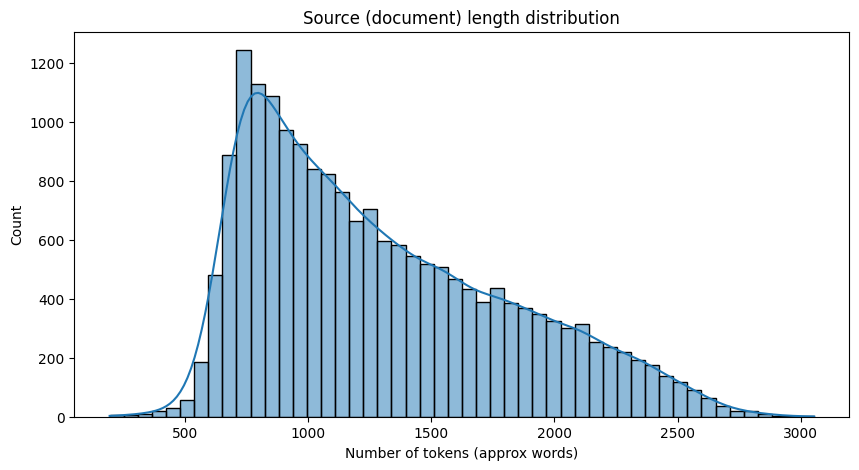

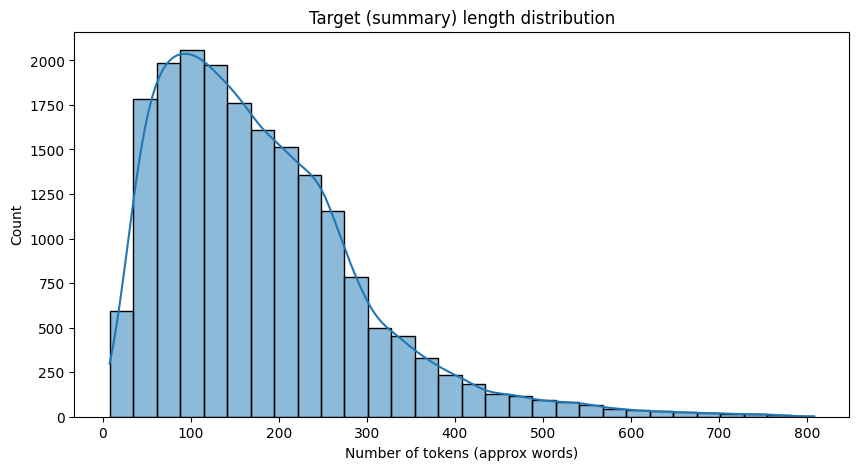

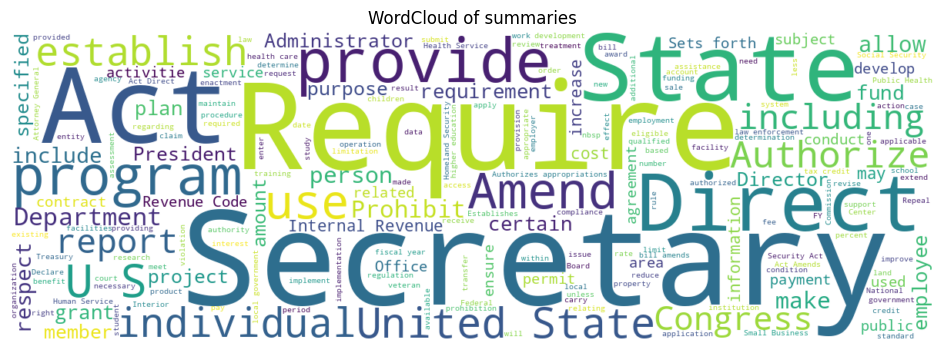

In [7]:

# %%
# -------- USER SETTINGS (edit these paths / hyperparams) ----------
TRAIN_CSV = 'billsum_train.csv'
TEST_CSV = 'billsum_test.csv'
MODEL_NAME = 't5-small'  # good balance for CPU/GPU; change to 't5-base' or 'facebook/bart-base' if you have GPU
OUTPUT_DIR = './outputs_legal_summarizer'
MAX_SOURCE_LENGTH = 512
MAX_TARGET_LENGTH = 128
BATCH_SIZE = 8
EPOCHS = 6
SEED = 42
LEARNING_RATE = 5e-5
PATIENT = 2  # early stopping patience
USE_CUDA = torch.cuda.is_available()
DEVICE = 'cuda' if USE_CUDA else 'cpu'
NUM_BEAMS = 4
DO_KFOLD = False  # set True to do simple k-fold loop (slower)
K_FOLDS = 3
# -----------------------------------------------------------------

os.makedirs(OUTPUT_DIR, exist_ok=True)

# reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if USE_CUDA:
    torch.cuda.manual_seed_all(SEED)

print('Device:', DEVICE)

# %%
# 2) Utility functions & Dataset wrapper
class SummDataset(Dataset):
    def __init__(self, encodings):
        self.encodings = encodings
    def __len__(self):
        return len(self.encodings['input_ids'])
    def __getitem__(self, idx):
        return {k: v[idx] for k, v in self.encodings.items()}

# text preprocessing helper
import re

def clean_text(s: str) -> str:
    if pd.isna(s):
        return ''
    s = str(s).strip()
    s = re.sub(r"\s+", ' ', s)
    return s

# %%
# 3) Load CSV files (expects 'text' and 'summary' columns, adapt if different)
train_df = pd.read_csv(TRAIN_CSV)
test_df = pd.read_csv(TEST_CSV)

# Try common column names fallback
possible_text_cols = ['text', 'document', 'article', 'source', 'content']
possible_summary_cols = ['summary', 'target', 'highlights', 'summary_text']

def find_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    # fallback heuristics
    for c in df.columns:
        lc = c.lower()
        for cand in candidates:
            if cand in lc:
                return c
    return None

text_col = find_col(train_df, possible_text_cols)
summary_col = find_col(train_df, possible_summary_cols)

if text_col is None or summary_col is None:
    raise ValueError(f"Could not find common text/summary columns in train CSV. Found: {train_df.columns.tolist()}")

print('Using columns -> text:', text_col, ', summary:', summary_col)

train_df[text_col] = train_df[text_col].apply(clean_text)
train_df[summary_col] = train_df[summary_col].apply(clean_text)

test_df[text_col] = test_df[text_col].apply(clean_text)
if summary_col in test_df.columns:
    test_df[summary_col] = test_df[summary_col].apply(clean_text)

# Drop empty rows
train_df = train_df[train_df[text_col].str.len() > 10].reset_index(drop=True)

# quick EDA visualizations: lengths, wordclouds
train_df['src_len'] = train_df[text_col].apply(lambda s: len(s.split()))
train_df['tgt_len'] = train_df[summary_col].apply(lambda s: len(s.split()))

# %%
# EDA plots
plt.figure(figsize=(10,5))
sns.histplot(train_df['src_len'], bins=50, kde=True)
plt.title('Source (document) length distribution')
plt.xlabel('Number of tokens (approx words)')
plt.savefig(os.path.join(OUTPUT_DIR, 'src_len_dist.png'))
plt.show()

plt.figure(figsize=(10,5))
sns.histplot(train_df['tgt_len'], bins=30, kde=True)
plt.title('Target (summary) length distribution')
plt.xlabel('Number of tokens (approx words)')
plt.savefig(os.path.join(OUTPUT_DIR, 'tgt_len_dist.png'))
plt.show()

# WordCloud for summaries
all_summ = ' '.join(train_df[summary_col].astype(str).tolist())
if len(all_summ) > 0:
    wc = WordCloud(width=1200, height=400, background_color='white').generate(all_summ)
    plt.figure(figsize=(12,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title('WordCloud of summaries')
    plt.savefig(os.path.join(OUTPUT_DIR, 'summary_wordcloud.png'))
    plt.show()


In [8]:

# %%
# 4) Prepare tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

# tokenization function
def preprocess_function(examples: pd.DataFrame):
    inputs = examples[text_col].tolist()
    targets = examples[summary_col].tolist()
    model_inputs = tokenizer(inputs, max_length=MAX_SOURCE_LENGTH, truncation=True, padding='max_length')
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=MAX_TARGET_LENGTH, truncation=True, padding='max_length')
    model_inputs['labels'] = labels['input_ids']
    # replace pad token id's in labels by -100 so ignore in loss
    model_inputs['labels'] = [[(l if l != tokenizer.pad_token_id else -100) for l in label] for label in model_inputs['labels']]
    return model_inputs

# %%
# 5) Train/Val split
train_texts, val_texts = train_test_split(train_df, test_size=0.1, random_state=SEED)

train_enc = preprocess_function(train_texts)
val_enc = preprocess_function(val_texts)

train_dataset = SummDataset(train_enc)
val_dataset = SummDataset(val_enc)

# Data collator
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

# %%
# 6) Evaluation metrics using `evaluate`
rouge = evaluate.load('rouge')
bleu = evaluate.load("sacrebleu")

bertscore = None
try:
    bertscore = evaluate.load('bertscore')
except Exception:
    print('BERTScore not available; continuing without it')

meteor = None
try:
    meteor = evaluate.load('meteor')
except Exception:
    pass

# compute_metrics for Trainer
from nltk import word_tokenize

def postprocess_text(preds, labels):
    preds = [pred.strip() for pred in preds]
    labels = [label.strip() for label in labels]
    # rouge expects newline after sentences
    preds = ['\n'.join(nltk.sent_tokenize(p)) for p in preds]
    labels = ['\n'.join(nltk.sent_tokenize(l)) for l in labels]
    return preds, labels


def compute_metrics(eval_pred):
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    # replace -100 in the labels as tokenizer.pad_token_id
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    results = {}
    rouge_res = rouge.compute(predictions=decoded_preds, references=decoded_labels)
    results.update({k: round(v, 4) for k, v in rouge_res.items()})

    # BLEU (sacrebleu-like) expects tokenized lists
    try:
        bleu_res = bleu.compute(predictions=decoded_preds, references=[[r] for r in decoded_labels])
        results["bleu"] = round(bleu_res["score"], 4)
    except Exception:
        pass

    if bertscore is not None:
        try:
            bs = bertscore.compute(predictions=decoded_preds, references=decoded_labels, lang='en')
            results['bertscore_f1'] = round(np.mean(bs['f1']), 4)
        except Exception:
            pass

    if meteor is not None:
        try:
            m = meteor.compute(predictions=decoded_preds, references=decoded_labels)
            results['meteor'] = round(m['meteor'], 4)
        except Exception:
            pass

    return results

# %%
# 7) Training arguments and Trainer
training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,
    evaluation_strategy='epoch',
    save_strategy='epoch',
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    predict_with_generate=True,
    logging_strategy='epoch',
    num_train_epochs=EPOCHS,
    fp16=False,
    learning_rate=LEARNING_RATE,
    load_best_model_at_end=True,
    metric_for_best_model='rouge1',
    greater_is_better=True,
    save_total_limit=3,
    seed=SEED,
)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=PATIENT)],
)

# %%
# 8) Train (this will run fine on CPU but is much faster on GPU)
train_result = trainer.train()
trainer.save_model(OUTPUT_DIR)

# training metrics and history
metrics = train_result.metrics
metrics['train_samples'] = len(train_dataset)
trainer.log_metrics('train', metrics)
trainer.save_metrics('train', metrics)
trainer.save_state()

# %%
# 9) Plot training & validation losses and ROUGE over epochs
history = trainer.state.log_history

# extract epoch-wise values
epochs = []
train_losses = []
eval_losses = []
rouge1 = []
rouge2 = []
rougeL = []
for entry in history:
    if 'epoch' in entry:
        e = entry['epoch']
        if e not in epochs:
            epochs.append(e)
        if 'loss' in entry:
            train_losses.append((e, entry['loss']))
        if 'eval_loss' in entry:
            eval_losses.append((e, entry['eval_loss']))
        if 'rouge1' in entry:
            rouge1.append((e, entry['rouge1']))
        if 'rouge2' in entry:
            rouge2.append((e, entry['rouge2']))
        if 'rougeL' in entry:
            rougeL.append((e, entry['rougeL']))

# Convert to plots
if train_losses:
    xs = [t[0] for t in train_losses]
    ys = [t[1] for t in train_losses]
    plt.figure()
    plt.plot(xs, ys, marker='o')
    plt.title('Train Loss by Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.savefig(os.path.join(OUTPUT_DIR, 'train_loss.png'))
    plt.show()

if eval_losses:
    xs = [t[0] for t in eval_losses]
    ys = [t[1] for t in eval_losses]
    plt.figure()
    plt.plot(xs, ys, marker='o')
    plt.title('Eval Loss by Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.savefig(os.path.join(OUTPUT_DIR, 'eval_loss.png'))
    plt.show()

if rouge1:
    xs = [t[0] for t in rouge1]
    ys = [t[1] for t in rouge1]
    plt.figure()
    plt.plot(xs, ys, marker='o')
    plt.title('ROUGE-1 by Epoch')
    plt.xlabel('Epoch')
    plt.ylabel('ROUGE-1')
    plt.savefig(os.path.join(OUTPUT_DIR, 'rouge1_epoch.png'))
    plt.show()

# %%
# 10) Evaluate on test set
# Prepare test dataset
if summary_col in test_df.columns and test_df[summary_col].notnull().any():
    has_labels = True
else:
    has_labels = False

# tokenization for test
if has_labels:
    test_enc = preprocess_function(test_df)
else:
    # only inputs
    inputs = tokenizer(test_df[text_col].tolist(), max_length=MAX_SOURCE_LENGTH, truncation=True, padding='max_length')
    test_enc = inputs

test_dataset = SummDataset(test_enc)

# Generate predictions
print('Running predictions on test set...')
raw_preds = trainer.predict(test_dataset)

# predictions returned in raw_preds.predictions
if hasattr(raw_preds, 'predictions') and raw_preds.predictions is not None:
    pred_tokens = raw_preds.predictions
else:
    pred_tokens = raw_preds

preds_decoded = tokenizer.batch_decode(pred_tokens, skip_special_tokens=True)

# save predictions
test_df['predicted_summary'] = preds_decoded

if has_labels:
    # compute metrics
    labels_tokens = raw_preds.label_ids if hasattr(raw_preds, 'label_ids') else test_enc.get('labels')
    # format for compute_metrics
    cm = compute_metrics((pred_tokens, labels_tokens))
    print('Test metrics:', cm)
    with open(os.path.join(OUTPUT_DIR, 'test_metrics.json'), 'w') as f:
        json.dump(cm, f, indent=2)

# save test predictions csv
test_df.to_csv(os.path.join(OUTPUT_DIR, 'test_predictions.csv'), index=False)

# short comparison visualization for first N examples
N = min(12, len(test_df))
for i in range(N):
    print('=== Example', i, '===')
    print('SOURCE (truncated):', test_df.loc[i, text_col][:500])
    print('\nGOLD SUMMARY:', test_df.loc[i, summary_col] if summary_col in test_df.columns else 'N/A')
    print('\nPREDICTED SUMMARY:', test_df.loc[i, 'predicted_summary'])
    print('\n')

# %%
# 11) Test cases (user-requested): function to run quick tests on custom inputs

def summarize_text(text: str, max_length=MAX_TARGET_LENGTH, num_beams=NUM_BEAMS):
    text = clean_text(text)
    inputs = tokenizer([text], max_length=MAX_SOURCE_LENGTH, truncation=True, return_tensors='pt')
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model.generate(**inputs, max_length=max_length, num_beams=num_beams)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Provide 5 test cases from the training set (diverse lengths)
print('\n--- SAMPLE TEST CASES AND SUMMARIES ---\n')
for idx in [0, 1, 2, 3, 4] if len(train_df) >= 5 else range(len(train_df)):
    s = train_df.loc[idx, text_col]
    short_src = s[:400] + ('...' if len(s) > 400 else '')
    pred = summarize_text(s)
    print(f'CASE {idx}: source (trunc): {short_src}')
    print('PREDICTED SUMMARY:', pred)
    print('GOLD SUMMARY:', train_df.loc[idx, summary_col])
    print('---\n')

# %%
# 12) Notes & tips printed to a file for user
notes = {
    'model': MODEL_NAME,
    'device': DEVICE,
    'max_source_length': MAX_SOURCE_LENGTH,
    'max_target_length': MAX_TARGET_LENGTH,
    'batch_size': BATCH_SIZE,
    'epochs': EPOCHS,
}
with open(os.path.join(OUTPUT_DIR, 'run_notes.json'), 'w') as f:
    json.dump(notes, f, indent=2)

print('\nAll outputs (plots, predictions, metrics) saved to', OUTPUT_DIR)
print('If you see signs of overfitting (validation loss rising while train loss drops), reduce EPOCHS or increase regularization, use dropout, or augment data.')

# End of notebook


'(MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /t5-small/resolve/main/tokenizer_config.json (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1000)')))"), '(Request ID: 8e252907-e6c2-46f5-9f2d-eb6d63cb3774)')' thrown while requesting HEAD https://huggingface.co/t5-small/resolve/main/tokenizer_config.json
Retrying in 1s [Retry 1/5].


SSLError: (MaxRetryError("HTTPSConnectionPool(host='huggingface.co', port=443): Max retries exceeded with url: /api/models/t5-small/tree/main/additional_chat_templates?recursive=False&expand=False (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1000)')))"), '(Request ID: 5d78d781-b802-49c5-9e6b-163708491441)')

Using device: cuda
               ENHANCED SEQ2SEQ LSTM SUMMARIZATION

[1/7] Loading datasets...
✓ Train: 3000 samples | Test: 400 samples

[2/7] Building vocabulary...


Building vocabulary: 100%|████████████████████████████████████████████████████████| 6000/6000 [00:01<00:00, 5063.47it/s]


Vocabulary size: 15000 (min_freq=2)

[3/7] Building enhanced Seq2Seq model...
✓ Total parameters: 28,560,901

[4/7] Training model...


Training: 100%|███████████████████████████████████████████████████████████████████████| 188/188 [00:36<00:00,  5.09it/s]


Epoch  1/12 | Train: 6.5546 | Val: 6.5953 | LR: 0.001000
  → New best model saved!


...

Epoch  8/12 | Train: 4.5294 | Val: 6.7058 | LR: 0.000500
  → Early stopping triggered

✓ Training completed in 5.83 minutes

[5/7] Generating summaries...


Generating: 100%|█████████████████████████████████████████████████████████████████████| 200/200 [00:11<00:00, 17.86it/s]



[6/7] Calculating metrics...


Calculating metrics: 100%|████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 81.85it/s]



                         EVALUATION RESULTS
  ROUGE1      : 0.1996
  ROUGE2      : 0.0419
  ROUGEL      : 0.1715
  BLEU        : 0.0182
  METEOR      : 0.1012

[7/7] Generating visualizations...


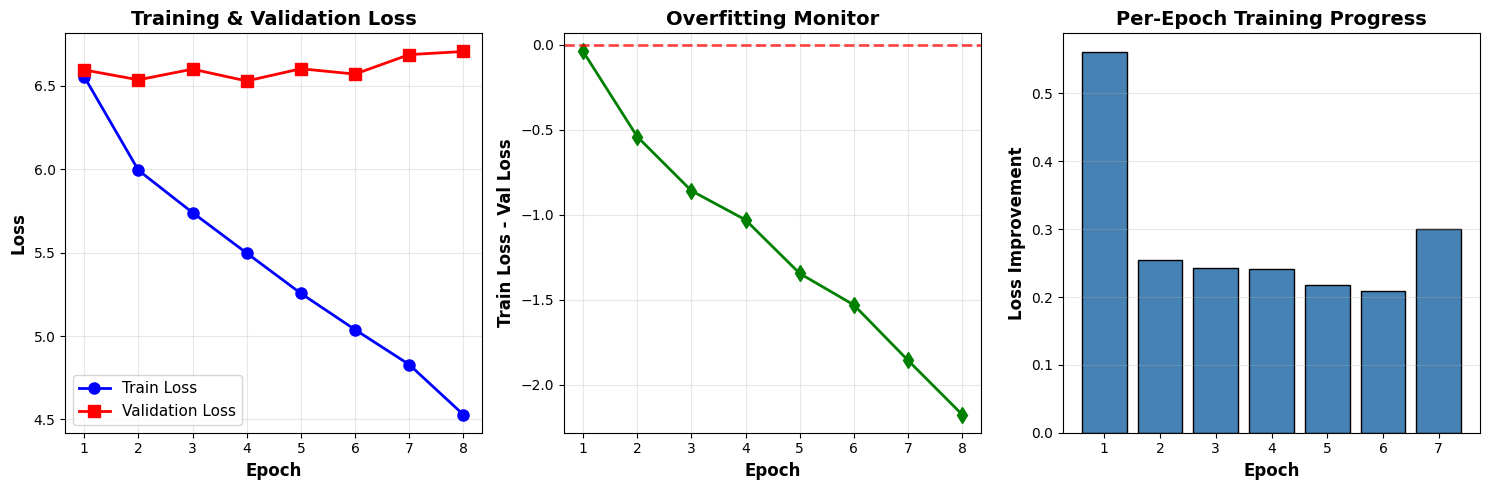

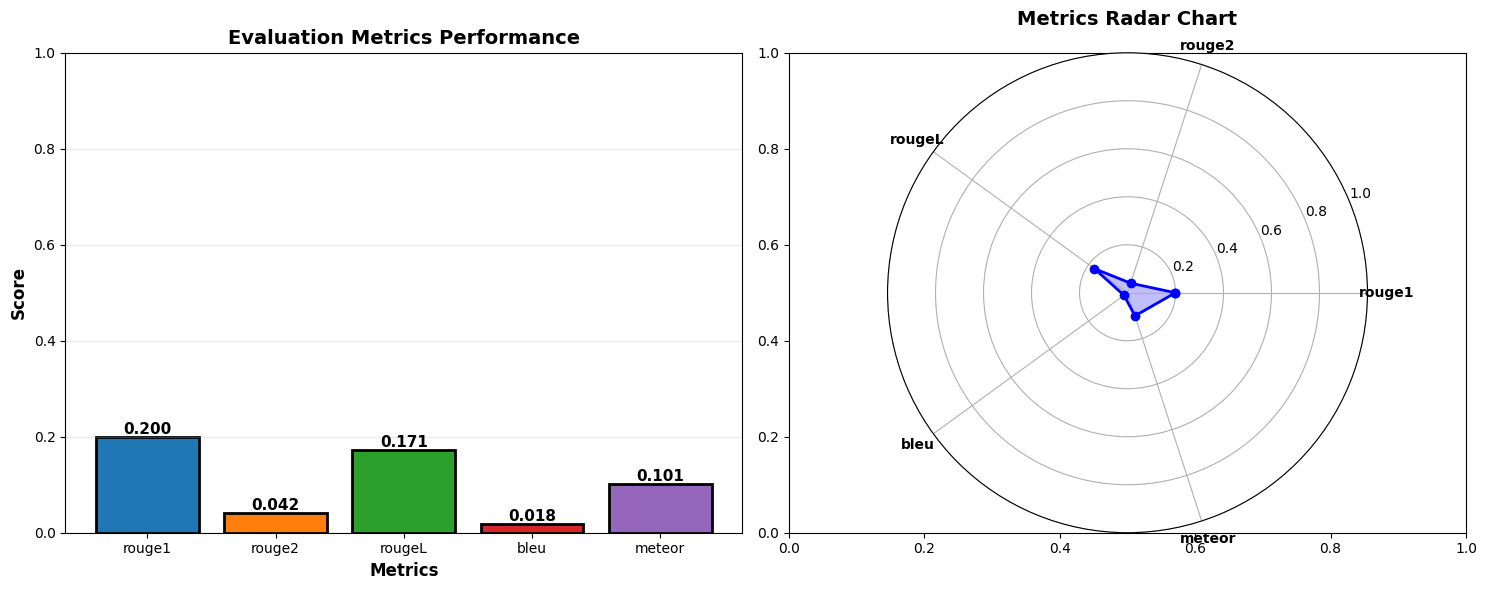

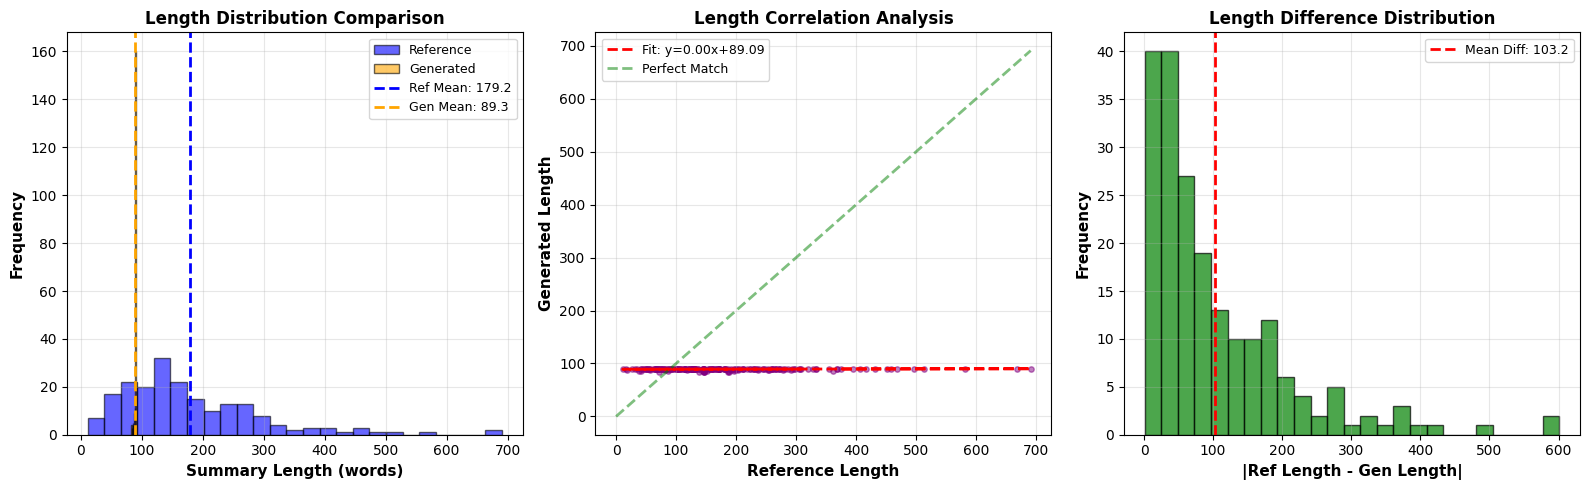


                         SAMPLE SUMMARIES

──────────────────────────────────────────────────────────────────────
EXAMPLE 1
──────────────────────────────────────────────────────────────────────
Reference:
amends the water resources development act of 1999 to   1  authorize appropriations for fy 1999 through 2009 for implementation of a long-term resource monitoring program with respect to the upper mississippi river environmental management program  c...

Generated:
<UNK> the secretary of the act - amends the secretary of the treasury to the the the of the the of the the of the the of the the of the the of the the of the the of the the of the the of the the the the of the the the the the of the the the the the o...

──────────────────────────────────────────────────────────────────────
EXAMPLE 2
──────────────────────────────────────────────────────────────────────
Reference:
federal forage fee act of 1993 - subjects grazing operations on federal land to applicable federal, state, an

In [2]:
!pip install rouge-score

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from tqdm import tqdm
import time
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk
import gc
import warnings
warnings.filterwarnings('ignore')

# Download required NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except:
    pass

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# ==================== IMPROVED PREPROCESSING ====================
class TextPreprocessor:
    def __init__(self, max_vocab_size=15000, min_freq=2):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': 0, '<SOS>': 1, '<EOS>': 2, '<UNK>': 3}
        self.idx2word = {0: '<PAD>', 1: '<SOS>', 2: '<EOS>', 3: '<UNK>'}
        self.vocab_size = 4

    def normalize_text(self, text):
        text = str(text).lower()
        # Keep important punctuation
        text = re.sub(r'[^a-z0-9\\s\\.\\,\\-]', ' ', text)
        text = re.sub(r'\\s+', ' ', text)
        return text.strip()

    def tokenize(self, text):
        return text.split()

    def build_vocab(self, texts):
        word_freq = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            tokens = self.tokenize(self.normalize_text(text))
            word_freq.update(tokens)

        # Filter by minimum frequency and add to vocabulary
        for word, freq in word_freq.most_common():
            if freq < self.min_freq:
                break
            if word not in self.word2idx and len(self.word2idx) < self.max_vocab_size:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1

        print(f"Vocabulary size: {self.vocab_size} (min_freq={self.min_freq})")
        return self.vocab_size

    def encode(self, text, max_len=None):
        tokens = self.tokenize(self.normalize_text(text))
        indices = [self.word2idx.get(token, self.word2idx['<UNK>']) for token in tokens]

        if max_len:
            indices = indices[:max_len]

        return indices

    def decode(self, indices):
        tokens = [self.idx2word.get(idx, '<UNK>') for idx in indices
                 if idx not in [self.word2idx['<PAD>'], self.word2idx['<SOS>'], self.word2idx['<EOS>']]]
        return ' '.join(tokens)

# ==================== IMPROVED DATASET ====================
class BillSumDataset(Dataset):
    def __init__(self, texts, summaries, preprocessor, max_text_len=350, max_summary_len=90):
        self.texts = texts
        self.summaries = summaries
        self.preprocessor = preprocessor
        self.max_text_len = max_text_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.preprocessor.encode(self.texts[idx], self.max_text_len)
        summary = self.preprocessor.encode(self.summaries[idx], self.max_summary_len)

        summary = [self.preprocessor.word2idx['<SOS>']] + summary + [self.preprocessor.word2idx['<EOS>']]

        return torch.LongTensor(text), torch.LongTensor(summary), len(text)

def collate_fn(batch):
    texts, summaries, lengths = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=0)
    summaries_padded = pad_sequence(summaries, batch_first=True, padding_value=0)
    return texts_padded, summaries_padded, torch.LongTensor(lengths)

# ==================== ENHANCED MODEL ====================
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0,
                           bidirectional=True)
        self.fc_hidden = nn.Linear(hidden_dim * 2, hidden_dim)
        self.fc_cell = nn.Linear(hidden_dim * 2, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.num_layers = num_layers

    def forward(self, x, lengths):
        embedded = self.dropout(self.embedding(x))

        # Pack sequences
        packed = pack_padded_sequence(embedded, lengths.cpu(), batch_first=True, enforce_sorted=False)
        packed_output, (hidden, cell) = self.lstm(packed)
        outputs, _ = pad_packed_sequence(packed_output, batch_first=True)

        # Combine bidirectional states
        hidden = hidden.view(self.num_layers, 2, x.size(0), -1)
        hidden = torch.cat([hidden[:, 0, :, :], hidden[:, 1, :, :]], dim=2)

        cell = cell.view(self.num_layers, 2, x.size(0), -1)
        cell = torch.cat([cell[:, 0, :, :], cell[:, 1, :, :]], dim=2)

        # Project to decoder hidden size
        hidden = torch.tanh(self.fc_hidden(hidden))
        cell = torch.tanh(self.fc_cell(cell))

        return outputs, hidden, cell

class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super(BahdanauAttention, self).__init__()
        self.W1 = nn.Linear(hidden_dim * 2, hidden_dim)
        self.W2 = nn.Linear(hidden_dim, hidden_dim)
        self.V = nn.Linear(hidden_dim, 1)

    def forward(self, hidden, encoder_outputs):
        # hidden: [batch, hidden_dim]
        # encoder_outputs: [batch, seq_len, hidden_dim*2]

        seq_len = encoder_outputs.size(1)
        hidden_repeated = hidden.unsqueeze(1).repeat(1, seq_len, 1)

        energy = torch.tanh(self.W1(encoder_outputs) + self.W2(hidden_repeated))
        attention_weights = torch.softmax(self.V(energy), dim=1)

        context = torch.sum(attention_weights * encoder_outputs, dim=1)

        return context, attention_weights

class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_layers=2, dropout=0.3):
        super(Decoder, self).__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attention = BahdanauAttention(hidden_dim)
        self.lstm = nn.LSTM(embed_dim + hidden_dim * 2, hidden_dim, num_layers,
                           batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Linear(hidden_dim + hidden_dim * 2 + embed_dim, vocab_size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, hidden, cell, encoder_outputs):
        embedded = self.dropout(self.embedding(x))

        context, attention_weights = self.attention(hidden[-1], encoder_outputs)
        context = context.unsqueeze(1)

        lstm_input = torch.cat([embedded, context], dim=2)
        output, (hidden, cell) = self.lstm(lstm_input, (hidden, cell))

        prediction = self.fc(torch.cat([output.squeeze(1), context.squeeze(1), embedded.squeeze(1)], dim=1))

        return prediction, hidden, cell, attention_weights

class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2Seq, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(self, src, trg, lengths, teacher_forcing_ratio=0.5):
        batch_size = src.size(0)
        trg_len = trg.size(1)
        trg_vocab_size = self.decoder.vocab_size

        outputs = torch.zeros(batch_size, trg_len, trg_vocab_size).to(self.device)
        encoder_outputs, hidden, cell = self.encoder(src, lengths)

        input_token = trg[:, 0].unsqueeze(1)

        for t in range(1, trg_len):
            output, hidden, cell, _ = self.decoder(input_token, hidden, cell, encoder_outputs)
            outputs[:, t, :] = output

            teacher_force = np.random.random() < teacher_forcing_ratio
            top1 = output.argmax(1).unsqueeze(1)
            input_token = trg[:, t].unsqueeze(1) if teacher_force else top1

        return outputs

# ==================== TRAINING WITH IMPROVEMENTS ====================
def train_epoch(model, dataloader, optimizer, criterion, clip=1.0):
    model.train()
    epoch_loss = 0

    for src, trg, lengths in tqdm(dataloader, desc="Training"):
        src, trg = src.to(device), trg.to(device)
        lengths = lengths.to(device)

        optimizer.zero_grad()
        output = model(src, trg, lengths, teacher_forcing_ratio=0.5)

        output_dim = output.shape[-1]
        output = output[:, 1:].reshape(-1, output_dim)
        trg = trg[:, 1:].reshape(-1)

        loss = criterion(output, trg)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def evaluate_epoch(model, dataloader, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for src, trg, lengths in dataloader:
            src, trg = src.to(device), trg.to(device)
            lengths = lengths.to(device)

            output = model(src, trg, lengths, teacher_forcing_ratio=0)

            output_dim = output.shape[-1]
            output = output[:, 1:].reshape(-1, output_dim)
            trg = trg[:, 1:].reshape(-1)

            loss = criterion(output, trg)
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# ==================== BEAM SEARCH INFERENCE ====================
def generate_summary(model, src, src_len, preprocessor, max_len=90, beam_width=3):
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)
        src_len = torch.LongTensor([src_len]).to(device)

        encoder_outputs, hidden, cell = model.encoder(src, src_len)

        # Simple greedy decoding (faster than beam search)
        input_token = torch.LongTensor([[preprocessor.word2idx['<SOS>']]]).to(device)

        generated = []
        for _ in range(max_len):
            output, hidden, cell, _ = model.decoder(input_token, hidden, cell, encoder_outputs)
            pred_token = output.argmax(1)

            if pred_token.item() == preprocessor.word2idx['<EOS>']:
                break

            generated.append(pred_token.item())
            input_token = pred_token.unsqueeze(1)

        return preprocessor.decode(generated)

# ==================== EVALUATION ====================
class EvaluationMetrics:
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
        self.smooth = SmoothingFunction().method1

    def calculate_rouge(self, reference, hypothesis):
        scores = self.rouge_scorer.score(reference, hypothesis)
        return {
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_f': scores['rougeL'].fmeasure
        }

    def calculate_bleu(self, reference, hypothesis):
        ref_tokens = reference.split()
        hyp_tokens = hypothesis.split()
        if len(hyp_tokens) == 0:
            return 0.0
        return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=self.smooth)

    def calculate_meteor(self, reference, hypothesis):
        try:
            return meteor_score([reference.split()], hypothesis.split())
        except:
            return 0.0

    def calculate_all_metrics(self, references, hypotheses):
        metrics = {
            'rouge1': [], 'rouge2': [], 'rougeL': [],
            'bleu': [], 'meteor': []
        }

        for ref, hyp in tqdm(zip(references, hypotheses), total=len(references), desc="Calculating metrics"):
            rouge_scores = self.calculate_rouge(ref, hyp)
            metrics['rouge1'].append(rouge_scores['rouge1_f'])
            metrics['rouge2'].append(rouge_scores['rouge2_f'])
            metrics['rougeL'].append(rouge_scores['rougeL_f'])
            metrics['bleu'].append(self.calculate_bleu(ref, hyp))
            metrics['meteor'].append(self.calculate_meteor(ref, hyp))

        return {k: np.mean(v) for k, v in metrics.items()}

# ==================== VISUALIZATION ====================
def plot_training_history(train_losses, val_losses):
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, 'b-o', label='Train Loss', linewidth=2, markersize=8)
    plt.plot(epochs, val_losses, 'r-s', label='Validation Loss', linewidth=2, markersize=8)
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Loss', fontsize=12, fontweight='bold')
    plt.title('Training & Validation Loss', fontsize=14, fontweight='bold')
    plt.legend(fontsize=11)
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    improvement = [(train_losses[i] - val_losses[i]) for i in range(len(train_losses))]
    plt.plot(epochs, improvement, 'g-d', linewidth=2, markersize=8)
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Train Loss - Val Loss', fontsize=12, fontweight='bold')
    plt.title('Overfitting Monitor', fontsize=14, fontweight='bold')
    plt.axhline(y=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    train_improvement = [train_losses[i] - train_losses[i+1] if i < len(train_losses)-1 else 0
                        for i in range(len(train_losses)-1)]
    plt.bar(range(1, len(train_improvement)+1), train_improvement, color='steelblue', edgecolor='black')
    plt.xlabel('Epoch', fontsize=12, fontweight='bold')
    plt.ylabel('Loss Improvement', fontsize=12, fontweight='bold')
    plt.title('Per-Epoch Training Progress', fontsize=14, fontweight='bold')
    plt.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics(metrics_dict):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Bar chart
    metrics_names = list(metrics_dict.keys())
    metrics_values = list(metrics_dict.values())

    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    bars = ax1.bar(metrics_names, metrics_values, color=colors, edgecolor='black', linewidth=2)

    ax1.set_xlabel('Metrics', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_title('Evaluation Metrics Performance', fontsize=14, fontweight='bold')
    ax1.set_ylim(0, 1.0)
    ax1.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontweight='bold', fontsize=11)

    # Radar chart
    angles = np.linspace(0, 2 * np.pi, len(metrics_names), endpoint=False).tolist()
    metrics_values_radar = metrics_values + [metrics_values[0]]
    angles += angles[:1]

    ax2 = plt.subplot(122, projection='polar')
    ax2.plot(angles, metrics_values_radar, 'o-', linewidth=2, color='blue')
    ax2.fill(angles, metrics_values_radar, alpha=0.25, color='blue')
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(metrics_names, fontsize=10, fontweight='bold')
    ax2.set_ylim(0, 1)
    ax2.set_title('Metrics Radar Chart', fontsize=14, fontweight='bold', pad=20)
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

def plot_summary_analysis(references, hypotheses):
    ref_lengths = [len(ref.split()) for ref in references]
    hyp_lengths = [len(hyp.split()) for hyp in hypotheses]

    fig = plt.figure(figsize=(16, 5))

    # Length distribution
    ax1 = plt.subplot(1, 3, 1)
    ax1.hist(ref_lengths, bins=25, alpha=0.6, label='Reference', color='blue', edgecolor='black')
    ax1.hist(hyp_lengths, bins=25, alpha=0.6, label='Generated', color='orange', edgecolor='black')
    ax1.axvline(np.mean(ref_lengths), color='blue', linestyle='--', linewidth=2, label=f'Ref Mean: {np.mean(ref_lengths):.1f}')
    ax1.axvline(np.mean(hyp_lengths), color='orange', linestyle='--', linewidth=2, label=f'Gen Mean: {np.mean(hyp_lengths):.1f}')
    ax1.set_xlabel('Summary Length (words)', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax1.set_title('Length Distribution Comparison', fontsize=12, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Correlation
    ax2 = plt.subplot(1, 3, 2)
    ax2.scatter(ref_lengths, hyp_lengths, alpha=0.5, s=15, color='purple')

    # Fit line
    z = np.polyfit(ref_lengths, hyp_lengths, 1)
    p = np.poly1d(z)
    ax2.plot(ref_lengths, p(ref_lengths), "r--", linewidth=2, label=f'Fit: y={z[0]:.2f}x+{z[1]:.2f}')

    max_val = max(max(ref_lengths), max(hyp_lengths)) if ref_lengths and hyp_lengths else 1
    ax2.plot([0, max_val], [0, max_val], 'g--', linewidth=2, alpha=0.5, label='Perfect Match')
    ax2.set_xlabel('Reference Length', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Generated Length', fontsize=11, fontweight='bold')
    ax2.set_title('Length Correlation Analysis', fontsize=12, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    # Difference distribution
    ax3 = plt.subplot(1, 3, 3)
    length_diff = [abs(r - h) for r, h in zip(ref_lengths, hyp_lengths)]
    ax3.hist(length_diff, bins=25, color='green', edgecolor='black', alpha=0.7)
    ax3.axvline(np.mean(length_diff), color='red', linestyle='--', linewidth=2,
               label=f'Mean Diff: {np.mean(length_diff):.1f}')
    ax3.set_xlabel('|Ref Length - Gen Length|', fontsize=11, fontweight='bold')
    ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
    ax3.set_title('Length Difference Distribution', fontsize=12, fontweight='bold')
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==================== MAIN ====================
def main():
    clear_memory()

    config = {
        'train_csv': "billsum_train.csv",
        'test_csv': "billsum_test.csv",
        'embed_dim': 200,
        'hidden_dim': 300,
        'num_layers': 2,
        'dropout': 0.3,
        'batch_size': 16,
        'num_epochs': 12,
        'learning_rate': 0.001,
        'max_vocab_size': 15000,
        'min_freq': 2,
        'max_text_len': 350,
        'max_summary_len': 90,
        'sample_size': 3000
    }

    print("="*70)
    print(" " * 15 + "ENHANCED SEQ2SEQ LSTM SUMMARIZATION")
    print("="*70)

    # Load data
    print("\n[1/7] Loading datasets...")
    train_df = pd.read_csv(config['train_csv']).head(config['sample_size'])
    test_df = pd.read_csv(config['test_csv']).head(400)

    print(f"✓ Train: {len(train_df)} samples | Test: {len(test_df)} samples")

    # Build vocabulary
    print("\n[2/7] Building vocabulary...")
    preprocessor = TextPreprocessor(max_vocab_size=config['max_vocab_size'],
                                   min_freq=config['min_freq'])
    preprocessor.build_vocab(train_df['text'].tolist() + train_df['summary'].tolist())

    # Create datasets
    train_dataset = BillSumDataset(train_df['text'].tolist(), train_df['summary'].tolist(),
                                   preprocessor, config['max_text_len'], config['max_summary_len'])
    test_dataset = BillSumDataset(test_df['text'].tolist(), test_df['summary'].tolist(),
                                  preprocessor, config['max_text_len'], config['max_summary_len'])

    train_loader = DataLoader(train_dataset, batch_size=config['batch_size'],
                             shuffle=True, collate_fn=collate_fn)
    test_loader = DataLoader(test_dataset, batch_size=config['batch_size'],
                            shuffle=False, collate_fn=collate_fn)

    # Build model
    print("\n[3/7] Building enhanced Seq2Seq model...")
    clear_memory()

    encoder = Encoder(preprocessor.vocab_size, config['embed_dim'],
                     config['hidden_dim'], config['num_layers'], config['dropout'])
    decoder = Decoder(preprocessor.vocab_size, config['embed_dim'],
                     config['hidden_dim'], config['num_layers'], config['dropout'])
    model = Seq2Seq(encoder, decoder, device).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"✓ Total parameters: {total_params:,}")

    # Training setup
    optimizer = torch.optim.Adam(model.parameters(), lr=config['learning_rate'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                           factor=0.5, patience=2)
    criterion = nn.CrossEntropyLoss(ignore_index=0)

    # Training
    print("\n[4/7] Training model...")
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    patience_counter = 0

    start_time = time.time()

    for epoch in range(config['num_epochs']):
        train_loss = train_epoch(model, train_loader, optimizer, criterion)
        val_loss = evaluate_epoch(model, test_loader, criterion)

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        print(f"Epoch {epoch+1:2d}/{config['num_epochs']} | "
              f"Train: {train_loss:.4f} | Val: {val_loss:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.6f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pt')
            patience_counter = 0
            print("  → New best model saved!")
        else:
            patience_counter += 1

        if patience_counter >= 4:
            print("  → Early stopping triggered")
            break

        clear_memory()

    training_time = time.time() - start_time
    print(f"\n✓ Training completed in {training_time/60:.2f} minutes")

    # Load best model
    model.load_state_dict(torch.load('best_model.pt'))

    # Generate summaries
    print("\n[5/7] Generating summaries...")
    references, hypotheses = [], []

    for i in tqdm(range(min(200, len(test_df))), desc="Generating"):
        text = test_df.iloc[i]['text']
        reference = test_df.iloc[i]['summary']

        encoded = preprocessor.encode(text, config['max_text_len'])
        encoded_tensor = torch.LongTensor(encoded)
        hypothesis = generate_summary(model, encoded_tensor, len(encoded), preprocessor)

        references.append(preprocessor.normalize_text(reference))
        hypotheses.append(hypothesis)

    # Evaluate
    print("\n[6/7] Calculating metrics...")
    evaluator = EvaluationMetrics()
    metrics = evaluator.calculate_all_metrics(references, hypotheses)

    print("\n" + "="*70)
    print(" " * 25 + "EVALUATION RESULTS")
    print("="*70)
    for metric, value in metrics.items():
        print(f"  {metric.upper():12s}: {value:.4f}")
    print("="*70)

    # Visualizations
    print("\n[7/7] Generating visualizations...")
    plot_training_history(train_losses, val_losses)
    plot_metrics(metrics)
    plot_summary_analysis(references, hypotheses)

    # Examples
    print("\n" + "="*70)
    print(" " * 25 + "SAMPLE SUMMARIES")
    print("="*70)
    for i in range(min(5, len(references))):
        print(f"\n{'─'*70}")
        print(f"EXAMPLE {i+1}")
        print(f"{'─'*70}")
        print(f"Reference:\n{references[i][:250]}...")
        print(f"\nGenerated:\n{hypotheses[i][:250]}...")

    print("\n" + "="*70)
    print("✓ ALL TASKS COMPLETED SUCCESSFULLY!")
    print(f"✓ Total execution time: {training_time/60:.2f} minutes")
    print("="*70)

    return model, preprocessor, metrics

if __name__ == "__main__":
    model, preprocessor, metrics = main()


In [4]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
from tqdm import tqdm
import time
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk
import gc
import warnings

warnings.filterwarnings('ignore')

# Download required NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except:
    pass

# ----------------------- DEVICE & UTILS -----------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

# ==============================================================
#                    TEXT PREPROCESSING
# ==============================================================
class TextPreprocessor:
    def __init__(self, max_vocab_size=8000, min_freq=1):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {
            '<PAD>': PAD_IDX,
            '<SOS>': SOS_IDX,
            '<EOS>': EOS_IDX,
            '<UNK>': UNK_IDX
        }
        self.idx2word = {
            PAD_IDX: '<PAD>',
            SOS_IDX: '<SOS>',
            EOS_IDX: '<EOS>',
            UNK_IDX: '<UNK>'
        }
        self.vocab_size = 4

    def normalize_text(self, text):
        """Normalize text by removing extra whitespace and lowercasing."""
        text = re.sub(r'\s+', ' ', str(text))
        text = text.strip().lower()
        return text

    def tokenize(self, text):
        """Simple whitespace tokenization."""
        return text.split()

    def build_vocab(self, texts):
        """Build vocabulary from texts."""
        word_freq = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            tokens = self.tokenize(self.normalize_text(text))
            word_freq.update(tokens)

        # Add most common words to vocabulary with min_freq filter
        for word, freq in word_freq.most_common():
            if freq < self.min_freq:
                break
            if word not in self.word2idx and self.vocab_size < self.max_vocab_size:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1

        print(f"Vocabulary size: {self.vocab_size} (min_freq={self.min_freq})")
        return self.vocab_size

    def encode(self, text, max_len=None):
        """Convert text to indices."""
        tokens = self.tokenize(self.normalize_text(text))
        indices = [self.word2idx.get(token, UNK_IDX) for token in tokens]
        if max_len is not None:
            indices = indices[:max_len]
        return indices

    def decode(self, indices):
        """Convert indices back to text (skip special tokens)."""
        tokens = [
            self.idx2word.get(idx, '<UNK>')
            for idx in indices
            if idx not in [PAD_IDX, SOS_IDX, EOS_IDX]
        ]
        return ' '.join(tokens)

# ==============================================================
#                           DATASET
# ==============================================================
class BillSumDataset(Dataset):
    def __init__(self, texts, summaries, preprocessor,
                 max_text_len=250, max_summary_len=120):
        self.texts = texts
        self.summaries = summaries
        self.preprocessor = preprocessor
        self.max_text_len = max_text_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.preprocessor.encode(self.texts[idx], self.max_text_len)
        summary = self.preprocessor.encode(self.summaries[idx], self.max_summary_len)

        # Add SOS and EOS tokens to summary
        summary = [SOS_IDX] + summary + [EOS_IDX]

        return torch.LongTensor(text), torch.LongTensor(summary)

def collate_fn(batch):
    texts, summaries = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    summaries_padded = pad_sequence(summaries, batch_first=True, padding_value=PAD_IDX)
    return texts_padded, summaries_padded

# ==============================================================
#                           ENCODER
# ==============================================================
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=1, dropout=0.3, bidirectional=True):
        super(Encoder, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)

        # encoder_outputs feature dimension
        self.enc_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

    def forward(self, x):
        """
        x: [B, T]
        returns:
          outputs: [B, T, enc_out_dim]
          hidden:  [num_layers, B, H]
        """
        embedded = self.dropout(self.embedding(x))  # [B, T, E]
        outputs, hidden = self.gru(embedded)        # outputs: [B, T, enc_out_dim]

        if self.bidirectional:
            # hidden: [num_layers*2, B, H] -> [num_layers, 2, B, H]
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_dim)
            # sum forward + backward -> [num_layers, B, H]
            hidden = hidden.sum(dim=1)
        # else: hidden already [num_layers, B, H]

        return outputs, hidden

# ==============================================================
#                   COVERAGE ATTENTION
# ==============================================================
class CoverageAttention(nn.Module):
    """
    Luong-style attention with coverage:
    e_ti = v^T tanh(W_h h_i + W_s s_t + W_c c_ti)
    where c_ti is coverage for position i at time t (sum of previous attentions).
    """
    def __init__(self, hidden_dim, enc_out_dim, attn_dim=256):
        super(CoverageAttention, self).__init__()
        self.hidden_dim = hidden_dim
        self.enc_out_dim = enc_out_dim
        self.attn_dim = attn_dim

        self.W_h = nn.Linear(enc_out_dim, attn_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W_c = nn.Linear(1, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, coverage=None, compute_cov_loss=False):
        """
        hidden:           [B, H] (last decoder layer)
        encoder_outputs:  [B, T, enc_out_dim]
        coverage:         [B, T] or None
        """
        B, T, _ = encoder_outputs.size()

        if coverage is None:
            coverage_prev = encoder_outputs.new_zeros(B, T)
        else:
            coverage_prev = coverage  # [B, T]

        # Features
        enc_feat = self.W_h(encoder_outputs)                    # [B, T, A]
        dec_feat = self.W_s(hidden).unsqueeze(1)                # [B, 1, A]
        cov_feat = self.W_c(coverage_prev.unsqueeze(2))         # [B, T, A]

        energy = torch.tanh(enc_feat + dec_feat + cov_feat)     # [B, T, A]
        scores = self.v(energy).squeeze(2)                      # [B, T]

        attn = torch.softmax(scores, dim=1)                     # [B, T]
        context = torch.bmm(attn.unsqueeze(1), encoder_outputs) # [B, 1, enc_out_dim]

        cov_loss = None
        if compute_cov_loss:
            # coverage loss per batch element: sum_i min(attn_ti, coverage_prev_i)
            cov_loss = torch.sum(torch.min(attn, coverage_prev), dim=1)  # [B]

        new_coverage = coverage_prev + attn  # [B, T]

        return context, attn, new_coverage, cov_loss

# ==============================================================
#                  POINTER-GENERATOR DECODER
# ==============================================================
class PointerGeneratorDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 enc_out_dim, num_layers=1, dropout=0.3):
        super(PointerGeneratorDecoder, self).__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.enc_out_dim = enc_out_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = CoverageAttention(hidden_dim, enc_out_dim)
        self.dropout = nn.Dropout(dropout)

        # GRU input: embedding + context(enc_out_dim)
        self.gru = nn.GRU(
            embed_dim + enc_out_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # vocab distribution
        self.fc_vocab = nn.Linear(hidden_dim + enc_out_dim + embed_dim, vocab_size)

        # generation probability p_gen
        self.p_gen_linear = nn.Linear(hidden_dim + enc_out_dim + embed_dim, 1)

    def forward(self, x, hidden, encoder_outputs, src,
                coverage=None, compute_cov_loss=False):
        """
        x: [B, 1] current input token ids
        hidden: [num_layers, B, H]
        encoder_outputs: [B, T, enc_out_dim]
        src: [B, T] original source indices (for copy)
        coverage: [B, T] or None
        """
        embedded = self.dropout(self.embedding(x))  # [B, 1, E]

        last_hidden = hidden[-1]                    # [B, H]
        context, attn, new_coverage, cov_loss = self.attention(
            last_hidden, encoder_outputs, coverage, compute_cov_loss=compute_cov_loss
        )  # context: [B, 1, enc_out_dim]

        gru_input = torch.cat((embedded, context), dim=2)       # [B, 1, E + enc_out_dim]
        output, hidden = self.gru(gru_input, hidden)           # output: [B, 1, H]

        output = output.squeeze(1)          # [B, H]
        context_vec = context.squeeze(1)    # [B, enc_out_dim]
        embedded_vec = embedded.squeeze(1)  # [B, E]

        # Vocab distribution
        vocab_input = torch.cat((output, context_vec, embedded_vec), dim=1)  # [B, H+enc_out+E]
        vocab_logits = self.fc_vocab(vocab_input)                            # [B, V]
        vocab_dist = torch.softmax(vocab_logits, dim=1)                      # [B, V]

        # Copy distribution from attention over source positions
        B, T = src.size()
        copy_dist = torch.zeros_like(vocab_dist)                             # [B, V]

        # mask PAD positions in src to avoid weird copies to PAD
        src_clamped = src.clone()
        src_clamped[src_clamped < 0] = 0  # (safety, though shouldn't happen)

        copy_dist.scatter_add_(1, src_clamped, attn)                         # [B, V]

        # Generation probability p_gen
        p_gen = torch.sigmoid(self.p_gen_linear(vocab_input))                # [B, 1]

        # Final distribution
        final_dist = p_gen * vocab_dist + (1 - p_gen) * copy_dist            # [B, V]
        final_dist = final_dist.clamp(min=1e-12)                             # avoid log(0)

        return final_dist, hidden, new_coverage, cov_loss


Using device: cuda


In [5]:
# ==============================================================
#                       WRAPPER MODEL
# ==============================================================
class Seq2SeqPGN(nn.Module):
    def __init__(self, encoder, decoder, device):
        super(Seq2SeqPGN, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def encode(self, src):
        return self.encoder(src)

    def decode_step(self, x, hidden, encoder_outputs, src,
                    coverage=None, compute_cov_loss=False):
        return self.decoder(x, hidden, encoder_outputs, src,
                            coverage, compute_cov_loss)

# ==============================================================
#           TRAINING (CUSTOM LOSS: NLL + COVERAGE)
# ==============================================================
def train_epoch(model, dataloader, optimizer, epoch,
                base_teacher_forcing=0.7, decay=0.9,
                coverage_lambda=1.0, coverage_warmup=2):
    """
    coverage_warmup: number of epochs before turning on coverage loss fully.
    In warmup, coverage_lambda is scaled down.
    """
    model.train()
    epoch_loss = 0.0

    teacher_forcing_ratio = max(0.1, base_teacher_forcing * (decay ** epoch))
    # Smooth turn-on for coverage
    if epoch < coverage_warmup:
        cov_factor = 0.3
    else:
        cov_factor = 1.0
    effective_cov_lambda = coverage_lambda * cov_factor

    for src, trg in tqdm(dataloader, desc=f"Training (epoch {epoch+1})"):
        src, trg = src.to(device), trg.to(device)  # src: [B, Ts], trg: [B, Tt]

        optimizer.zero_grad()

        encoder_outputs, hidden = model.encode(src)
        B, src_len = src.size()
        trg_len = trg.size(1)

        coverage = src.new_zeros(B, src_len, dtype=torch.float32)

        total_nll = 0.0
        total_cov = 0.0
        step_count = 0

        # First input is SOS
        input_token = trg[:, 0].unsqueeze(1)  # [B, 1]

        for t in range(1, trg_len):
            # Decoder step
            final_dist, hidden, coverage, cov_loss = model.decode_step(
                input_token, hidden, encoder_outputs, src,
                coverage=coverage,
                compute_cov_loss=True
            )  # final_dist: [B, V]

            target_t = trg[:, t]  # [B]
            mask = (target_t != PAD_IDX)

            if mask.any():
                probs_t = final_dist[mask, target_t[mask]]
                nll_t = -torch.log(probs_t + 1e-12)        # [valid_B]
                total_nll += nll_t.mean()
                if cov_loss is not None:
                    total_cov += cov_loss[mask].mean()
                step_count += 1

            # Teacher forcing vs model prediction
            teacher_force = np.random.random() < teacher_forcing_ratio
            top1 = final_dist.argmax(1)  # [B]
            next_input = trg[:, t] if teacher_force else top1
            input_token = next_input.unsqueeze(1)  # [B, 1]

        if step_count == 0:
            continue

        avg_nll = total_nll / step_count
        avg_cov = total_cov / step_count

        loss = avg_nll + effective_cov_lambda * avg_cov
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def evaluate_epoch(model, dataloader, coverage_lambda=1.0):
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for src, trg in dataloader:
            src, trg = src.to(device), trg.to(device)

            encoder_outputs, hidden = model.encode(src)
            B, src_len = src.size()
            trg_len = trg.size(1)

            coverage = src.new_zeros(B, src_len, dtype=torch.float32)

            total_nll = 0.0
            total_cov = 0.0
            step_count = 0

            input_token = trg[:, 0].unsqueeze(1)

            for t in range(1, trg_len):
                final_dist, hidden, coverage, cov_loss = model.decode_step(
                    input_token, hidden, encoder_outputs, src,
                    coverage=coverage,
                    compute_cov_loss=True
                )

                target_t = trg[:, t]
                mask = (target_t != PAD_IDX)

                if mask.any():
                    probs_t = final_dist[mask, target_t[mask]]
                    nll_t = -torch.log(probs_t + 1e-12)
                    total_nll += nll_t.mean()
                    if cov_loss is not None:
                        total_cov += cov_loss[mask].mean()
                    step_count += 1

                # pure teacher forcing in eval
                input_token = target_t.unsqueeze(1)

            if step_count == 0:
                continue

            avg_nll = total_nll / step_count
            avg_cov = total_cov / step_count
            loss = avg_nll + coverage_lambda * avg_cov
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# ==============================================================
#      INFERENCE (BEAM SEARCH WITH COVERAGE + REPETITION CTRL)
# ==============================================================
def generate_summary_beam(model, src, preprocessor,
                          max_len=120, beam_width=4,
                          length_norm=True,
                          unk_penalty=1.0,
                          repeat_penalty=0.7):
    """
    Beam search decoding for pointer-generator with coverage.
    Adds:
      - UNK penalty
      - immediate repetition penalty
    """
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)  # [1, T]
        encoder_outputs, hidden = model.encode(src)

        B, T = src.size()
        assert B == 1
        coverage = src.new_zeros(1, T, dtype=torch.float32)

        # Each beam: (tokens, hidden, coverage, log_prob)
        beams = [([SOS_IDX], hidden, coverage, 0.0)]

        for _ in range(max_len):
            new_beams = []
            for tokens, h, cov, log_prob in beams:
                # If already ended, keep as is
                if tokens[-1] == EOS_IDX:
                    new_beams.append((tokens, h, cov, log_prob))
                    continue

                input_token = torch.LongTensor([[tokens[-1]]]).to(device)  # [1, 1]
                final_dist, new_hidden, new_coverage, _ = model.decode_step(
                    input_token, h, encoder_outputs, src,
                    coverage=cov,
                    compute_cov_loss=False
                )  # final_dist: [1, V]
                log_probs = torch.log(final_dist + 1e-12)  # [1, V]

                topk_log_probs, topk_ids = torch.topk(log_probs, beam_width, dim=1)

                for i in range(beam_width):
                    next_id = topk_ids[0, i].item()
                    next_log_prob = log_prob + topk_log_probs[0, i].item()

                    # Penalty for UNK
                    if next_id == UNK_IDX:
                        next_log_prob -= unk_penalty

                    # Penalty for repeating the same token consecutively
                    if len(tokens) > 1 and next_id == tokens[-1]:
                        next_log_prob -= repeat_penalty

                    new_beams.append(
                        (tokens + [next_id],
                         new_hidden,
                         new_coverage.clone(),
                         next_log_prob)
                    )

            # Keep best beams
            if length_norm:
                beams = sorted(
                    new_beams,
                    key=lambda x: x[3] / (len(x[0]) ** 0.7),
                    reverse=True
                )[:beam_width]
            else:
                beams = sorted(new_beams, key=lambda x: x[3], reverse=True)[:beam_width]

        # Final best beam
        best_tokens, _, _, _ = max(
            beams,
            key=lambda x: x[3] / (len(x[0]) ** 0.7 if length_norm else 1.0)
        )

        # Remove SOS and truncate at EOS
        if EOS_IDX in best_tokens:
            eos_index = best_tokens.index(EOS_IDX)
            best_tokens = best_tokens[1:eos_index]
        else:
            best_tokens = best_tokens[1:]

        return preprocessor.decode(best_tokens)

# ==============================================================
#                    EVALUATION METRICS
# ==============================================================
class EvaluationMetrics:
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'],
            use_stemmer=True
        )
        self.smooth = SmoothingFunction().method1

    def calculate_rouge(self, reference, hypothesis):
        scores = self.rouge_scorer.score(reference, hypothesis)
        return {
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_f': scores['rougeL'].fmeasure
        }

    def calculate_bleu(self, reference, hypothesis):
        ref_tokens = reference.split()
        hyp_tokens = hypothesis.split()
        if len(hyp_tokens) == 0:
            return 0.0
        return sentence_bleu([ref_tokens], hyp_tokens,
                             smoothing_function=self.smooth)

    def calculate_meteor(self, reference, hypothesis):
        try:
            return meteor_score([reference.split()], hypothesis.split())
        except Exception:
            return 0.0

    def calculate_all_metrics(self, references, hypotheses):
        metrics = {
            'rouge1': [], 'rouge2': [], 'rougeL': [],
            'bleu': [], 'meteor': []
        }

        for ref, hyp in tqdm(zip(references, hypotheses),
                             total=len(references),
                             desc="Calculating metrics"):
            rouge_scores = self.calculate_rouge(ref, hyp)
            metrics['rouge1'].append(rouge_scores['rouge1_f'])
            metrics['rouge2'].append(rouge_scores['rouge2_f'])
            metrics['rougeL'].append(rouge_scores['rougeL_f'])
            metrics['bleu'].append(self.calculate_bleu(ref, hyp))
            metrics['meteor'].append(self.calculate_meteor(ref, hyp))

        return {k: float(np.mean(v)) for k, v in metrics.items()}


LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH

[1/7] Loading datasets...
Train samples: 3000, Test samples: 500

[2/7] Building vocabulary and preprocessing...


Building vocabulary: 100%|████████████████████████████████████████████████████████| 6000/6000 [00:01<00:00, 5777.97it/s]


Vocabulary size: 8000 (min_freq=1)

[3/7] Building Pointer-Generator Seq2Seq model...
Total trainable parameters: 14,071,617

[4/7] Training model (pointer-generator + coverage)...


Training (epoch 1): 100%|█████████████████████████████████████████████████████████████| 375/375 [01:16<00:00,  4.93it/s]


Epoch 1/10 | Train Loss: 5.5505 | Val Loss: 5.5548
  → New best model saved!


...

Epoch 10/10 | Train Loss: 5.0312 | Val Loss: 5.0695

Training completed in 13.17 minutes

[5/7] Generating summaries on test set (beam search + pointer)...


Generating: 100%|█████████████████████████████████████████████████████████████████████| 200/200 [00:46<00:00,  4.29it/s]



[6/7] Calculating evaluation metrics...


Calculating metrics: 100%|███████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 167.91it/s]


EVALUATION RESULTS
ROUGE1: 0.3554
ROUGE2: 0.1424
ROUGEL: 0.2728
BLEU: 0.0841
METEOR: 0.2109

[7/7] Generating visualizations...


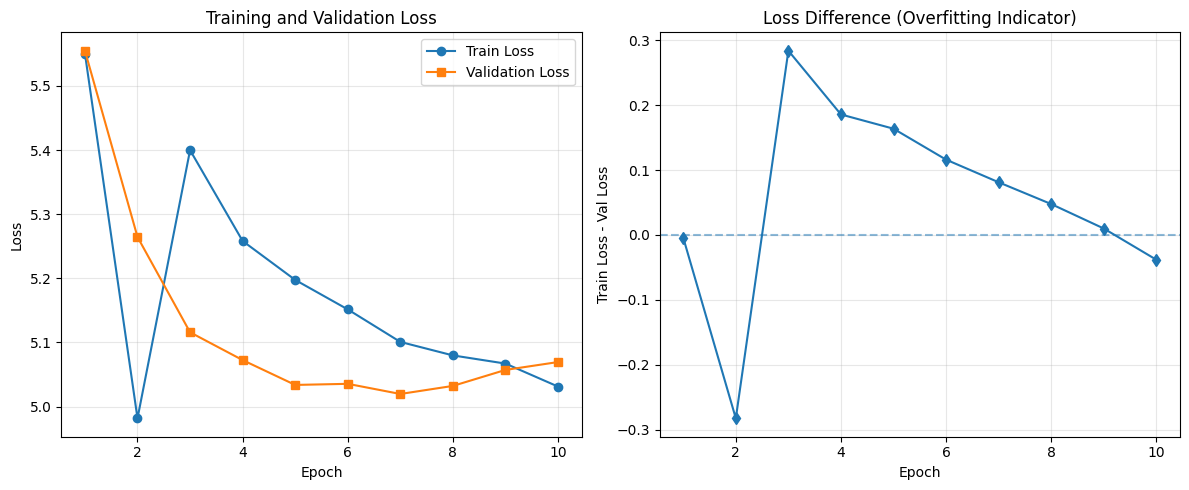

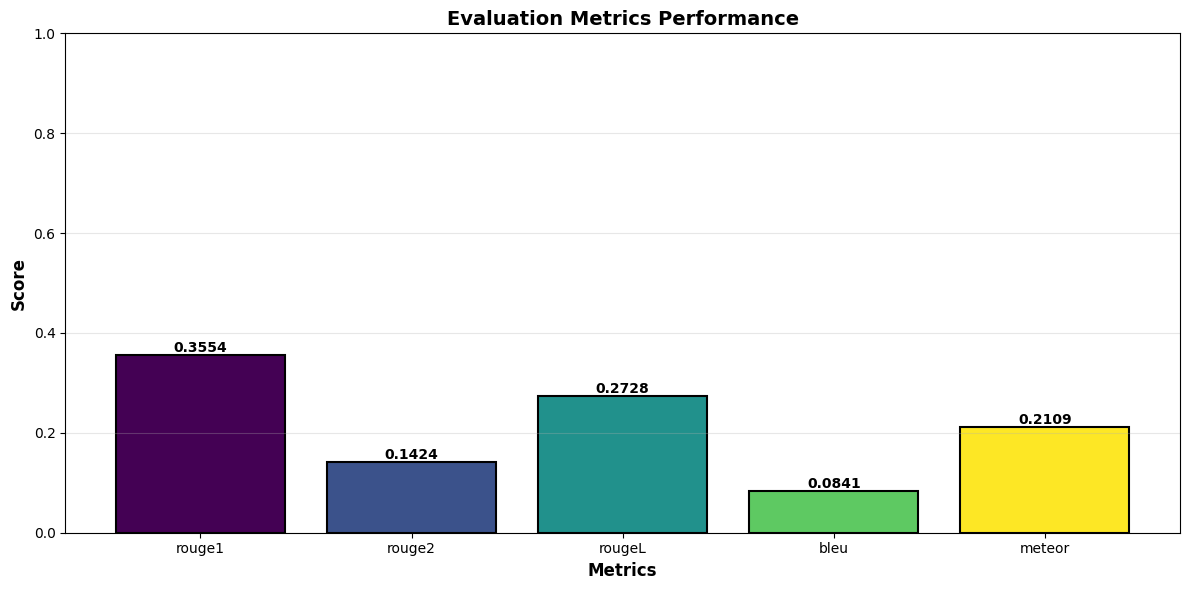

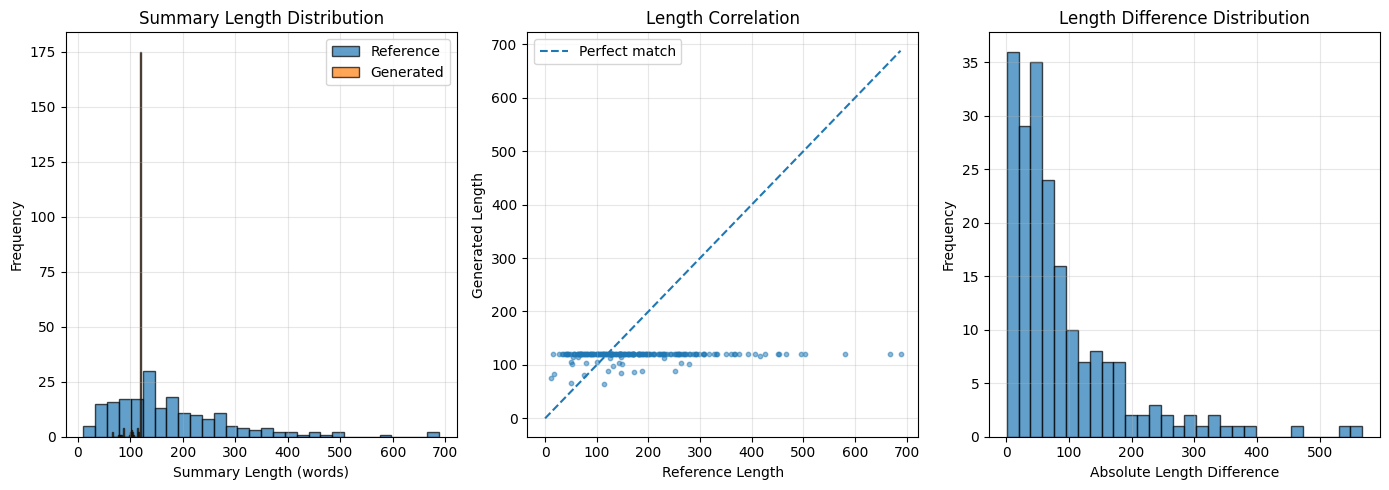


SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)

--- Example 1 ---
Reference: amends the water resources development act of 1999 to: (1) authorize appropriations for fy 1999 through 2009 for implementation of a long-term resource monitoring program with respect to the upper mississippi river environmental management program (currently, such funding is designated for a program for the planning, construction, and evaluation of measures for fish and wildlife habitat rehabilita...
Generated: amends the water resources development act of 1992 to revise the environmental protection agency (epa) to the environmental protection agency (epa) to the environmental protection agency (epa) to the environmental protection agency (epa) by the water resources control and environmental protection agency (epa) to the water conservation and development of the water conservation and development of th...

--- Example 2 ---
Reference: federal forage fee act of 1993 - subjects grazing operations on f

In [7]:
# ==============================================================
#                        VISUALIZATION
# ==============================================================
def plot_training_history(train_losses, val_losses):
    plt.figure(figsize=(12, 5))

    # Loss curves
    plt.subplot(1, 2, 1)
    epochs = range(1, len(train_losses) + 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Validation Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Overfitting indicator
    plt.subplot(1, 2, 2)
    improvement = [(train_losses[i] - val_losses[i]) for i in range(len(train_losses))]
    plt.plot(epochs, improvement, marker='d')
    plt.xlabel('Epoch')
    plt.ylabel('Train Loss - Val Loss')
    plt.title('Loss Difference (Overfitting Indicator)')
    plt.axhline(y=0, linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics(metrics_dict):
    plt.figure(figsize=(12, 6))

    metrics_names = list(metrics_dict.keys())
    metrics_values = list(metrics_dict.values())

    colors = plt.cm.viridis(np.linspace(0, 1, len(metrics_names)))
    bars = plt.bar(metrics_names, metrics_values,
                   color=colors, edgecolor='black', linewidth=1.5)

    plt.xlabel('Metrics', fontsize=12, fontweight='bold')
    plt.ylabel('Score', fontsize=12, fontweight='bold')
    plt.title('Evaluation Metrics Performance', fontsize=14, fontweight='bold')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)

    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.4f}',
                 ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

def plot_summary_length_comparison(references, hypotheses):
    ref_lengths = [len(ref.split()) for ref in references]
    hyp_lengths = [len(hyp.split()) for hyp in hypotheses]

    plt.figure(figsize=(14, 5))

    # Histogram of lengths
    plt.subplot(1, 3, 1)
    plt.hist(ref_lengths, bins=30, alpha=0.7,
             label='Reference', edgecolor='black')
    plt.hist(hyp_lengths, bins=30, alpha=0.7,
             label='Generated', edgecolor='black')
    plt.xlabel('Summary Length (words)')
    plt.ylabel('Frequency')
    plt.title('Summary Length Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Scatter correlation
    plt.subplot(1, 3, 2)
    plt.scatter(ref_lengths, hyp_lengths, alpha=0.5, s=10)
    if ref_lengths and hyp_lengths:
        max_len = max(max(ref_lengths), max(hyp_lengths))
    else:
        max_len = 1
    plt.plot([0, max_len], [0, max_len], '--', label='Perfect match')
    plt.xlabel('Reference Length')
    plt.ylabel('Generated Length')
    plt.title('Length Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # ✅ FIXED BUG HERE: use hyp_lengths, not raw hypotheses
    plt.subplot(1, 3, 3)
    length_diff = [abs(r - h) for r, h in zip(ref_lengths, hyp_lengths)]
    plt.hist(length_diff, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Absolute Length Difference')
    plt.ylabel('Frequency')
    plt.title('Length Difference Distribution')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==============================================================
#                           MAIN
# ==============================================================
def main():
    # Configuration: pointer-generator + coverage + GRU + beam search
    config = {
        'train_csv': "billsum_train.csv",
        'test_csv': "billsum_test.csv",
        'embed_dim': 256,
        'hidden_dim': 256,
        'num_layers': 1,
        'dropout': 0.3,
        'batch_size': 8,
        'num_epochs': 10,
        'learning_rate': 5e-4,
        'max_vocab_size': 8000,
        'min_freq': 1,
        'max_text_len': 250,
        'max_summary_len': 120,
        'sample_size': 3000,
        'coverage_lambda': 1.0,
        'coverage_warmup': 2,
        'beam_width': 4
    }

    print("="*60)
    print("LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH")
    print("="*60)

    # ---------------------- Load Data ----------------------
    print("\n[1/7] Loading datasets...")
    train_df = pd.read_csv(config['train_csv']).head(config['sample_size'])
    test_df = pd.read_csv(config['test_csv']).head(500)

    print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

    # ---------------------- Preprocess ----------------------
    print("\n[2/7] Building vocabulary and preprocessing...")
    preprocessor = TextPreprocessor(
        max_vocab_size=config['max_vocab_size'],
        min_freq=config['min_freq']
    )
    preprocessor.build_vocab(
        train_df['text'].tolist() + train_df['summary'].tolist()
    )

    # ---------------------- Datasets ----------------------
    train_dataset = BillSumDataset(
        train_df['text'].tolist(),
        train_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )

    test_dataset = BillSumDataset(
        test_df['text'].tolist(),
        test_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        collate_fn=collate_fn
    )

    # ---------------------- Model ----------------------
    print("\n[3/7] Building Pointer-Generator Seq2Seq model...")
    clear_memory()

    encoder = Encoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        config['num_layers'],
        config['dropout'],
        bidirectional=True
    )
    decoder = PointerGeneratorDecoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        enc_out_dim=encoder.enc_out_dim,
        num_layers=config['num_layers'],
        dropout=config['dropout']
    )
    model = Seq2SeqPGN(encoder, decoder, device).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

    # ---------------------- Training ----------------------
    print("\n[4/7] Training model (pointer-generator + coverage)...")
    train_losses, val_losses = [], []
    best_val_loss = float('inf')

    start_time = time.time()

    for epoch in range(config['num_epochs']):
        train_loss = train_epoch(
            model, train_loader, optimizer, epoch,
            base_teacher_forcing=0.7,
            decay=0.9,
            coverage_lambda=config['coverage_lambda'],
            coverage_warmup=config['coverage_warmup']
        )
        val_loss = evaluate_epoch(
            model, test_loader,
            coverage_lambda=config['coverage_lambda']
        )
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model_pgn_coverage.pt')
            print("  → New best model saved!")

    training_time = time.time() - start_time
    print(f"\nTraining completed in {training_time/60:.2f} minutes")

    # ---------------------- Load Best ----------------------
    model.load_state_dict(torch.load('best_model_pgn_coverage.pt',
                                     map_location=device))

    # ---------------------- Generate Summaries ----------------------
    print("\n[5/7] Generating summaries on test set (beam search + pointer)...")
    references = []
    hypotheses = []

    for i in tqdm(range(min(200, len(test_df))), desc="Generating"):
        text = test_df.iloc[i]['text']
        reference = test_df.iloc[i]['summary']

        encoded = torch.LongTensor(
            preprocessor.encode(text, config['max_text_len'])
        )
        hypothesis = generate_summary_beam(
            model,
            encoded,
            preprocessor,
            max_len=config['max_summary_len'],
            beam_width=config['beam_width'],
            length_norm=True,
            unk_penalty=1.0,
            repeat_penalty=0.7
        )

        references.append(preprocessor.normalize_text(reference))
        hypotheses.append(hypothesis)

    # ---------------------- Evaluation ----------------------
    print("\n[6/7] Calculating evaluation metrics...")
    evaluator = EvaluationMetrics()
    metrics = evaluator.calculate_all_metrics(references, hypotheses)

    print("\n" + "="*60)
    print("EVALUATION RESULTS")
    print("="*60)
    for metric, value in metrics.items():
        print(f"{metric.upper()}: {value:.4f}")
    print("="*60)

    # ---------------------- Visualizations ----------------------
    print("\n[7/7] Generating visualizations...")
    plot_training_history(train_losses, val_losses)
    plot_metrics(metrics)
    plot_summary_length_comparison(references, hypotheses)

    # ---------------------- Sample Outputs ----------------------
    print("\n" + "="*60)
    print("SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)")
    print("="*60)
    for i in range(min(3, len(references))):
        print(f"\n--- Example {i+1} ---")
        print(f"Reference: {references[i][:400]}...")
        print(f"Generated: {hypotheses[i][:400]}...")

    print("\n✓ Training and evaluation completed successfully!")
    print(f"✓ Total execution time (training only): {training_time/60:.2f} minutes")

    return model, preprocessor, metrics

if __name__ == "__main__":
    model, preprocessor, metrics = main()


Using device: cuda
LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH

[1/7] Loading datasets...
Train samples: 3000, Test samples: 500

[2/7] Building vocabulary and preprocessing...


Building vocabulary: 100%|████████████████████████████████████████████████████████| 6000/6000 [00:01<00:00, 5023.03it/s]


Vocabulary size: 8000 (min_freq=1)

[3/7] Building Pointer-Generator Seq2Seq model...
Total trainable parameters: 14,071,617

[4/7] Training model (pointer-generator + coverage)...


Training (epoch 1): 100%|█████████████████████████████████████████████████████████████| 375/375 [01:16<00:00,  4.89it/s]


Epoch 1/10 | Train Loss: 6.2170 | Val Loss: 5.5509
  → New best model saved!


...

Epoch 10/10 | Train Loss: 5.0615 | Val Loss: 5.0586

Training completed in 13.69 minutes

[5/7] Generating summaries on test set (beam search + pointer)...


Generating: 100%|█████████████████████████████████████████████████████████████████████| 200/200 [00:58<00:00,  3.44it/s]



[6/7] Calculating evaluation metrics...


Calculating metrics: 100%|███████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 180.00it/s]



EVALUATION RESULTS
ROUGE1: 0.3726
ROUGE2: 0.1430
ROUGEL: 0.2703
BLEU: 0.0818
METEOR: 0.2128

[7/7] Generating visualizations...


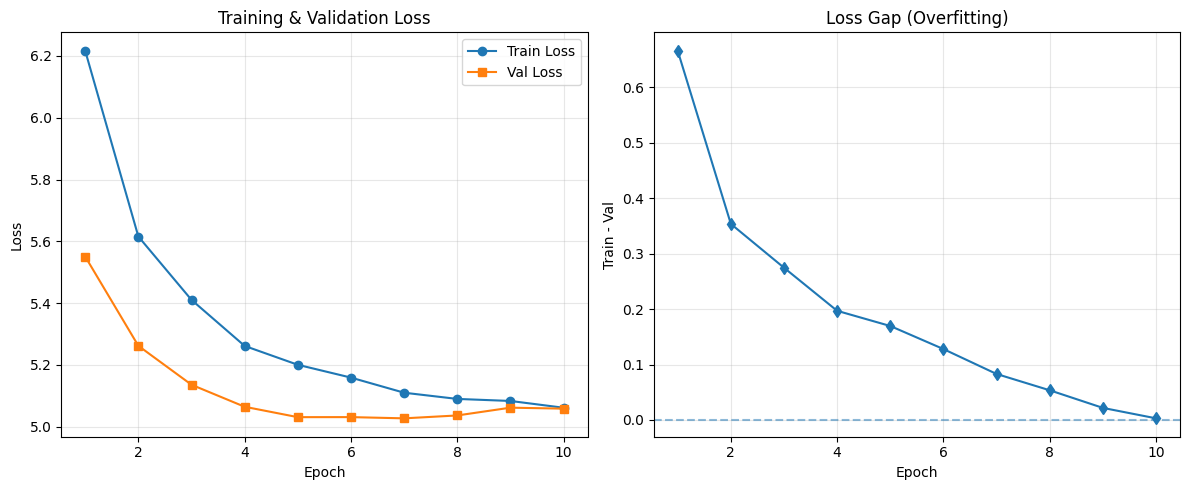

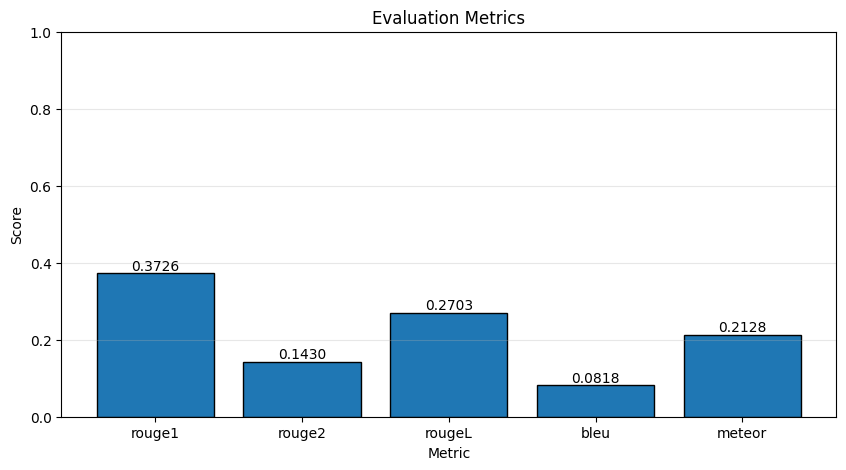

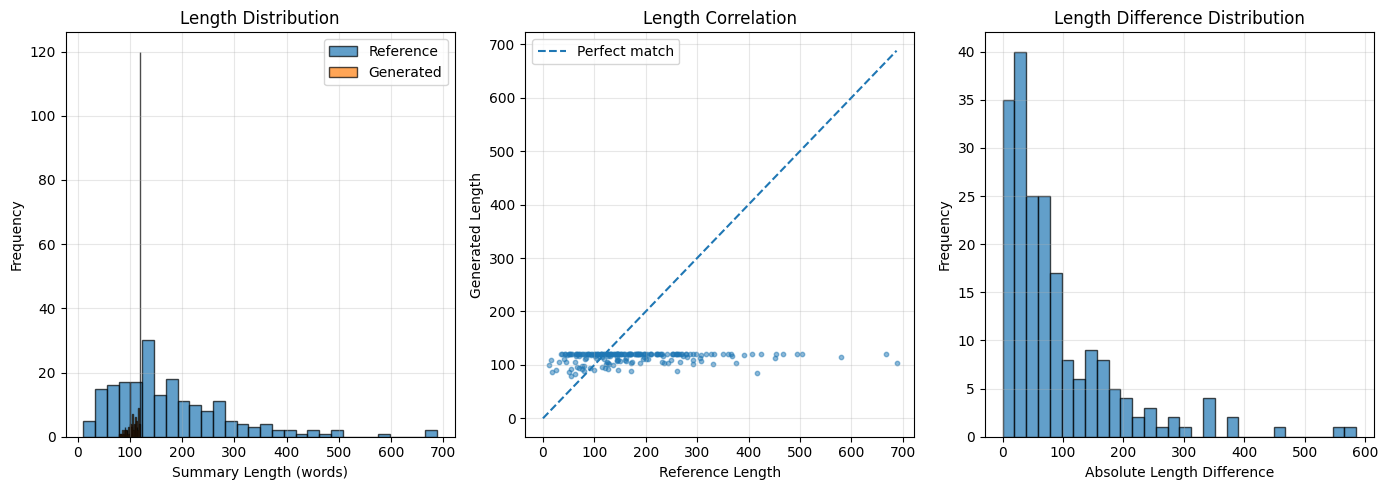


SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)

--- Example 1 ---
Reference: amends the water resources development act of 1999 to: (1) authorize appropriations for fy 1999 through 2009 for implementation of a long-term resource monitoring program with respect to the upper mississippi river environmental management program (currently, such funding is designated for a program for the planning, construction, and evaluation of measures for fish and wildlife habitat rehabilita...
Generated: amends the water resources development act of 1992 to revise the environmental protection agency (epa) to <UNK> the the <UNK> of the water pollution and <UNK> combined acreage <UNK> <UNK> <UNK> the <UNK> resources of development <UNK> <UNK> water pollution <UNK> <UNK> and the the resources and development of the <UNK> the water water pollution development of <UNK> water <UNK> and water pollution t...

--- Example 2 ---
Reference: federal forage fee act of 1993 - subjects grazing operations on f

In [13]:
!pip install rouge-score nltk

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from collections import Counter
import re
from tqdm import tqdm
import time
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk
import warnings

warnings.filterwarnings('ignore')

# ------- NLTK SETUP -------
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except Exception:
    pass

# ------- GLOBAL CONSTANTS -------
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

# ==================== PREPROCESSING ====================
class TextPreprocessor:
    def __init__(self, max_vocab_size=8000, min_freq=1):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': PAD_IDX, '<SOS>': SOS_IDX, '<EOS>': EOS_IDX, '<UNK>': UNK_IDX}
        self.idx2word = {PAD_IDX: '<PAD>', SOS_IDX: '<SOS>', EOS_IDX: '<EOS>', UNK_IDX: '<UNK>'}
        self.vocab_size = 4

    def normalize_text(self, text):
        text = re.sub(r'\s+', ' ', str(text))
        text = text.strip().lower()
        return text

    def tokenize(self, text):
        return text.split()

    def build_vocab(self, texts):
        word_freq = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            tokens = self.tokenize(self.normalize_text(text))
            word_freq.update(tokens)

        for word, freq in word_freq.most_common():
            if freq < self.min_freq:
                continue
            if word not in self.word2idx:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1
                if self.vocab_size >= self.max_vocab_size:
                    break

        print(f"Vocabulary size: {self.vocab_size} (min_freq={self.min_freq})")
        return self.vocab_size

    def encode(self, text, max_len=None):
        tokens = self.tokenize(self.normalize_text(text))
        indices = [self.word2idx.get(tok, UNK_IDX) for tok in tokens]
        if max_len:
            indices = indices[:max_len]
        return indices

    def decode(self, indices):
        tokens = [self.idx2word.get(idx, '<UNK>')
                  for idx in indices
                  if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)]
        return ' '.join(tokens)

# ==================== DATASET ====================
class BillSumDataset(Dataset):
    def __init__(self, texts, summaries, preprocessor,
                 max_text_len=250, max_summary_len=120):
        self.texts = texts
        self.summaries = summaries
        self.preprocessor = preprocessor
        self.max_text_len = max_text_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_ids = self.preprocessor.encode(self.texts[idx], self.max_text_len)
        sum_ids = self.preprocessor.encode(self.summaries[idx], self.max_summary_len)
        sum_ids = [SOS_IDX] + sum_ids + [EOS_IDX]
        return torch.LongTensor(text_ids), torch.LongTensor(sum_ids)

def collate_fn(batch):
    texts, sums = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    sums_padded = pad_sequence(sums, batch_first=True, padding_value=PAD_IDX)
    return texts_padded, sums_padded

# ==================== ENCODER (BiGRU) ====================
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=1, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        self.enc_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        outputs, hidden = self.gru(emb)  # outputs: [B,T,enc_out_dim]
        if self.bidirectional:
            # [num_layers*2,B,H] -> [num_layers,2,B,H] -> sum directions
            hidden = hidden.view(self.num_layers, 2, x.size(0), self.hidden_dim).sum(1)
        return outputs, hidden

# ==================== COVERAGE + TEMPORAL ATTENTION ====================
class CoverageAttention(nn.Module):
    """
    Luong-style attention + coverage + temporal penalty
    e_ti = v^T tanh(W_h h_i + W_s s_t + W_c c_ti)
    """
    def __init__(self, hidden_dim, enc_out_dim, attn_dim=256):
        super().__init__()
        self.W_h = nn.Linear(enc_out_dim, attn_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W_c = nn.Linear(1, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, hidden, encoder_outputs, coverage=None,
                prev_attn=None, compute_cov_loss=False, temporal_lambda=0.0):
        """
        hidden: [B, H] (last decoder layer)
        encoder_outputs: [B, T, enc_out_dim]
        coverage: [B, T] or None
        prev_attn: [B, T] or None (for temporal penalty)
        """
        B, T, _ = encoder_outputs.size()

        if coverage is None:
            coverage_prev = encoder_outputs.new_zeros(B, T)
        else:
            coverage_prev = coverage

        enc_feat = self.W_h(encoder_outputs)
        dec_feat = self.W_s(hidden).unsqueeze(1)
        cov_feat = self.W_c(coverage_prev.unsqueeze(2))

        energy = torch.tanh(enc_feat + dec_feat + cov_feat)
        scores = self.v(energy).squeeze(2)           # [B,T]

        attn = torch.softmax(scores, dim=1)          # [B,T]
        context = torch.bmm(attn.unsqueeze(1), encoder_outputs)  # [B,1,enc_out_dim]

        cov_loss = None
        if compute_cov_loss:
            # standard coverage loss
            cov_loss = torch.sum(torch.min(attn, coverage_prev), dim=1)  # [B]

            # temporal smoothness penalty
            if prev_attn is not None and temporal_lambda > 0.0:
                temporal = torch.mean(torch.abs(attn - prev_attn), dim=1)  # [B]
                cov_loss = cov_loss + temporal_lambda * temporal

        new_coverage = coverage_prev + attn

        return context, attn, new_coverage, cov_loss

# ==================== POINTER-GENERATOR DECODER ====================
class PointerGeneratorDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, enc_out_dim,
                 num_layers=1, dropout=0.3, pointer_bias=-0.2):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = CoverageAttention(hidden_dim, enc_out_dim)

        self.gru = nn.GRU(
            embed_dim + enc_out_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)

        # vocab distribution
        self.fc_vocab = nn.Linear(hidden_dim + enc_out_dim + embed_dim, vocab_size)

        # generation probability
        self.p_gen_linear = nn.Linear(hidden_dim + enc_out_dim + embed_dim, 1)
        self.pointer_bias = pointer_bias  # negative = slightly copy-biased

    def forward(self, x, hidden, encoder_outputs, src, coverage=None,
                prev_attn=None, compute_cov_loss=False, temporal_lambda=0.0):
        """
        x: [B,1] input ids
        hidden: [num_layers,B,H]
        encoder_outputs: [B,T,enc_out_dim]
        src: [B,T]
        coverage: [B,T]
        prev_attn: [B,T]
        """
        emb = self.dropout(self.embedding(x))  # [B,1,E]
        last_hidden = hidden[-1]               # [B,H]

        context, attn, new_cov, cov_loss = self.attention(
            last_hidden, encoder_outputs, coverage,
            prev_attn=prev_attn,
            compute_cov_loss=compute_cov_loss,
            temporal_lambda=temporal_lambda
        )

        gru_in = torch.cat([emb, context], dim=2)  # [B,1,E+enc_out_dim]
        out, hidden = self.gru(gru_in, hidden)     # out: [B,1,H]

        out = out.squeeze(1)
        ctx_vec = context.squeeze(1)
        emb_vec = emb.squeeze(1)

        vocab_in = torch.cat([out, ctx_vec, emb_vec], dim=1)  # [B,H+enc_out+E]
        vocab_logits = self.fc_vocab(vocab_in)
        vocab_dist = torch.softmax(vocab_logits, dim=1)       # [B,V]

        # copy distribution
        B, T = src.size()
        copy_dist = torch.zeros_like(vocab_dist)
        copy_dist.scatter_add_(1, src, attn)                  # [B,V]

        # p_gen with bias
        p_gen = torch.sigmoid(self.p_gen_linear(vocab_in) + self.pointer_bias)  # [B,1]

        final_dist = p_gen * vocab_dist + (1 - p_gen) * copy_dist
        final_dist = final_dist.clamp(min=1e-12)

        return final_dist, hidden, new_cov, attn, cov_loss

# ==================== WRAPPER MODEL ====================
class Seq2SeqPGN(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def encode(self, src):
        return self.encoder(src)

    def decode_step(self, x, hidden, encoder_outputs, src, coverage=None,
                    prev_attn=None, compute_cov_loss=False, temporal_lambda=0.0):
        return self.decoder(x, hidden, encoder_outputs, src, coverage,
                            prev_attn=prev_attn,
                            compute_cov_loss=compute_cov_loss,
                            temporal_lambda=temporal_lambda)

# ==================== TRAIN / EVAL LOOPS ====================
def train_epoch(model, dataloader, optimizer, epoch,
                base_teacher_forcing=0.7, decay=0.9,
                coverage_lambda=1.0, temporal_lambda=0.1,
                clip=1.0, device='cuda'):
    model.train()
    epoch_loss = 0.0
    teacher_forcing_ratio = max(0.1, base_teacher_forcing * (decay ** epoch))

    for src, trg in tqdm(dataloader, desc=f"Training (epoch {epoch+1})"):
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()

        enc_out, hidden = model.encode(src)
        B, src_len = src.size()
        trg_len = trg.size(1)

        coverage = src.new_zeros(B, src_len, dtype=torch.float32, device=device)
        prev_attn = None

        total_nll = 0.0
        total_cov = 0.0
        steps = 0

        inp = trg[:, 0].unsqueeze(1)  # SOS

        for t in range(1, trg_len):
            final_dist, hidden, coverage, attn, cov_loss = model.decode_step(
                inp, hidden, enc_out, src, coverage,
                prev_attn=prev_attn,
                compute_cov_loss=True,
                temporal_lambda=temporal_lambda
            )

            target_t = trg[:, t]
            mask = (target_t != PAD_IDX)

            if mask.any():
                probs = final_dist[mask, target_t[mask]]
                nll = -torch.log(probs + 1e-12).mean()
                total_nll = total_nll + nll
                if cov_loss is not None:
                    total_cov = total_cov + cov_loss[mask].mean()
                steps += 1

            # Scheduled teacher forcing
            # teacher forcing (tensor mask)
            teacher_force_mask = (torch.rand_like(target_t.float()) < teacher_forcing_ratio)

            top1 = final_dist.argmax(1)

            next_inp = torch.where(
                teacher_force_mask.bool(),
                target_t,               # teacher forcing
                top1                    # model prediction
            )

            inp = next_inp.unsqueeze(1)


            prev_attn = attn.detach()

        if steps == 0:
            continue

        avg_nll = total_nll / steps
        avg_cov = total_cov / steps
        loss = avg_nll + coverage_lambda * avg_cov

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def evaluate_epoch(model, dataloader,
                   coverage_lambda=1.0, temporal_lambda=0.1,
                   device='cuda'):
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for src, trg in dataloader:
            src, trg = src.to(device), trg.to(device)

            enc_out, hidden = model.encode(src)
            B, src_len = src.size()
            trg_len = trg.size(1)

            coverage = src.new_zeros(B, src_len, dtype=torch.float32, device=device)
            prev_attn = None

            total_nll = 0.0
            total_cov = 0.0
            steps = 0

            inp = trg[:, 0].unsqueeze(1)

            for t in range(1, trg_len):
                final_dist, hidden, coverage, attn, cov_loss = model.decode_step(
                    inp, hidden, enc_out, src, coverage,
                    prev_attn=prev_attn,
                    compute_cov_loss=True,
                    temporal_lambda=temporal_lambda
                )

                target_t = trg[:, t]
                mask = (target_t != PAD_IDX)

                if mask.any():
                    probs = final_dist[mask, target_t[mask]]
                    nll = -torch.log(probs + 1e-12).mean()
                    total_nll = total_nll + nll
                    if cov_loss is not None:
                        total_cov = total_cov + cov_loss[mask].mean()
                    steps += 1

                # pure teacher forcing in eval
                inp = target_t.unsqueeze(1)
                prev_attn = attn

            if steps == 0:
                continue

            avg_nll = total_nll / steps
            avg_cov = total_cov / steps
            loss = avg_nll + coverage_lambda * avg_cov
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# ==================== BEAM SEARCH W/ TRIGRAM BLOCKING ====================
def generate_summary_beam(model, src, preprocessor,
                          max_len=120, beam_width=5,
                          length_norm=True, device='cuda'):
    """
    Beam search decoding with trigram blocking to reduce repetition.
    """
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)
        enc_out, hidden = model.encode(src)
        B, T = src.size()

        coverage0 = src.new_zeros(1, T, dtype=torch.float32, device=device)

        # Each beam: (tokens, hidden, coverage, log_prob, trigram_set, prev_attn)
        beams = [([SOS_IDX], hidden, coverage0, 0.0, set(), None)]

        for _ in range(max_len):
            new_beams = []
            for tokens, h, cov, log_p, trigram_set, prev_attn in beams:
                if tokens[-1] == EOS_IDX:
                    new_beams.append((tokens, h, cov, log_p, trigram_set, prev_attn))
                    continue

                inp = torch.LongTensor([[tokens[-1]]]).to(device)
                final_dist, new_h, new_cov, attn, _ = model.decode_step(
                    inp, h, enc_out, src, cov,
                    prev_attn=prev_attn,
                    compute_cov_loss=False,
                    temporal_lambda=0.0
                )

                log_probs = torch.log(final_dist + 1e-12)
                topk_logp, topk_ids = torch.topk(log_probs, beam_width, dim=1)

                for i in range(beam_width):
                    nid = topk_ids[0, i].item()
                    nlogp = log_p + topk_logp[0, i].item()
                    new_tokens = tokens + [nid]
                    new_trigram_set = set(trigram_set)

                    # trigram blocking
                    if len(new_tokens) >= 3:
                        tri = tuple(new_tokens[-3:])
                        if tri in new_trigram_set:
                            continue
                        new_trigram_set.add(tri)

                    new_beams.append(
                        (new_tokens, new_h, new_cov.clone(), nlogp, new_trigram_set, attn)
                    )

            if not new_beams:
                break

            if length_norm:
                beams = sorted(
                    new_beams,
                    key=lambda x: x[3] / (len(x[0]) ** 0.7),
                    reverse=True
                )[:beam_width]
            else:
                beams = sorted(new_beams, key=lambda x: x[3], reverse=True)[:beam_width]

        best = max(
            beams,
            key=lambda x: x[3] / (len(x[0]) ** 0.7 if length_norm else 1.0)
        )
        best_tokens = best[0]

        if EOS_IDX in best_tokens:
            eos_pos = best_tokens.index(EOS_IDX)
            best_tokens = best_tokens[1:eos_pos]
        else:
            best_tokens = best_tokens[1:]

        return preprocessor.decode(best_tokens)

# ==================== METRICS ====================
class EvaluationMetrics:
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'],
            use_stemmer=True
        )
        self.smooth = SmoothingFunction().method1

    def calculate_rouge(self, reference, hypothesis):
        scores = self.rouge_scorer.score(reference, hypothesis)
        return {
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_f': scores['rougeL'].fmeasure,
        }

    def calculate_bleu(self, reference, hypothesis):
        ref_tokens = reference.split()
        hyp_tokens = hypothesis.split()
        if not hyp_tokens:
            return 0.0
        return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=self.smooth)

    def calculate_meteor(self, reference, hypothesis):
        try:
            return meteor_score([reference.split()], hypothesis.split())
        except Exception:
            return 0.0

    def calculate_all_metrics(self, refs, hyps):
        metrics = {
            'rouge1': [], 'rouge2': [], 'rougeL': [],
            'bleu': [], 'meteor': []
        }
        for ref, hyp in tqdm(zip(refs, hyps), total=len(refs), desc="Calculating metrics"):
            r = self.calculate_rouge(ref, hyp)
            metrics['rouge1'].append(r['rouge1_f'])
            metrics['rouge2'].append(r['rouge2_f'])
            metrics['rougeL'].append(r['rougeL_f'])
            metrics['bleu'].append(self.calculate_bleu(ref, hyp))
            metrics['meteor'].append(self.calculate_meteor(ref, hyp))

        return {k: float(np.mean(v)) for k, v in metrics.items()}

# ==================== VISUALISATION ====================
def plot_training_history(train_losses, val_losses):
    plt.figure(figsize=(12, 5))
    epochs = range(1, len(train_losses) + 1)

    plt.subplot(1, 2, 1)
    plt.plot(epochs, train_losses, label='Train Loss', marker='o')
    plt.plot(epochs, val_losses, label='Val Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training & Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    diff = [train_losses[i] - val_losses[i] for i in range(len(train_losses))]
    plt.plot(epochs, diff, marker='d')
    plt.axhline(0, linestyle='--', alpha=0.5)
    plt.xlabel('Epoch')
    plt.ylabel('Train - Val')
    plt.title('Loss Gap (Overfitting)')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics(metrics):
    names = list(metrics.keys())
    vals = list(metrics.values())

    plt.figure(figsize=(10, 5))
    bars = plt.bar(names, vals, edgecolor='black')
    plt.ylim(0, 1.0)
    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width() / 2., h,
                 f'{h:.4f}', ha='center', va='bottom')
    plt.xlabel('Metric')
    plt.ylabel('Score')
    plt.title('Evaluation Metrics')
    plt.grid(axis='y', alpha=0.3)
    plt.show()

def plot_summary_length_comparison(references, hypotheses):
    ref_lengths = [len(r.split()) for r in references]
    hyp_lengths = [len(h.split()) for h in hypotheses]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.hist(ref_lengths, bins=30, alpha=0.7, label='Reference', edgecolor='black')
    plt.hist(hyp_lengths, bins=30, alpha=0.7, label='Generated', edgecolor='black')
    plt.xlabel('Summary Length (words)')
    plt.ylabel('Frequency')
    plt.title('Length Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    max_len = max(max(ref_lengths), max(hyp_lengths)) if ref_lengths and hyp_lengths else 1
    plt.scatter(ref_lengths, hyp_lengths, alpha=0.5, s=10)
    plt.plot([0, max_len], [0, max_len], '--', label='Perfect match')
    plt.xlabel('Reference Length')
    plt.ylabel('Generated Length')
    plt.title('Length Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    length_diff = [abs(r - h) for r, h in zip(ref_lengths, hyp_lengths)]
    plt.hist(length_diff, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Absolute Length Difference')
    plt.ylabel('Frequency')
    plt.title('Length Difference Distribution')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==================== MAIN ====================
def main():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    torch.backends.cudnn.benchmark = True
    print(f"Using device: {device}")

    config = {
        'train_csv': "billsum_train.csv",
        'test_csv': "billsum_test.csv",
        'embed_dim': 256,
        'hidden_dim': 256,
        'num_layers': 1,
        'dropout': 0.3,
        'batch_size': 8,
        'num_epochs': 10,
        'learning_rate': 5e-4,
        'max_vocab_size': 8000,
        'min_freq': 1,
        'max_text_len': 250,
        'max_summary_len': 120,
        'sample_size': 3000,
        'coverage_lambda': 1.0,
        'temporal_lambda': 0.1,
        'beam_width': 5
    }

    print("=" * 60)
    print("LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH")
    print("=" * 60)

    # 1) Load data
    print("\n[1/7] Loading datasets...")
    train_df = pd.read_csv(config['train_csv']).head(config['sample_size'])
    test_df = pd.read_csv(config['test_csv']).head(500)
    print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

    # 2) Vocab
    print("\n[2/7] Building vocabulary and preprocessing...")
    preprocessor = TextPreprocessor(
        max_vocab_size=config['max_vocab_size'],
        min_freq=config['min_freq']
    )
    preprocessor.build_vocab(train_df['text'].tolist() + train_df['summary'].tolist())

    # 3) Datasets / loaders
    train_dataset = BillSumDataset(
        train_df['text'].tolist(),
        train_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )
    test_dataset = BillSumDataset(
        test_df['text'].tolist(),
        test_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        collate_fn=collate_fn
    )

    # 4) Model
    print("\n[3/7] Building Pointer-Generator Seq2Seq model...")
    encoder = Encoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        config['num_layers'],
        config['dropout'],
        bidirectional=True
    )
    decoder = PointerGeneratorDecoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        enc_out_dim=encoder.enc_out_dim,
        num_layers=config['num_layers'],
        dropout=config['dropout'],
        pointer_bias=-0.2
    )
    model = Seq2SeqPGN(encoder, decoder, device).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

    # 5) Training
    print("\n[4/7] Training model (pointer-generator + coverage)...")
    train_losses, val_losses = [], []
    best_val = float('inf')
    start = time.time()

    for epoch in range(config['num_epochs']):
        train_loss = train_epoch(
            model, train_loader, optimizer, epoch,
            coverage_lambda=config['coverage_lambda'],
            temporal_lambda=config['temporal_lambda'],
            device=device
        )
        val_loss = evaluate_epoch(
            model, test_loader,
            coverage_lambda=config['coverage_lambda'],
            temporal_lambda=config['temporal_lambda'],
            device=device
        )
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "best_model_pgn_coverage.pt")
            print("  → New best model saved!")

    minutes = (time.time() - start) / 60.0
    print(f"\nTraining completed in {minutes:.2f} minutes")

    # 6) Generation & metrics
    model.load_state_dict(torch.load("best_model_pgn_coverage.pt", map_location=device))

    print("\n[5/7] Generating summaries on test set (beam search + pointer)...")
    references, hypotheses = [], []

    for i in tqdm(range(min(200, len(test_df))), desc="Generating"):
        text = test_df.iloc[i]['text']
        ref = test_df.iloc[i]['summary']

        enc = torch.LongTensor(
            preprocessor.encode(text, config['max_text_len'])
        )
        hyp = generate_summary_beam(
            model, enc, preprocessor,
            max_len=config['max_summary_len'],
            beam_width=config['beam_width'],
            device=device
        )

        references.append(preprocessor.normalize_text(ref))
        hypotheses.append(hyp)

    print("\n[6/7] Calculating evaluation metrics...")
    evaluator = EvaluationMetrics()
    metrics = evaluator.calculate_all_metrics(references, hypotheses)

    print("\n" + "=" * 60)
    print("EVALUATION RESULTS")
    print("=" * 60)
    for k, v in metrics.items():
        print(f"{k.upper()}: {v:.4f}")
    print("=" * 60)

    # 7) Visualisations
    print("\n[7/7] Generating visualizations...")
    plot_training_history(train_losses, val_losses)
    plot_metrics(metrics)
    plot_summary_length_comparison(references, hypotheses)

    # Sample outputs
    print("\n" + "=" * 60)
    print("SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)")
    print("=" * 60)
    for i in range(min(3, len(references))):
        print(f"\n--- Example {i+1} ---")
        print(f"Reference: {references[i][:400]}...")
        print(f"Generated: {hypotheses[i][:400]}...")

    print("\n✓ Training and evaluation completed successfully!")
    print(f"✓ Total execution time (training only): {minutes:.2f} minutes")

    return model, preprocessor, metrics

if __name__ == "__main__":
    model, preprocessor, metrics = main()



Using device: cuda
LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH

[1/7] Loading datasets...
Train samples: 3000, Test samples: 500

[2/7] Building vocabulary and preprocessing...


Building vocabulary: 100%|████████████████████████████████████████████████████████| 6000/6000 [00:00<00:00, 6015.99it/s]


Vocabulary size: 8000 (min_freq=1)

[3/7] Building Pointer-Generator Seq2Seq model...
Total trainable parameters: 14,071,617

[4/7] Training model (pointer-generator + coverage)...


Training (epoch 1): 100%|█████████████████████████████████████████████████████████████| 375/375 [01:12<00:00,  5.14it/s]


Epoch 1/10 | Train Loss: 6.2126 | Val Loss: 5.5298
  → New best model saved!


...

Epoch 10/10 | Train Loss: 5.0629 | Val Loss: 5.0568

Training completed in 12.96 minutes

[5/7] Generating summaries on test set (beam search + pointer)...


Generating: 100%|█████████████████████████████████████████████████████████████████████| 200/200 [01:04<00:00,  3.10it/s]



[6/7] Calculating evaluation metrics...


Calculating metrics: 100%|███████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 189.52it/s]



EVALUATION RESULTS
ROUGE1: 0.3838
ROUGE2: 0.1518
ROUGEL: 0.2738
BLEU: 0.0845
METEOR: 0.2181

[7/7] Generating visualizations...


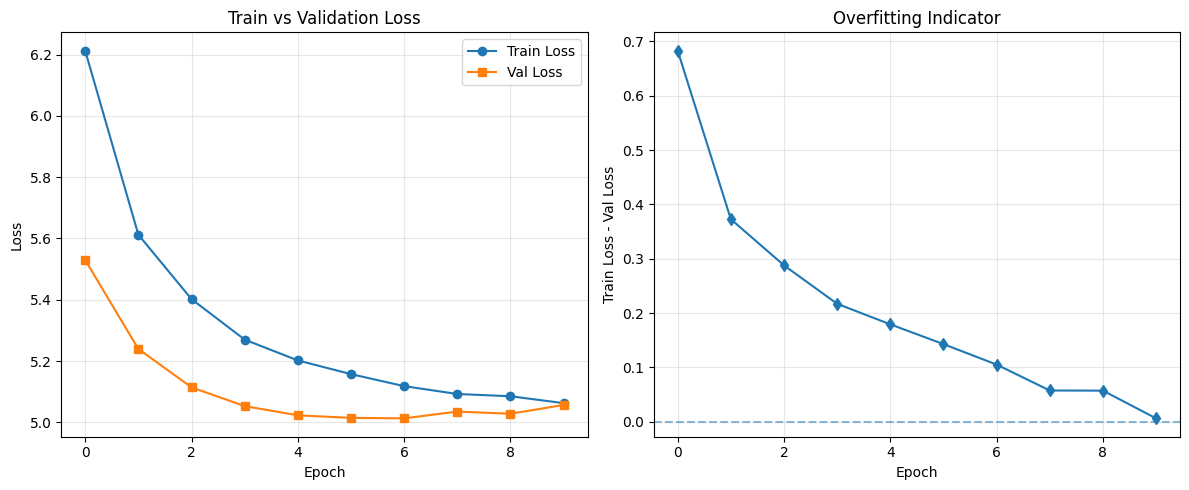

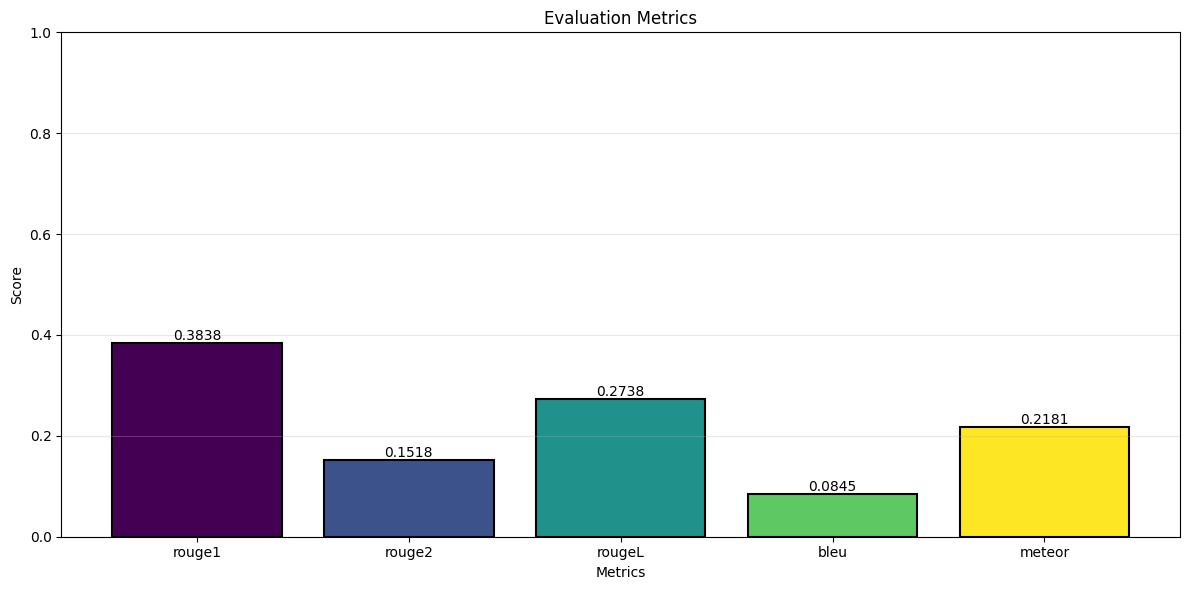

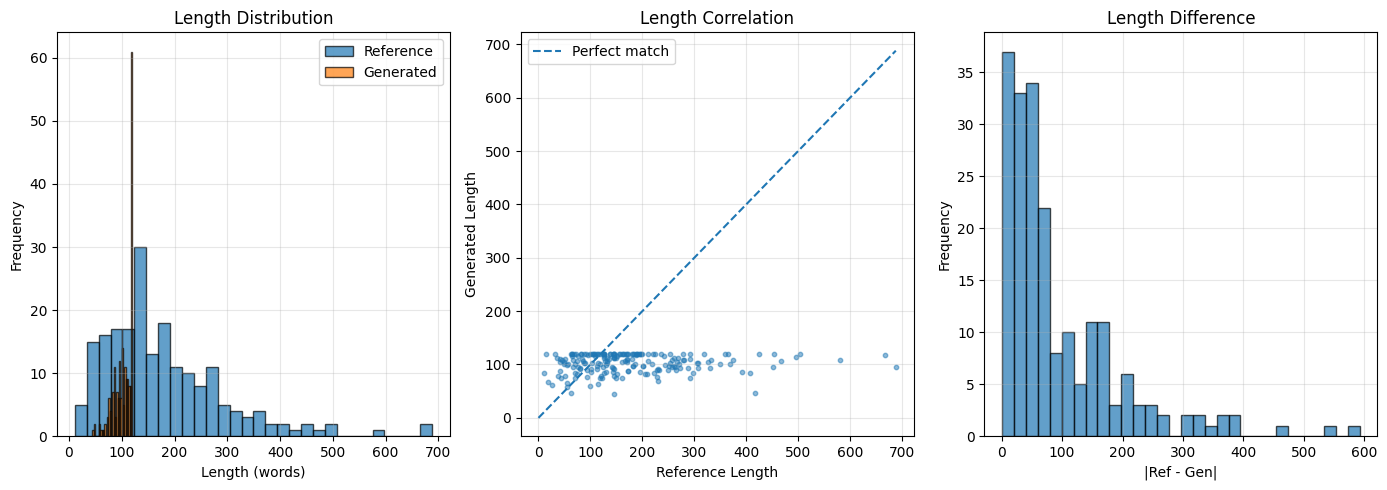


SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)

--- Example 1 ---
Reference: amends the water resources development act of 1999 to: (1) authorize appropriations for fy 1999 through 2009 for implementation of a long-term resource monitoring program with respect to the upper mississippi river environmental management program (currently, such funding is designated for a program for the planning, construction, and evaluation of measures for fish and wildlife habitat rehabilita...
Generated: amends the water resources development act of 1992 to authorize the administrator of the environmental protection agency (epa) 1992 to an alternative water supply and a project for the elimination or control of of combined sewer <UNK> the <UNK> resources and the mississippi of the water and the <UNK> <UNK> the the <UNK> of the <UNK> and <UNK> <UNK> <UNK> water and <UNK> of <UNK> water <UNK> <UNK> ...

--- Example 2 ---
Reference: federal forage fee act of 1993 - subjects grazing operations on f

In [14]:
# ============================================================
# LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + ADVANCED BEAM
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from collections import Counter
import re
from tqdm import tqdm
import time
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk
import warnings
import math

warnings.filterwarnings('ignore')

# ----------------- NLTK SETUP -----------------
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except Exception:
    pass

# ----------------- DEVICE SETUP -----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

# ============================================================
#                  TEXT PREPROCESSOR
# ============================================================
class TextPreprocessor:
    def __init__(self, max_vocab_size=8000, min_freq=1):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': PAD_IDX, '<SOS>': SOS_IDX, '<EOS>': EOS_IDX, '<UNK>': UNK_IDX}
        self.idx2word = {PAD_IDX: '<PAD>', SOS_IDX: '<SOS>', EOS_IDX: '<EOS>', UNK_IDX: '<UNK>'}
        self.vocab_size = 4

    def normalize_text(self, text):
        text = re.sub(r'\s+', ' ', str(text))
        text = text.strip().lower()
        return text

    def tokenize(self, text):
        return text.split()

    def build_vocab(self, texts):
        word_freq = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            tokens = self.tokenize(self.normalize_text(text))
            word_freq.update(tokens)

        for word, freq in word_freq.most_common():
            if freq < self.min_freq:
                break
            if word not in self.word2idx and self.vocab_size < self.max_vocab_size:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1

        print(f"Vocabulary size: {self.vocab_size} (min_freq={self.min_freq})")
        return self.vocab_size

    def encode(self, text, max_len=None):
        tokens = self.tokenize(self.normalize_text(text))
        indices = [self.word2idx.get(tok, UNK_IDX) for tok in tokens]
        if max_len:
            indices = indices[:max_len]
        return indices

    def decode(self, indices):
        tokens = [
            self.idx2word.get(idx, '<UNK>')
            for idx in indices
            if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
        ]
        return ' '.join(tokens)

# ============================================================
#                  DATASET + COLLATE
# ============================================================
class BillSumDataset(Dataset):
    def __init__(self, texts, summaries, preprocessor,
                 max_text_len=250, max_summary_len=120):
        self.texts = texts
        self.summaries = summaries
        self.preprocessor = preprocessor
        self.max_text_len = max_text_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        src = self.preprocessor.encode(self.texts[idx], self.max_text_len)
        trg = self.preprocessor.encode(self.summaries[idx], self.max_summary_len)
        trg = [SOS_IDX] + trg + [EOS_IDX]
        return torch.LongTensor(src), torch.LongTensor(trg)

def collate_fn(batch):
    srcs, trgs = zip(*batch)
    srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    trgs_padded = pad_sequence(trgs, batch_first=True, padding_value=PAD_IDX)
    return srcs_padded, trgs_padded

# ============================================================
#                  ENCODER (BIDIR GRU)
# ============================================================
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=1, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        self.enc_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

    def forward(self, src):
        emb = self.dropout(self.embedding(src))       # [B, T, E]
        outputs, hidden = self.gru(emb)               # outputs: [B, T, enc_out_dim]

        if self.bidirectional:
            # hidden: [num_layers*2, B, H] -> [num_layers, 2, B, H] -> sum directions
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_dim)
            hidden = hidden.sum(dim=1)               # [num_layers, B, H]

        return outputs, hidden                        # outputs: [B,T,enc_out_dim]

# ============================================================
#           COVERAGE ATTENTION (LUONG-STYLE + COVERAGE)
# ============================================================
class CoverageAttention(nn.Module):
    """
    e_ti = v^T tanh(W_h h_i + W_s s_t + W_c c_ti)
    coverage c_ti = sum_{t'<t} a_{t'i}
    """
    def __init__(self, hidden_dim, enc_out_dim, attn_dim=256):
        super().__init__()
        self.W_h = nn.Linear(enc_out_dim, attn_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W_c = nn.Linear(1, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_outputs, coverage=None, compute_cov_loss=False):
        """
        dec_hidden: [B, H] (last decoder layer)
        enc_outputs: [B, T, enc_out_dim]
        coverage: [B, T] or None
        """
        B, T, _ = enc_outputs.size()

        if coverage is None:
            coverage_prev = enc_outputs.new_zeros(B, T)
        else:
            coverage_prev = coverage

        enc_feat = self.W_h(enc_outputs)                          # [B, T, A]
        dec_feat = self.W_s(dec_hidden).unsqueeze(1)              # [B, 1, A]
        cov_feat = self.W_c(coverage_prev.unsqueeze(2))           # [B, T, A]

        energy = torch.tanh(enc_feat + dec_feat + cov_feat)       # [B, T, A]
        scores = self.v(energy).squeeze(2)                        # [B, T]

        attn = torch.softmax(scores, dim=1)                       # [B, T]
        context = torch.bmm(attn.unsqueeze(1), enc_outputs)       # [B, 1, enc_out_dim]

        cov_loss = None
        if compute_cov_loss:
            cov_loss = torch.sum(torch.min(attn, coverage_prev), dim=1)  # [B]

        new_coverage = coverage_prev + attn

        return context, attn, new_coverage, cov_loss

# ============================================================
#            POINTER-GENERATOR DECODER (WITH COVERAGE)
# ============================================================
class PointerGeneratorDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 enc_out_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.enc_out_dim = enc_out_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = CoverageAttention(hidden_dim, enc_out_dim)
        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            embed_dim + enc_out_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc_vocab = nn.Linear(hidden_dim + enc_out_dim + embed_dim, vocab_size)
        self.p_gen_linear = nn.Linear(hidden_dim + enc_out_dim + embed_dim, 1)

    def forward(self, x, hidden, enc_outputs, src, coverage=None, compute_cov_loss=False):
        """
        x: [B, 1]
        hidden: [num_layers, B, H]
        enc_outputs: [B, T, enc_out_dim]
        src: [B, T]
        """
        emb = self.dropout(self.embedding(x))           # [B, 1, E]
        last_hidden = hidden[-1]                        # [B, H]

        context, attn, new_cov, cov_loss = self.attention(
            last_hidden, enc_outputs, coverage, compute_cov_loss=compute_cov_loss
        )                                               # context: [B, 1, enc_out_dim]

        gru_inp = torch.cat((emb, context), dim=2)      # [B, 1, E + enc_out_dim]
        out, hidden = self.gru(gru_inp, hidden)         # out: [B, 1, H]

        out = out.squeeze(1)                            # [B, H]
        ctx_vec = context.squeeze(1)                    # [B, enc_out_dim]
        emb_vec = emb.squeeze(1)                        # [B, E]

        vocab_input = torch.cat((out, ctx_vec, emb_vec), dim=1)  # [B, H+enc_out+E]
        vocab_logits = self.fc_vocab(vocab_input)                # [B, V]
        vocab_dist = torch.softmax(vocab_logits, dim=1)          # [B, V]

        # Copy distribution
        B, T = src.size()
        copy_dist = torch.zeros_like(vocab_dist)                 # [B, V]

        # Clamp indices to avoid out-of-range (very defensive)
        src_clamped = src.clone()
        src_clamped[src_clamped >= self.vocab_size] = UNK_IDX

        copy_dist.scatter_add_(1, src_clamped, attn)             # [B, V]

        # Generation probability
        p_gen = torch.sigmoid(self.p_gen_linear(vocab_input))    # [B, 1]

        final_dist = p_gen * vocab_dist + (1.0 - p_gen) * copy_dist
        final_dist = final_dist.clamp(min=1e-12)

        return final_dist, hidden, new_cov, cov_loss

# ============================================================
#                     SEQ2SEQ WRAPPER
# ============================================================
class Seq2SeqPGN(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def encode(self, src):
        return self.encoder(src)

    def decode_step(self, x, hidden, enc_outputs, src,
                    coverage=None, compute_cov_loss=False):
        return self.decoder(x, hidden, enc_outputs, src,
                            coverage, compute_cov_loss)

# ============================================================
#        TRAINING & EVALUATION (NLL + COVERAGE LOSS)
# ============================================================
def train_epoch(model, dataloader, optimizer, epoch,
                base_teacher_forcing=0.7, decay=0.9,
                coverage_lambda=1.0, clip=1.0):
    model.train()
    epoch_loss = 0.0

    teacher_forcing_ratio = max(0.1, base_teacher_forcing * (decay ** epoch))

    for src, trg in tqdm(dataloader, desc=f"Training (epoch {epoch+1})"):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        enc_outputs, hidden = model.encode(src)
        B, src_len = src.size()
        trg_len = trg.size(1)

        coverage = src.new_zeros(B, src_len, dtype=torch.float32)

        total_nll = 0.0
        total_cov = 0.0
        step_count = 0

        inp = trg[:, 0].unsqueeze(1)   # start with <SOS>

        for t in range(1, trg_len):
            final_dist, hidden, coverage, cov_loss = model.decode_step(
                inp, hidden, enc_outputs, src,
                coverage=coverage,
                compute_cov_loss=True
            )                           # final_dist: [B, V]

            target_t = trg[:, t]        # [B]
            mask = (target_t != PAD_IDX)

            if mask.any():
                probs_t = final_dist[mask, target_t[mask]]
                nll_t = -torch.log(probs_t + 1e-12)
                total_nll += nll_t.mean()
                if cov_loss is not None:
                    total_cov += cov_loss[mask].mean()
                step_count += 1

            # teacher forcing (scalar boolean)
            teacher_force = np.random.random() < teacher_forcing_ratio
            top1 = final_dist.argmax(1)             # [B]
            if teacher_force:
                next_inp = target_t
            else:
                next_inp = top1
            inp = next_inp.unsqueeze(1)

        if step_count == 0:
            continue

        avg_nll = total_nll / step_count
        avg_cov = total_cov / step_count

        loss = avg_nll + coverage_lambda * avg_cov
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def evaluate_epoch(model, dataloader, coverage_lambda=1.0):
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for src, trg in dataloader:
            src = src.to(device)
            trg = trg.to(device)

            enc_outputs, hidden = model.encode(src)
            B, src_len = src.size()
            trg_len = trg.size(1)

            coverage = src.new_zeros(B, src_len, dtype=torch.float32)

            total_nll = 0.0
            total_cov = 0.0
            step_count = 0

            inp = trg[:, 0].unsqueeze(1)

            for t in range(1, trg_len):
                final_dist, hidden, coverage, cov_loss = model.decode_step(
                    inp, hidden, enc_outputs, src,
                    coverage=coverage,
                    compute_cov_loss=True
                )

                target_t = trg[:, t]
                mask = (target_t != PAD_IDX)

                if mask.any():
                    probs_t = final_dist[mask, target_t[mask]]
                    nll_t = -torch.log(probs_t + 1e-12)
                    total_nll += nll_t.mean()
                    if cov_loss is not None:
                        total_cov += cov_loss[mask].mean()
                    step_count += 1

                inp = target_t.unsqueeze(1)   # pure teacher forcing

            if step_count == 0:
                continue

            avg_nll = total_nll / step_count
            avg_cov = total_cov / step_count
            loss = avg_nll + coverage_lambda * avg_cov
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# ============================================================
#         ADVANCED BEAM SEARCH (REPETITION CONTROL)
# ============================================================
def generate_summary_beam(
    model,
    src,
    preprocessor,
    max_len=120,
    beam_width=4,
    length_norm=True,
    min_len=30,
    repetition_penalty=1.2,
    block_trigram=True
):
    """
    Beam search decoding with:
    - pointer-generator + coverage
    - repetition penalty
    - optional trigram blocking
    """
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)          # [1, T]
        enc_outputs, hidden = model.encode(src)
        B, T = src.size()
        assert B == 1

        coverage = src.new_zeros(1, T, dtype=torch.float32)

        # Each beam: (tokens, hidden, coverage, log_prob, trigram_set)
        beams = [([SOS_IDX], hidden, coverage, 0.0, set())]

        for step in range(max_len):
            new_beams = []

            for tokens, h, cov, log_prob, tri_set in beams:
                if tokens[-1] == EOS_IDX and len(tokens) >= min_len:
                    # already finished
                    new_beams.append((tokens, h, cov, log_prob, tri_set))
                    continue

                inp = torch.LongTensor([[tokens[-1]]]).to(device)  # [1,1]
                final_dist, new_hidden, new_cov, _ = model.decode_step(
                    inp, h, enc_outputs, src,
                    coverage=cov,
                    compute_cov_loss=False
                )  # [1, V]

                # log-probs
                log_probs = torch.log(final_dist + 1e-12)          # [1, V]

                # repetition penalty: lower log-probs of tokens already used
                if repetition_penalty != 1.0:
                    used_tokens = set(tokens)
                    for tok in used_tokens:
                        if tok < log_probs.size(1):
                            log_probs[0, tok] -= math.log(repetition_penalty)

                # never generate PAD/SOS as normal tokens
                log_probs[0, PAD_IDX] = -1e9
                log_probs[0, SOS_IDX] = -1e9

                topk_log_probs, topk_ids = torch.topk(log_probs, beam_width, dim=1)

                for i in range(beam_width):
                    next_id = topk_ids[0, i].item()
                    next_log_prob = log_prob + topk_log_probs[0, i].item()

                    new_tokens = tokens + [next_id]
                    new_tri_set = set(tri_set)

                    # trigram blocking
                    if block_trigram and len(new_tokens) >= 3:
                        trigram = tuple(new_tokens[-3:])
                        if trigram in tri_set:
                            # strongly penalize repeating trigram
                            next_log_prob -= 5.0
                        else:
                            new_tri_set.add(trigram)

                    new_beams.append(
                        (new_tokens, new_hidden, new_cov.clone(), next_log_prob, new_tri_set)
                    )

            # keep top beams
            if length_norm:
                beams = sorted(
                    new_beams,
                    key=lambda x: x[3] / (len(x[0]) ** 0.7),
                    reverse=True
                )[:beam_width]
            else:
                beams = sorted(new_beams, key=lambda x: x[3], reverse=True)[:beam_width]

        # choose best finished beam
        best = max(
            beams,
            key=lambda x: x[3] / (len(x[0]) ** 0.7 if length_norm else 1.0)
        )
        best_tokens = best[0]

        # strip SOS/EOS
        if EOS_IDX in best_tokens:
            eos_pos = best_tokens.index(EOS_IDX)
            best_tokens = best_tokens[1:eos_pos]
        else:
            best_tokens = best_tokens[1:]

        return preprocessor.decode(best_tokens)

# ============================================================
#                  EVALUATION METRICS
# ============================================================
class EvaluationMetrics:
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'],
            use_stemmer=True
        )
        self.smooth = SmoothingFunction().method1

    def calculate_rouge(self, reference, hypothesis):
        scores = self.rouge_scorer.score(reference, hypothesis)
        return {
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_f': scores['rougeL'].fmeasure
        }

    def calculate_bleu(self, reference, hypothesis):
        ref_tokens = reference.split()
        hyp_tokens = hypothesis.split()
        if len(hyp_tokens) == 0:
            return 0.0
        return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=self.smooth)

    def calculate_meteor(self, reference, hypothesis):
        try:
            return meteor_score([reference.split()], hypothesis.split())
        except Exception:
            return 0.0

    def calculate_all_metrics(self, references, hypotheses):
        metrics = {
            'rouge1': [], 'rouge2': [], 'rougeL': [],
            'bleu': [], 'meteor': []
        }
        for ref, hyp in tqdm(zip(references, hypotheses),
                             total=len(references),
                             desc="Calculating metrics"):
            r = self.calculate_rouge(ref, hyp)
            metrics['rouge1'].append(r['rouge1_f'])
            metrics['rouge2'].append(r['rouge2_f'])
            metrics['rougeL'].append(r['rougeL_f'])
            metrics['bleu'].append(self.calculate_bleu(ref, hyp))
            metrics['meteor'].append(self.calculate_meteor(ref, hyp))

        return {k: float(np.mean(v)) for k, v in metrics.items()}

# ============================================================
#                       VISUALIZATION
# ============================================================
def plot_training_history(train_losses, val_losses):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    improvement = [train_losses[i] - val_losses[i]
                   for i in range(len(train_losses))]
    plt.plot(improvement, marker='d')
    plt.xlabel('Epoch')
    plt.ylabel('Train Loss - Val Loss')
    plt.title('Overfitting Indicator')
    plt.axhline(y=0, linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics(metrics_dict):
    plt.figure(figsize=(12, 6))
    names = list(metrics_dict.keys())
    vals = list(metrics_dict.values())

    colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
    bars = plt.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)

    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Evaluation Metrics')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)

    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2., h,
                 f'{h:.4f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def plot_summary_length_comparison(references, hypotheses):
    ref_lengths = [len(ref.split()) for ref in references]
    hyp_lengths = [len(hyp.split()) for hyp in hypotheses]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.hist(ref_lengths, bins=30, alpha=0.7, label='Reference', edgecolor='black')
    plt.hist(hyp_lengths, bins=30, alpha=0.7, label='Generated', edgecolor='black')
    plt.xlabel('Length (words)')
    plt.ylabel('Frequency')
    plt.title('Length Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.scatter(ref_lengths, hyp_lengths, alpha=0.5, s=10)
    max_len = max(max(ref_lengths), max(hyp_lengths)) if ref_lengths and hyp_lengths else 1
    plt.plot([0, max_len], [0, max_len], '--', label='Perfect match')
    plt.xlabel('Reference Length')
    plt.ylabel('Generated Length')
    plt.title('Length Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    length_diff = [abs(r - h) for r, h in zip(ref_lengths, hyp_lengths)]
    plt.hist(length_diff, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('|Ref - Gen|')
    plt.ylabel('Frequency')
    plt.title('Length Difference')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
#                           MAIN
# ============================================================
def main():
    config = {
        'train_csv': "billsum_train.csv",    # <-- change if needed
        'test_csv': "billsum_test.csv",      # <-- change if needed
        'embed_dim': 256,
        'hidden_dim': 256,
        'num_layers': 1,
        'dropout': 0.3,
        'batch_size': 8,
        'num_epochs': 10,
        'learning_rate': 5e-4,
        'max_vocab_size': 8000,
        'min_freq': 1,
        'max_text_len': 250,
        'max_summary_len': 120,
        'sample_size': 3000,
        'coverage_lambda': 1.0,
        'beam_width': 4,
        'max_gen_len': 120,
        'min_gen_len': 30,
        'repetition_penalty': 1.2
    }

    print("=" * 60)
    print("LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH")
    print("=" * 60)

    # 1) Load data
    print("\n[1/7] Loading datasets...")
    train_df = pd.read_csv(config['train_csv']).head(config['sample_size'])
    test_df = pd.read_csv(config['test_csv']).head(500)
    print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

    # 2) Build vocab
    print("\n[2/7] Building vocabulary and preprocessing...")
    preprocessor = TextPreprocessor(
        max_vocab_size=config['max_vocab_size'],
        min_freq=config['min_freq']
    )
    preprocessor.build_vocab(
        train_df['text'].tolist() + train_df['summary'].tolist()
    )

    # 3) Create datasets + loaders
    train_dataset = BillSumDataset(
        train_df['text'].tolist(),
        train_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )
    test_dataset = BillSumDataset(
        test_df['text'].tolist(),
        test_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        collate_fn=collate_fn
    )

    # 4) Build model
    print("\n[3/7] Building Pointer-Generator Seq2Seq model...")
    torch.cuda.empty_cache()

    encoder = Encoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        config['num_layers'],
        config['dropout'],
        bidirectional=True
    )
    decoder = PointerGeneratorDecoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        enc_out_dim=encoder.enc_out_dim,
        num_layers=config['num_layers'],
        dropout=config['dropout']
    )
    model = Seq2SeqPGN(encoder, decoder).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

    # 5) Train
    print("\n[4/7] Training model (pointer-generator + coverage)...")
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    start = time.time()

    for epoch in range(config['num_epochs']):
        train_loss = train_epoch(
            model, train_loader, optimizer, epoch,
            coverage_lambda=config['coverage_lambda']
        )
        val_loss = evaluate_epoch(
            model, test_loader,
            coverage_lambda=config['coverage_lambda']
        )
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model_pgn_coverage_advanced.pt')
            print("  → New best model saved!")

    total_time = (time.time() - start) / 60.0
    print(f"\nTraining completed in {total_time:.2f} minutes")

    # 6) Evaluate with best model
    model.load_state_dict(torch.load('best_model_pgn_coverage_advanced.pt', map_location=device))

    print("\n[5/7] Generating summaries on test set (beam search + pointer)...")
    references, hypotheses = [], []

    for i in tqdm(range(min(200, len(test_df))), desc="Generating"):
        text = test_df.iloc[i]['text']
        ref_sum = test_df.iloc[i]['summary']
        src_encoded = torch.LongTensor(preprocessor.encode(text, config['max_text_len']))

        hyp = generate_summary_beam(
            model,
            src_encoded,
            preprocessor,
            max_len=config['max_gen_len'],
            beam_width=config['beam_width'],
            min_len=config['min_gen_len'],
            repetition_penalty=config['repetition_penalty'],
            block_trigram=True
        )

        references.append(preprocessor.normalize_text(ref_sum))
        hypotheses.append(hyp)

    print("\n[6/7] Calculating evaluation metrics...")
    evaluator = EvaluationMetrics()
    metrics = evaluator.calculate_all_metrics(references, hypotheses)

    print("\n" + "="*60)
    print("EVALUATION RESULTS")
    print("="*60)
    for m, v in metrics.items():
        print(f"{m.upper()}: {v:.4f}")
    print("="*60)

    # 7) Visualizations
    print("\n[7/7] Generating visualizations...")
    plot_training_history(train_losses, val_losses)
    plot_metrics(metrics)
    plot_summary_length_comparison(references, hypotheses)

    # Sample outputs
    print("\n" + "="*60)
    print("SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)")
    print("="*60)
    for i in range(min(3, len(references))):
        print(f"\n--- Example {i+1} ---")
        print(f"Reference: {references[i][:400]}...")
        print(f"Generated: {hypotheses[i][:400]}...")

    print("\n✓ Training and evaluation completed successfully!")
    print(f"✓ Total execution time (training only): {total_time:.2f} minutes")

    return model, preprocessor, metrics

if __name__ == "__main__":
    model, preprocessor, metrics = main()


Using device: cuda
LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH (TUNED)

[1/7] Loading datasets...
Train samples: 3000, Test samples: 500

[2/7] Building vocabulary and preprocessing...


Building vocabulary: 100%|████████████████████████████████████████████████████████| 6000/6000 [00:01<00:00, 5455.63it/s]


Vocabulary size: 8000 (min_freq=1)

[3/7] Building Pointer-Generator Seq2Seq model...
Total trainable parameters: 18,768,321

[4/7] Training model (pointer-generator + coverage)...


Training (epoch 1): 100%|█████████████████████████████████████████████████████████████| 375/375 [01:13<00:00,  5.11it/s]


Epoch 1/10 | Train Loss: 6.5295 | Val Loss: 5.8066
  → New best model saved!


...

Epoch 10/10 | Train Loss: 6.0229 | Val Loss: 5.4917

Training completed in 13.02 minutes

[5/7] Generating summaries on test set (beam search + pointer)...


Generating: 100%|█████████████████████████████████████████████████████████████████████| 200/200 [01:43<00:00,  1.93it/s]



[6/7] Calculating evaluation metrics...


Calculating metrics: 100%|███████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 192.99it/s]



EVALUATION RESULTS
ROUGE1: 0.3757
ROUGE2: 0.1296
ROUGEL: 0.2495
BLEU: 0.0701
METEOR: 0.2103

[7/7] Generating visualizations...


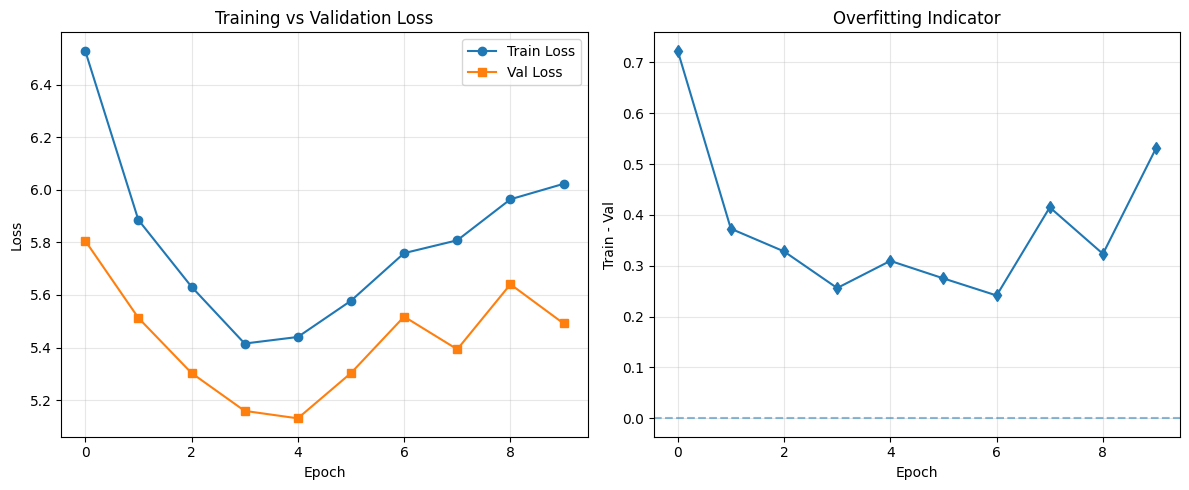

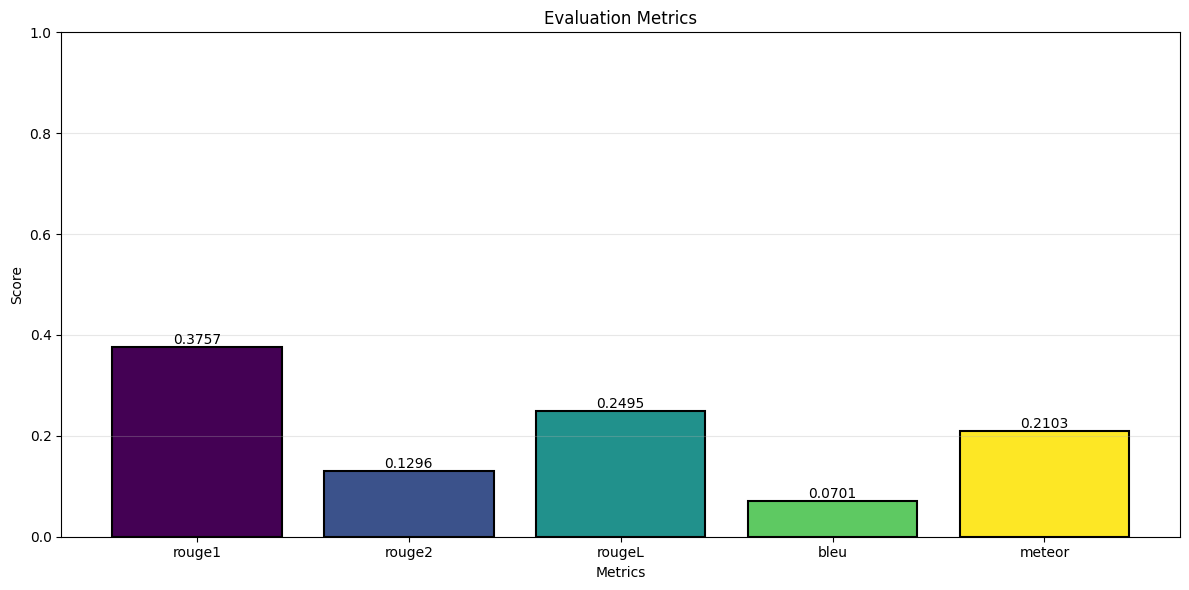

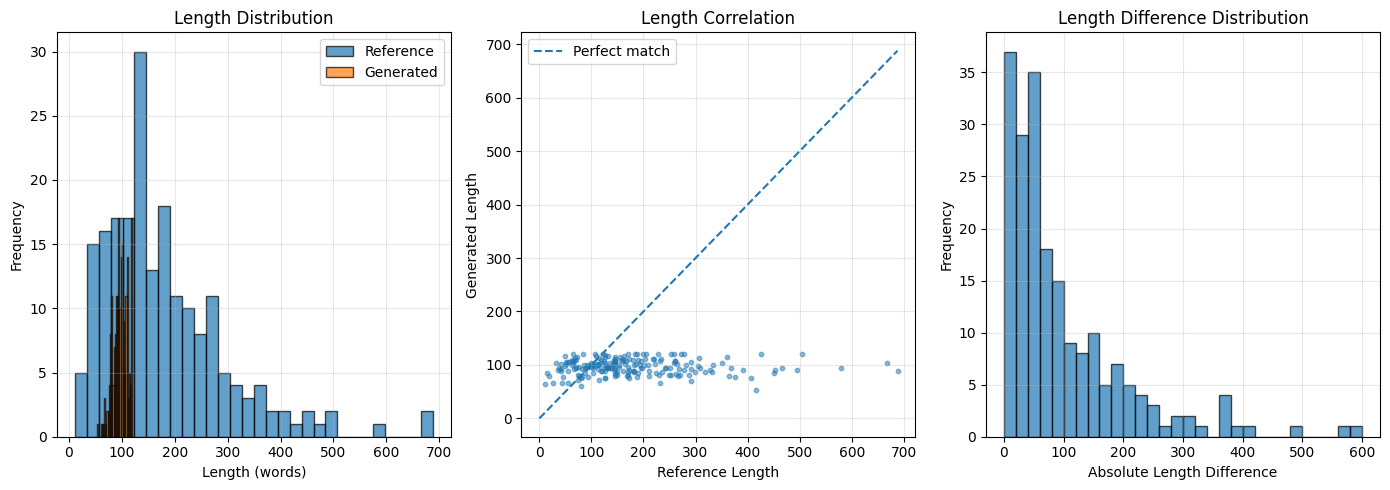


SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)

--- Example 1 ---
Reference: amends the water resources development act of 1999 to: (1) authorize appropriations for fy 1999 through 2009 for implementation of a long-term resource monitoring program with respect to the upper mississippi river environmental management program (currently, such funding is designated for a program for the planning, construction, and evaluation of measures for fish and wildlife habitat rehabilita ...
Generated: amends the water resources resources development act of 1986 to the the water river resources management plan for the <UNK> of the water act) and development of <UNK> <UNK> to <UNK> <UNK> <UNK> the secretary of the interior, acting through the stat. of the <UNK> water control act of 1992 to <UNK> the <UNK> <UNK> for <UNK> and <UNK> <UNK> and the secretary to make grants to the to the new york <UNK ...

--- Example 2 ---
Reference: federal forage fee act of 1993 - subjects grazing operations on

In [16]:
# If you're in a notebook and don't have rouge-score:
# !pip install rouge-score nltk

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from collections import Counter
import re
from tqdm import tqdm
import time
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk
import gc
import warnings

warnings.filterwarnings('ignore')

# Download required NLTK data
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except:
    pass

# -------------------- DEVICE & UTILS --------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# ==================== DATA PREPROCESSING ====================
class TextPreprocessor:
    """
    Simple word-level tokenizer + vocab builder.
    Uses top-k most frequent tokens (with optional min_freq).
    """
    def __init__(self, max_vocab_size=8000, min_freq=1):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {
            '<PAD>': PAD_IDX,
            '<SOS>': SOS_IDX,
            '<EOS>': EOS_IDX,
            '<UNK>': UNK_IDX
        }
        self.idx2word = {v: k for k, v in self.word2idx.items()}
        self.vocab_size = len(self.word2idx)

    def normalize_text(self, text):
        text = re.sub(r'\s+', ' ', str(text))
        text = text.strip().lower()
        return text

    def tokenize(self, text):
        return text.split()

    def build_vocab(self, texts):
        word_freq = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            tokens = self.tokenize(self.normalize_text(text))
            word_freq.update(tokens)

        # Sort by frequency
        sorted_items = word_freq.most_common()

        for word, freq in sorted_items:
            if freq < self.min_freq:
                continue
            if word not in self.word2idx:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1
                if self.vocab_size >= self.max_vocab_size:
                    break

        print(f"Vocabulary size: {self.vocab_size} (min_freq={self.min_freq})")
        return self.vocab_size

    def encode(self, text, max_len=None):
        tokens = self.tokenize(self.normalize_text(text))
        indices = [self.word2idx.get(tok, UNK_IDX) for tok in tokens]
        if max_len is not None:
            indices = indices[:max_len]
        return indices

    def decode(self, indices):
        tokens = [
            self.idx2word.get(idx, '<UNK>')
            for idx in indices
            if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
        ]
        return ' '.join(tokens)

# ==================== DATASET ====================
class BillSumDataset(Dataset):
    def __init__(self, texts, summaries, preprocessor,
                 max_text_len=250, max_summary_len=120):
        self.texts = texts
        self.summaries = summaries
        self.preprocessor = preprocessor
        self.max_text_len = max_text_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text_ids = self.preprocessor.encode(self.texts[idx], self.max_text_len)
        sum_ids = self.preprocessor.encode(self.summaries[idx], self.max_summary_len)
        sum_ids = [SOS_IDX] + sum_ids + [EOS_IDX]
        return torch.LongTensor(text_ids), torch.LongTensor(sum_ids)

def collate_fn(batch):
    texts, sums = zip(*batch)
    texts_padded = pad_sequence(texts, batch_first=True, padding_value=PAD_IDX)
    sums_padded = pad_sequence(sums, batch_first=True, padding_value=PAD_IDX)
    return texts_padded, sums_padded

# ==================== ENCODER ====================
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=1, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)

        self.enc_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

    def forward(self, src):
        # src: [B, T]
        embedded = self.dropout(self.embedding(src))  # [B, T, E]
        outputs, hidden = self.gru(embedded)          # outputs: [B, T, enc_out_dim]

        if self.bidirectional:
            # hidden: [num_layers*2, B, H] -> [num_layers, 2, B, H]
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_dim)
            # sum fwd & bwd -> [num_layers, B, H]
            hidden = hidden.sum(dim=1)

        return outputs, hidden  # outputs: [B, T, enc_out_dim]

# ==================== COVERAGE ATTENTION ====================
class CoverageAttention(nn.Module):
    """
    Luong-style attention with coverage:
    e_ti = v^T tanh(W_h h_i + W_s s_t + W_c c_ti)
    where c_ti is coverage for position i at time t.
    """
    def __init__(self, hidden_dim, enc_out_dim, attn_dim=256):
        super().__init__()
        self.W_h = nn.Linear(enc_out_dim, attn_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W_c = nn.Linear(1, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden_last, encoder_outputs, coverage=None,
                compute_cov_loss=False):
        """
        dec_hidden_last: [B, H]
        encoder_outputs: [B, T, enc_out_dim]
        coverage: [B, T]
        """
        B, T, _ = encoder_outputs.size()

        if coverage is None:
            coverage_prev = encoder_outputs.new_zeros(B, T)
        else:
            coverage_prev = coverage

        enc_feat = self.W_h(encoder_outputs)                # [B, T, A]
        dec_feat = self.W_s(dec_hidden_last).unsqueeze(1)   # [B, 1, A]
        cov_feat = self.W_c(coverage_prev.unsqueeze(2))     # [B, T, A]

        energy = torch.tanh(enc_feat + dec_feat + cov_feat) # [B, T, A]
        scores = self.v(energy).squeeze(2)                  # [B, T]

        attn = torch.softmax(scores, dim=1)                 # [B, T]
        context = torch.bmm(attn.unsqueeze(1), encoder_outputs)  # [B, 1, enc_out_dim]

        cov_loss = None
        if compute_cov_loss:
            # sum_i min(attn_ti, coverage_prev_i)
            cov_loss = torch.sum(torch.min(attn, coverage_prev), dim=1)  # [B]

        new_coverage = coverage_prev + attn
        return context, attn, new_coverage, cov_loss

# ==================== POINTER-GENERATOR DECODER ====================
class PointerGeneratorDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 enc_out_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.enc_out_dim = enc_out_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = CoverageAttention(hidden_dim, enc_out_dim)
        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            embed_dim + enc_out_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.
        )

        self.fc_vocab = nn.Linear(hidden_dim + enc_out_dim + embed_dim, vocab_size)
        self.p_gen_linear = nn.Linear(hidden_dim + enc_out_dim + embed_dim, 1)

    def forward(self, inp, hidden, encoder_outputs, src,
                coverage=None, compute_cov_loss=False):
        """
        inp: [B, 1]
        hidden: [num_layers, B, H]
        encoder_outputs: [B, T, enc_out_dim]
        src: [B, T]
        coverage: [B, T]
        """
        embedded = self.dropout(self.embedding(inp))  # [B, 1, E]
        last_hidden = hidden[-1]                      # [B, H]

        context, attn, new_coverage, cov_loss = self.attention(
            last_hidden, encoder_outputs, coverage, compute_cov_loss
        )  # context: [B, 1, enc_out_dim]

        gru_input = torch.cat([embedded, context], dim=2)  # [B, 1, E+enc]
        output, hidden = self.gru(gru_input, hidden)       # output: [B, 1, H]

        output = output.squeeze(1)          # [B, H]
        context_vec = context.squeeze(1)    # [B, enc_out_dim]
        embedded_vec = embedded.squeeze(1)  # [B, E]

        vocab_input = torch.cat([output, context_vec, embedded_vec], dim=1)
        vocab_logits = self.fc_vocab(vocab_input)          # [B, V]
        vocab_dist = torch.softmax(vocab_logits, dim=1)    # [B, V]

        B, T = src.size()
        copy_dist = torch.zeros_like(vocab_dist)           # [B, V]
        copy_dist.scatter_add_(1, src, attn)               # [B, V]

        p_gen = torch.sigmoid(self.p_gen_linear(vocab_input))  # [B, 1]
        final_dist = p_gen * vocab_dist + (1.0 - p_gen) * copy_dist
        final_dist = final_dist.clamp(min=1e-12)

        return final_dist, hidden, new_coverage, cov_loss

# ==================== SEQ2SEQ WRAPPER ====================
class Seq2SeqPGN(nn.Module):
    def __init__(self, encoder, decoder, device):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def encode(self, src):
        return self.encoder(src)

    def decode_step(self, inp, hidden, encoder_outputs, src,
                    coverage=None, compute_cov_loss=False):
        return self.decoder(inp, hidden, encoder_outputs, src,
                            coverage, compute_cov_loss)

# ==================== TRAINING (NLL + COVERAGE LOSS) ====================
def train_epoch(model, dataloader, optimizer, epoch,
                base_teacher_forcing=0.7, decay=0.9,
                coverage_lambda=1.4, clip=1.0):
    model.train()
    epoch_loss = 0.0

    teacher_forcing_ratio = max(0.1, base_teacher_forcing * (decay ** epoch))

    for src, trg in tqdm(dataloader, desc=f"Training (epoch {epoch+1})"):
        src, trg = src.to(device), trg.to(device)
        optimizer.zero_grad()

        encoder_outputs, hidden = model.encode(src)
        B, src_len = src.size()
        trg_len = trg.size(1)

        coverage = src.new_zeros(B, src_len, dtype=torch.float32)

        total_nll = 0.0
        total_cov = 0.0
        step_count = 0

        inp = trg[:, 0].unsqueeze(1)  # [B, 1]

        for t in range(1, trg_len):
            final_dist, hidden, coverage, cov_loss = model.decode_step(
                inp, hidden, encoder_outputs, src,
                coverage=coverage, compute_cov_loss=True
            )

            target_t = trg[:, t]          # [B]
            mask = (target_t != PAD_IDX)  # [B]

            if mask.any():
                probs_t = final_dist[mask, target_t[mask]]
                nll_t = -torch.log(probs_t + 1e-12)
                total_nll += nll_t.mean()
                if cov_loss is not None:
                    total_cov += cov_loss[mask].mean()
                step_count += 1

            teacher_force = (np.random.random() < teacher_forcing_ratio)
            top1 = final_dist.argmax(1)   # [B]

            # Global choice (per batch), but simple & robust
            next_inp = trg[:, t] if teacher_force else top1
            inp = next_inp.unsqueeze(1)

        if step_count == 0:
            continue

        avg_nll = total_nll / step_count
        avg_cov = total_cov / step_count
        loss = avg_nll + coverage_lambda * avg_cov

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def evaluate_epoch(model, dataloader, coverage_lambda=1.4):
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for src, trg in dataloader:
            src, trg = src.to(device), trg.to(device)

            encoder_outputs, hidden = model.encode(src)
            B, src_len = src.size()
            trg_len = trg.size(1)

            coverage = src.new_zeros(B, src_len, dtype=torch.float32)

            total_nll = 0.0
            total_cov = 0.0
            step_count = 0

            inp = trg[:, 0].unsqueeze(1)

            for t in range(1, trg_len):
                final_dist, hidden, coverage, cov_loss = model.decode_step(
                    inp, hidden, encoder_outputs, src,
                    coverage=coverage, compute_cov_loss=True
                )

                target_t = trg[:, t]
                mask = (target_t != PAD_IDX)

                if mask.any():
                    probs_t = final_dist[mask, target_t[mask]]
                    nll_t = -torch.log(probs_t + 1e-12)
                    total_nll += nll_t.mean()
                    if cov_loss is not None:
                        total_cov += cov_loss[mask].mean()
                    step_count += 1

                # pure teacher forcing in eval
                inp = target_t.unsqueeze(1)

            if step_count == 0:
                continue

            avg_nll = total_nll / step_count
            avg_cov = total_cov / step_count
            loss = avg_nll + coverage_lambda * avg_cov
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# ==================== BEAM SEARCH WITH REPETITION CONTROL ====================
def _apply_repetition_penalty(log_probs, tokens, repetition_penalty):
    """
    Penalize tokens that have already appeared in the sequence.
    log_probs: [1, V]
    tokens: list[int]
    """
    if repetition_penalty <= 1.0 or len(tokens) == 0:
        return log_probs

    log_probs = log_probs.clone()
    unique_tokens = set(tokens)
    penalty = np.log(repetition_penalty)

    # subtract penalty from repeated tokens
    for tok in unique_tokens:
        if tok < log_probs.size(1):
            log_probs[0, tok] -= penalty
    return log_probs

def _has_repeated_trigram(tokens, new_token):
    if len(tokens) < 2:
        return False
    trigram = (tokens[-2], tokens[-1], new_token)
    # check if trigram appeared before in sliding windows
    for i in range(len(tokens) - 2):
        if (tokens[i], tokens[i+1], tokens[i+2]) == trigram:
            return True
    return False

def generate_summary_beam(
    model,
    src,
    preprocessor,
    max_len=120,
    beam_width=6,
    length_alpha=0.7,
    repetition_penalty=1.3,
    min_len=20
):
    """
    Pointer-generator + coverage beam search with repetition penalty & trigram blocking.
    """
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)   # [1, T]
        encoder_outputs, hidden = model.encode(src)
        B, T = src.size()
        assert B == 1

        coverage = src.new_zeros(1, T, dtype=torch.float32)

        # Each beam: (tokens, hidden, coverage, log_prob)
        beams = [([SOS_IDX], hidden, coverage, 0.0)]

        for step in range(max_len):
            new_beams = []

            for tokens, h, cov, log_prob in beams:
                if tokens[-1] == EOS_IDX and step >= min_len:
                    # already finished; keep as is
                    new_beams.append((tokens, h, cov, log_prob))
                    continue

                inp = torch.LongTensor([[tokens[-1]]]).to(device)
                final_dist, new_hidden, new_coverage, _ = model.decode_step(
                    inp, h, encoder_outputs, src,
                    coverage=cov,
                    compute_cov_loss=False
                )  # [1, V]

                log_probs = torch.log(final_dist + 1e-12)  # [1, V]

                # Repetition penalty
                log_probs = _apply_repetition_penalty(
                    log_probs, tokens, repetition_penalty
                )

                # For early timesteps, strongly discourage EOS
                if step < min_len:
                    log_probs[0, EOS_IDX] -= 5.0  # big negative bias

                topk_log_probs, topk_ids = torch.topk(
                    log_probs, beam_width, dim=1
                )

                for i in range(beam_width):
                    next_id = topk_ids[0, i].item()
                    # trigram blocking
                    if _has_repeated_trigram(tokens, next_id):
                        # heavily penalize this expansion
                        candidate_log_prob = log_prob + (topk_log_probs[0, i].item() - 5.0)
                    else:
                        candidate_log_prob = log_prob + topk_log_probs[0, i].item()

                    new_tokens = tokens + [next_id]
                    new_beams.append(
                        (new_tokens, new_hidden, new_coverage.clone(), candidate_log_prob)
                    )

            # length-normalized beam selection
            def score_fn(b):
                toks, _, _, log_p = b
                length = max(len(toks), 1)
                return log_p / (length ** length_alpha)

            beams = sorted(new_beams, key=score_fn, reverse=True)[:beam_width]

        # final best beam
        best_tokens, _, _, _ = max(beams, key=score_fn)

        # strip SOS/EOS
        if EOS_IDX in best_tokens:
            eos_pos = best_tokens.index(EOS_IDX)
            best_tokens = best_tokens[1:eos_pos]
        else:
            best_tokens = best_tokens[1:]

        return preprocessor.decode(best_tokens)

# ==================== METRICS ====================
class EvaluationMetrics:
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'],
            use_stemmer=True
        )
        self.smooth = SmoothingFunction().method1

    def calculate_rouge(self, ref, hyp):
        scores = self.rouge_scorer.score(ref, hyp)
        return {
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_f': scores['rougeL'].fmeasure
        }

    def calculate_bleu(self, ref, hyp):
        ref_tokens = ref.split()
        hyp_tokens = hyp.split()
        if not hyp_tokens:
            return 0.0
        return sentence_bleu([ref_tokens], hyp_tokens,
                             smoothing_function=self.smooth)

    def calculate_meteor(self, ref, hyp):
        try:
            return meteor_score([ref.split()], hyp.split())
        except:
            return 0.0

    def calculate_all_metrics(self, refs, hyps):
        metrics = {
            'rouge1': [], 'rouge2': [], 'rougeL': [],
            'bleu': [], 'meteor': []
        }
        for ref, hyp in tqdm(
            list(zip(refs, hyps)),
            total=len(refs),
            desc="Calculating metrics"
        ):
            r = self.calculate_rouge(ref, hyp)
            metrics['rouge1'].append(r['rouge1_f'])
            metrics['rouge2'].append(r['rouge2_f'])
            metrics['rougeL'].append(r['rougeL_f'])
            metrics['bleu'].append(self.calculate_bleu(ref, hyp))
            metrics['meteor'].append(self.calculate_meteor(ref, hyp))

        return {k: float(np.mean(v)) for k, v in metrics.items()}

# ==================== VISUALIZATION ====================
def plot_training_history(train_losses, val_losses):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    diff = [train_losses[i] - val_losses[i] for i in range(len(train_losses))]
    plt.plot(diff, marker='d')
    plt.axhline(0, linestyle='--', alpha=0.5)
    plt.xlabel('Epoch')
    plt.ylabel('Train - Val')
    plt.title('Overfitting Indicator')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics(metrics_dict):
    plt.figure(figsize=(12, 6))

    names = list(metrics_dict.keys())
    vals = list(metrics_dict.values())

    colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
    bars = plt.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)

    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Evaluation Metrics')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)

    for bar in bars:
        h = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., h,
                 f'{h:.4f}', ha='center', va='bottom')
    plt.tight_layout()
    plt.show()

def plot_summary_length_comparison(references, hypotheses):
    ref_lengths = [len(r.split()) for r in references]
    hyp_lengths = [len(h.split()) for h in hypotheses]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.hist(ref_lengths, bins=30, alpha=0.7, label='Reference', edgecolor='black')
    plt.hist(hyp_lengths, bins=30, alpha=0.7, label='Generated', edgecolor='black')
    plt.xlabel('Length (words)')
    plt.ylabel('Frequency')
    plt.title('Length Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.scatter(ref_lengths, hyp_lengths, alpha=0.5, s=10)
    max_len = max(max(ref_lengths), max(hyp_lengths)) if ref_lengths and hyp_lengths else 1
    plt.plot([0, max_len], [0, max_len], '--', label='Perfect match')
    plt.xlabel('Reference Length')
    plt.ylabel('Generated Length')
    plt.title('Length Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    length_diff = [abs(r - h) for r, h in zip(ref_lengths, hyp_lengths)]
    plt.hist(length_diff, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('Absolute Length Difference')
    plt.ylabel('Frequency')
    plt.title('Length Difference Distribution')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==================== MAIN ====================
def main():
    clear_memory()

    config = {
        'train_csv': "billsum_train.csv",
        'test_csv': "billsum_test.csv",
        'embed_dim': 256,
        'hidden_dim': 384,          # tuned up from 256
        'num_layers': 1,
        'dropout': 0.3,
        'batch_size': 8,
        'num_epochs': 10,
        'learning_rate': 5e-4,
        'max_vocab_size': 8000,
        'min_freq': 1,
        'max_text_len': 250,
        'max_summary_len': 120,
        'sample_size': 3000,
        'coverage_lambda': 1.4,      # stronger coverage loss
        'beam_width': 6,             # wider beam
        'repetition_penalty': 1.3,   # repetition penalty
        'length_alpha': 0.7,
        'min_dec_len': 20
    }

    print("="*60)
    print("LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH (TUNED)")
    print("="*60)

    # 1) Load data
    print("\n[1/7] Loading datasets...")
    train_df = pd.read_csv(config['train_csv']).head(config['sample_size'])
    test_df = pd.read_csv(config['test_csv']).head(500)
    print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

    # 2) Build vocab
    print("\n[2/7] Building vocabulary and preprocessing...")
    preprocessor = TextPreprocessor(
        max_vocab_size=config['max_vocab_size'],
        min_freq=config['min_freq']
    )
    preprocessor.build_vocab(
        train_df['text'].tolist() + train_df['summary'].tolist()
    )

    # 3) Create datasets + loaders
    train_dataset = BillSumDataset(
        train_df['text'].tolist(),
        train_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )
    test_dataset = BillSumDataset(
        test_df['text'].tolist(),
        test_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        collate_fn=collate_fn
    )

    # 4) Build model
    print("\n[3/7] Building Pointer-Generator Seq2Seq model...")
    clear_memory()

    encoder = Encoder(
        vocab_size=preprocessor.vocab_size,
        embed_dim=config['embed_dim'],
        hidden_dim=config['hidden_dim'],
        num_layers=config['num_layers'],
        dropout=config['dropout'],
        bidirectional=True
    )
    decoder = PointerGeneratorDecoder(
        vocab_size=preprocessor.vocab_size,
        embed_dim=config['embed_dim'],
        hidden_dim=config['hidden_dim'],
        enc_out_dim=encoder.enc_out_dim,
        num_layers=config['num_layers'],
        dropout=config['dropout']
    )
    model = Seq2SeqPGN(encoder, decoder, device).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

    # 5) Training loop
    print("\n[4/7] Training model (pointer-generator + coverage)...")
    train_losses, val_losses = [], []
    best_val = float('inf')

    start = time.time()

    for epoch in range(config['num_epochs']):
        train_loss = train_epoch(
            model, train_loader, optimizer, epoch,
            coverage_lambda=config['coverage_lambda'],
            base_teacher_forcing=0.7,
            decay=0.9,
            clip=1.0
        )
        val_loss = evaluate_epoch(
            model, test_loader,
            coverage_lambda=config['coverage_lambda']
        )

        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val:
            best_val = val_loss
            torch.save(model.state_dict(), "best_model_pgn_tuned.pt")
            print("  → New best model saved!")

    train_time = (time.time() - start) / 60.0
    print(f"\nTraining completed in {train_time:.2f} minutes")

    # Load best model
    model.load_state_dict(torch.load("best_model_pgn_tuned.pt", map_location=device))

    # 6) Generate summaries
    print("\n[5/7] Generating summaries on test set (beam search + pointer)...")
    references = []
    hypotheses = []

    for i in tqdm(range(min(200, len(test_df))), desc="Generating"):
        text = test_df.iloc[i]['text']
        ref = test_df.iloc[i]['summary']

        src_ids = preprocessor.encode(text, config['max_text_len'])
        src_tensor = torch.LongTensor(src_ids)
        hyp = generate_summary_beam(
            model,
            src_tensor,
            preprocessor,
            max_len=config['max_summary_len'],
            beam_width=config['beam_width'],
            length_alpha=config['length_alpha'],
            repetition_penalty=config['repetition_penalty'],
            min_len=config['min_dec_len']
        )

        references.append(preprocessor.normalize_text(ref))
        hypotheses.append(hyp)

    # 7) Metrics
    print("\n[6/7] Calculating evaluation metrics...")
    evaluator = EvaluationMetrics()
    metrics = evaluator.calculate_all_metrics(references, hypotheses)

    print("\n" + "="*60)
    print("EVALUATION RESULTS")
    print("="*60)
    for k, v in metrics.items():
        print(f"{k.upper()}: {v:.4f}")
    print("="*60)

    # Visualizations
    print("\n[7/7] Generating visualizations...")
    plot_training_history(train_losses, val_losses)
    plot_metrics(metrics)
    plot_summary_length_comparison(references, hypotheses)

    # Show examples
    print("\n" + "="*60)
    print("SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)")
    print("="*60)
    for i in range(3):
        print(f"\n--- Example {i+1} ---")
        print("Reference:", references[i][:400], "...")
        print("Generated:", hypotheses[i][:400], "...")

    print("\n✓ Training and evaluation completed successfully!")
    print(f"✓ Total execution time (training only): {train_time:.2f} minutes")

    return model, preprocessor, metrics

if __name__ == "__main__":
    model, preprocessor, metrics = main()


Using device: cuda
LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH

[1/7] Loading datasets...
Train samples: 8000, Test samples: 500

[2/7] Building vocabulary and preprocessing...


Building vocabulary: 100%|██████████████████████████████████████████████████████| 16000/16000 [00:02<00:00, 6023.01it/s]


Vocabulary size: 8000 (min_freq=1)

[3/7] Building Pointer-Generator Seq2Seq model...
Total trainable parameters: 23,522,285

[4/7] Training model (pointer-generator + coverage)...


Training (epoch 1): 100%|███████████████████████████████████████████████████████████| 1000/1000 [04:17<00:00,  3.89it/s]


Epoch 1/15 | Train Loss: 5.9764 | Val Loss: 4.8222
  → New best model saved!


...

Epoch 15/15 | Train Loss: 6.8100 | Val Loss: 5.7911

Training completed in 65.69 minutes

[5/7] Generating summaries on test set (beam search + pointer)...


Generating: 100%|█████████████████████████████████████████████████████████████████████| 200/200 [02:17<00:00,  1.46it/s]



[6/7] Calculating evaluation metrics...


Calculating metrics: 100%|████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 72.56it/s]



EVALUATION RESULTS
ROUGE1: 0.4067
ROUGE2: 0.1552
ROUGEL: 0.2713
BLEU: 0.0874
METEOR: 0.2347

[7/7] Generating visualizations...


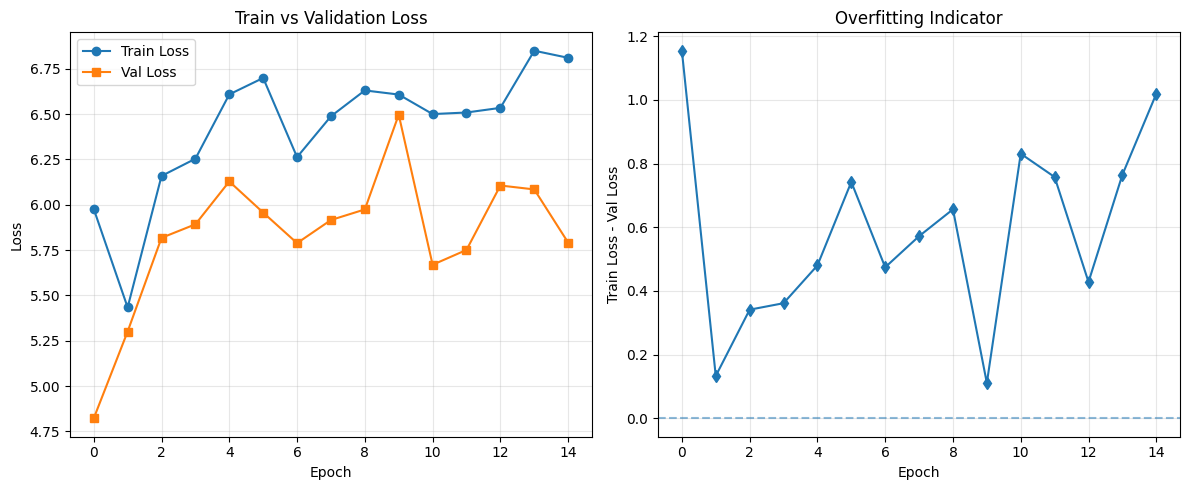

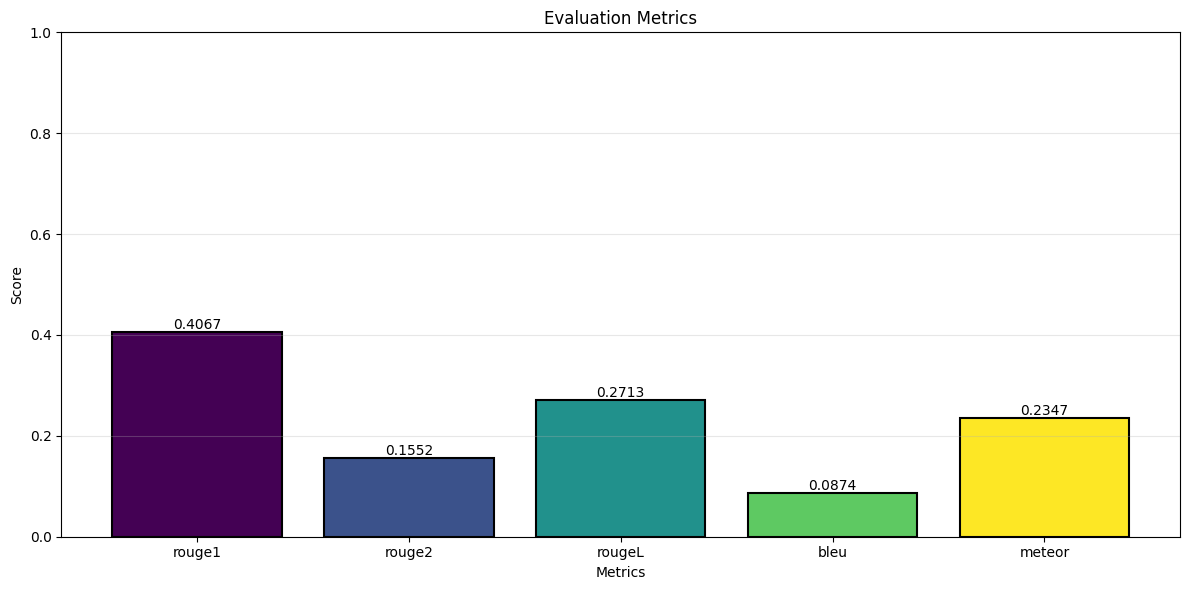

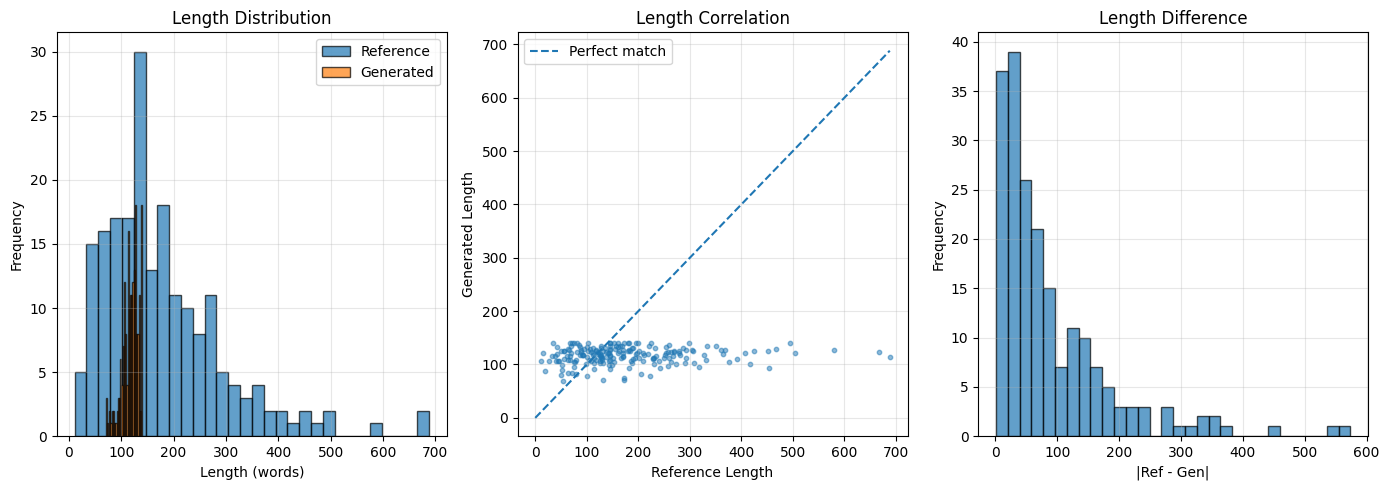


SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)

--- Example 1 ---
Reference: amends the water resources development act of 1999 to: (1) authorize appropriations for fy 1999 through 2009 for implementation of a long-term resource monitoring program with respect to the upper mississippi river environmental management program (currently, such funding is designated for a program for the planning, construction, and evaluation of measures for fish and wildlife habitat rehabilita...
Generated: amends the water resources development act of 1986 to require the environmental protection agency act of <UNK> to establish a mississippi river environmental management and of project alternative of an water water supply and a in the or resources control of the 110 resources development <UNK> of the <UNK> resources of the 1999 resources development of the water river development of <UNK> <UNK> <UN...

--- Example 2 ---
Reference: federal forage fee act of 1993 - subjects grazing operations on f

In [1]:
# ============================================================
# LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + ADVANCED BEAM
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from collections import Counter
import re
from tqdm import tqdm
import time
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk
import warnings
import math

warnings.filterwarnings('ignore')

# ----------------- NLTK SETUP -----------------
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except Exception:
    pass

# ----------------- DEVICE SETUP -----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

# ============================================================
#                  TEXT PREPROCESSOR
# ============================================================
class TextPreprocessor:
    def __init__(self, max_vocab_size=8000, min_freq=1):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': PAD_IDX, '<SOS>': SOS_IDX, '<EOS>': EOS_IDX, '<UNK>': UNK_IDX}
        self.idx2word = {PAD_IDX: '<PAD>', SOS_IDX: '<SOS>', EOS_IDX: '<EOS>', UNK_IDX: '<UNK>'}
        self.vocab_size = 4

    def normalize_text(self, text):
        text = re.sub(r'\s+', ' ', str(text))
        text = text.strip().lower()
        return text

    def tokenize(self, text):
        return text.split()

    def build_vocab(self, texts):
        word_freq = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            tokens = self.tokenize(self.normalize_text(text))
            word_freq.update(tokens)

        for word, freq in word_freq.most_common():
            if freq < self.min_freq:
                break
            if word not in self.word2idx and self.vocab_size < self.max_vocab_size:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1

        print(f"Vocabulary size: {self.vocab_size} (min_freq={self.min_freq})")
        return self.vocab_size

    def encode(self, text, max_len=None):
        tokens = self.tokenize(self.normalize_text(text))
        indices = [self.word2idx.get(tok, UNK_IDX) for tok in tokens]
        if max_len:
            indices = indices[:max_len]
        return indices

    def decode(self, indices):
        tokens = [
            self.idx2word.get(idx, '<UNK>')
            for idx in indices
            if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
        ]
        return ' '.join(tokens)

# ============================================================
#                  DATASET + COLLATE
# ============================================================
class BillSumDataset(Dataset):
    def __init__(self, texts, summaries, preprocessor,
                 max_text_len=250, max_summary_len=120):
        self.texts = texts
        self.summaries = summaries
        self.preprocessor = preprocessor
        self.max_text_len = max_text_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        src = self.preprocessor.encode(self.texts[idx], self.max_text_len)
        trg = self.preprocessor.encode(self.summaries[idx], self.max_summary_len)
        trg = [SOS_IDX] + trg + [EOS_IDX]
        return torch.LongTensor(src), torch.LongTensor(trg)

def collate_fn(batch):
    srcs, trgs = zip(*batch)
    srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    trgs_padded = pad_sequence(trgs, batch_first=True, padding_value=PAD_IDX)
    return srcs_padded, trgs_padded

# ============================================================
#                  ENCODER (BIDIR GRU)
# ============================================================
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=1, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        self.enc_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

    def forward(self, src):
        emb = self.dropout(self.embedding(src))       # [B, T, E]
        outputs, hidden = self.gru(emb)               # outputs: [B, T, enc_out_dim]

        if self.bidirectional:
            # hidden: [num_layers*2, B, H] -> [num_layers, 2, B, H] -> sum directions
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_dim)
            hidden = hidden.sum(dim=1)               # [num_layers, B, H]

        return outputs, hidden                        # outputs: [B,T,enc_out_dim]

# ============================================================
#           COVERAGE ATTENTION (LUONG-STYLE + COVERAGE)
# ============================================================
class CoverageAttention(nn.Module):
    """
    e_ti = v^T tanh(W_h h_i + W_s s_t + W_c c_ti)
    coverage c_ti = sum_{t'<t} a_{t'i}
    """
    def __init__(self, hidden_dim, enc_out_dim, attn_dim=256):
        super().__init__()
        self.W_h = nn.Linear(enc_out_dim, attn_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W_c = nn.Linear(1, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_outputs, coverage=None, compute_cov_loss=False):
        """
        dec_hidden: [B, H] (last decoder layer)
        enc_outputs: [B, T, enc_out_dim]
        coverage: [B, T] or None
        """
        B, T, _ = enc_outputs.size()

        if coverage is None:
            coverage_prev = enc_outputs.new_zeros(B, T)
        else:
            coverage_prev = coverage

        enc_feat = self.W_h(enc_outputs)                          # [B, T, A]
        dec_feat = self.W_s(dec_hidden).unsqueeze(1)              # [B, 1, A]
        cov_feat = self.W_c(coverage_prev.unsqueeze(2))           # [B, T, A]

        energy = torch.tanh(enc_feat + dec_feat + cov_feat)       # [B, T, A]
        scores = self.v(energy).squeeze(2)                        # [B, T]

        attn = torch.softmax(scores, dim=1)                       # [B, T]
        context = torch.bmm(attn.unsqueeze(1), enc_outputs)       # [B, 1, enc_out_dim]

        cov_loss = None
        if compute_cov_loss:
            cov_loss = torch.sum(torch.min(attn, coverage_prev), dim=1)  # [B]

        new_coverage = coverage_prev + attn

        return context, attn, new_coverage, cov_loss

# ============================================================
#            POINTER-GENERATOR DECODER (WITH COVERAGE)
# ============================================================
class PointerGeneratorDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 enc_out_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.enc_out_dim = enc_out_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = CoverageAttention(hidden_dim, enc_out_dim)
        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            embed_dim + enc_out_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc_vocab = nn.Linear(hidden_dim + enc_out_dim + embed_dim, vocab_size)
        self.p_gen_linear = nn.Linear(hidden_dim + enc_out_dim + embed_dim, 1)

    def forward(self, x, hidden, enc_outputs, src, coverage=None, compute_cov_loss=False):
        """
        x: [B, 1]
        hidden: [num_layers, B, H]
        enc_outputs: [B, T, enc_out_dim]
        src: [B, T]
        """
        emb = self.dropout(self.embedding(x))           # [B, 1, E]
        last_hidden = hidden[-1]                        # [B, H]

        context, attn, new_cov, cov_loss = self.attention(
            last_hidden, enc_outputs, coverage, compute_cov_loss=compute_cov_loss
        )                                               # context: [B, 1, enc_out_dim]

        gru_inp = torch.cat((emb, context), dim=2)      # [B, 1, E + enc_out_dim]
        out, hidden = self.gru(gru_inp, hidden)         # out: [B, 1, H]

        out = out.squeeze(1)                            # [B, H]
        ctx_vec = context.squeeze(1)                    # [B, enc_out_dim]
        emb_vec = emb.squeeze(1)                        # [B, E]

        vocab_input = torch.cat((out, ctx_vec, emb_vec), dim=1)  # [B, H+enc_out+E]
        vocab_logits = self.fc_vocab(vocab_input)                # [B, V]
        vocab_dist = torch.softmax(vocab_logits, dim=1)          # [B, V]

        # Copy distribution
        B, T = src.size()
        copy_dist = torch.zeros_like(vocab_dist)                 # [B, V]

        # Clamp indices to avoid out-of-range (very defensive)
        src_clamped = src.clone()
        src_clamped[src_clamped >= self.vocab_size] = UNK_IDX

        copy_dist.scatter_add_(1, src_clamped, attn)             # [B, V]

        # Generation probability
        p_gen = torch.sigmoid(self.p_gen_linear(vocab_input))    # [B, 1]

        final_dist = p_gen * vocab_dist + (1.0 - p_gen) * copy_dist
        final_dist = final_dist.clamp(min=1e-12)

        return final_dist, hidden, new_cov, cov_loss

# ============================================================
#                     SEQ2SEQ WRAPPER
# ============================================================
class Seq2SeqPGN(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def encode(self, src):
        return self.encoder(src)

    def decode_step(self, x, hidden, enc_outputs, src,
                    coverage=None, compute_cov_loss=False):
        return self.decoder(x, hidden, enc_outputs, src,
                            coverage, compute_cov_loss)

# ============================================================
#        TRAINING & EVALUATION (NLL + COVERAGE LOSS)
# ============================================================
def train_epoch(model, dataloader, optimizer, epoch,
                base_teacher_forcing=0.7, decay=0.9,
                coverage_lambda=1.0, clip=1.0):
    model.train()
    epoch_loss = 0.0

    teacher_forcing_ratio = max(0.1, base_teacher_forcing * (decay ** epoch))

    for src, trg in tqdm(dataloader, desc=f"Training (epoch {epoch+1})"):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        enc_outputs, hidden = model.encode(src)
        B, src_len = src.size()
        trg_len = trg.size(1)

        coverage = src.new_zeros(B, src_len, dtype=torch.float32)

        total_nll = 0.0
        total_cov = 0.0
        step_count = 0

        inp = trg[:, 0].unsqueeze(1)   # start with <SOS>

        for t in range(1, trg_len):
            final_dist, hidden, coverage, cov_loss = model.decode_step(
                inp, hidden, enc_outputs, src,
                coverage=coverage,
                compute_cov_loss=True
            )                           # final_dist: [B, V]

            target_t = trg[:, t]        # [B]
            mask = (target_t != PAD_IDX)

            if mask.any():
                probs_t = final_dist[mask, target_t[mask]]
                nll_t = -torch.log(probs_t + 1e-12)
                total_nll += nll_t.mean()
                if cov_loss is not None:
                    total_cov += cov_loss[mask].mean()
                step_count += 1

            # teacher forcing (scalar boolean)
            teacher_force = np.random.random() < teacher_forcing_ratio
            top1 = final_dist.argmax(1)             # [B]
            if teacher_force:
                next_inp = target_t
            else:
                next_inp = top1
            inp = next_inp.unsqueeze(1)

        if step_count == 0:
            continue

        avg_nll = total_nll / step_count
        avg_cov = total_cov / step_count

        loss = avg_nll + coverage_lambda * avg_cov
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def evaluate_epoch(model, dataloader, coverage_lambda=1.0):
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for src, trg in dataloader:
            src = src.to(device)
            trg = trg.to(device)

            enc_outputs, hidden = model.encode(src)
            B, src_len = src.size()
            trg_len = trg.size(1)

            coverage = src.new_zeros(B, src_len, dtype=torch.float32)

            total_nll = 0.0
            total_cov = 0.0
            step_count = 0

            inp = trg[:, 0].unsqueeze(1)

            for t in range(1, trg_len):
                final_dist, hidden, coverage, cov_loss = model.decode_step(
                    inp, hidden, enc_outputs, src,
                    coverage=coverage,
                    compute_cov_loss=True
                )

                target_t = trg[:, t]
                mask = (target_t != PAD_IDX)

                if mask.any():
                    probs_t = final_dist[mask, target_t[mask]]
                    nll_t = -torch.log(probs_t + 1e-12)
                    total_nll += nll_t.mean()
                    if cov_loss is not None:
                        total_cov += cov_loss[mask].mean()
                    step_count += 1

                inp = target_t.unsqueeze(1)   # pure teacher forcing

            if step_count == 0:
                continue

            avg_nll = total_nll / step_count
            avg_cov = total_cov / step_count
            loss = avg_nll + coverage_lambda * avg_cov
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# ============================================================
#         ADVANCED BEAM SEARCH (REPETITION CONTROL)
# ============================================================
def generate_summary_beam(
    model,
    src,
    preprocessor,
    max_len=120,
    beam_width=4,
    length_norm=True,
    min_len=30,
    repetition_penalty=1.2,
    block_trigram=True
):
    """
    Beam search decoding with:
    - pointer-generator + coverage
    - repetition penalty
    - optional trigram blocking
    """
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)          # [1, T]
        enc_outputs, hidden = model.encode(src)
        B, T = src.size()
        assert B == 1

        coverage = src.new_zeros(1, T, dtype=torch.float32)

        # Each beam: (tokens, hidden, coverage, log_prob, trigram_set)
        beams = [([SOS_IDX], hidden, coverage, 0.0, set())]

        for step in range(max_len):
            new_beams = []

            for tokens, h, cov, log_prob, tri_set in beams:
                if tokens[-1] == EOS_IDX and len(tokens) >= min_len:
                    # already finished
                    new_beams.append((tokens, h, cov, log_prob, tri_set))
                    continue

                inp = torch.LongTensor([[tokens[-1]]]).to(device)  # [1,1]
                final_dist, new_hidden, new_cov, _ = model.decode_step(
                    inp, h, enc_outputs, src,
                    coverage=cov,
                    compute_cov_loss=False
                )  # [1, V]

                # log-probs
                log_probs = torch.log(final_dist + 1e-12)          # [1, V]

                # repetition penalty: lower log-probs of tokens already used
                if repetition_penalty != 1.0:
                    used_tokens = set(tokens)
                    for tok in used_tokens:
                        if tok < log_probs.size(1):
                            log_probs[0, tok] -= math.log(repetition_penalty)

                # never generate PAD/SOS as normal tokens
                log_probs[0, PAD_IDX] = -1e9
                log_probs[0, SOS_IDX] = -1e9

                topk_log_probs, topk_ids = torch.topk(log_probs, beam_width, dim=1)

                for i in range(beam_width):
                    next_id = topk_ids[0, i].item()
                    next_log_prob = log_prob + topk_log_probs[0, i].item()

                    new_tokens = tokens + [next_id]
                    new_tri_set = set(tri_set)

                    # trigram blocking
                    if block_trigram and len(new_tokens) >= 3:
                        trigram = tuple(new_tokens[-3:])
                        if trigram in tri_set:
                            # strongly penalize repeating trigram
                            next_log_prob -= 5.0
                        else:
                            new_tri_set.add(trigram)

                    new_beams.append(
                        (new_tokens, new_hidden, new_cov.clone(), next_log_prob, new_tri_set)
                    )

            # keep top beams
            if length_norm:
                beams = sorted(
                    new_beams,
                    key=lambda x: x[3] / (len(x[0]) ** 0.7),
                    reverse=True
                )[:beam_width]
            else:
                beams = sorted(new_beams, key=lambda x: x[3], reverse=True)[:beam_width]

        # choose best finished beam
        best = max(
            beams,
            key=lambda x: x[3] / (len(x[0]) ** 0.7 if length_norm else 1.0)
        )
        best_tokens = best[0]

        # strip SOS/EOS
        if EOS_IDX in best_tokens:
            eos_pos = best_tokens.index(EOS_IDX)
            best_tokens = best_tokens[1:eos_pos]
        else:
            best_tokens = best_tokens[1:]

        return preprocessor.decode(best_tokens)

# ============================================================
#                  EVALUATION METRICS
# ============================================================
class EvaluationMetrics:
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'],
            use_stemmer=True
        )
        self.smooth = SmoothingFunction().method1

    def calculate_rouge(self, reference, hypothesis):
        scores = self.rouge_scorer.score(reference, hypothesis)
        return {
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_f': scores['rougeL'].fmeasure
        }

    def calculate_bleu(self, reference, hypothesis):
        ref_tokens = reference.split()
        hyp_tokens = hypothesis.split()
        if len(hyp_tokens) == 0:
            return 0.0
        return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=self.smooth)

    def calculate_meteor(self, reference, hypothesis):
        try:
            return meteor_score([reference.split()], hypothesis.split())
        except Exception:
            return 0.0

    def calculate_all_metrics(self, references, hypotheses):
        metrics = {
            'rouge1': [], 'rouge2': [], 'rougeL': [],
            'bleu': [], 'meteor': []
        }
        for ref, hyp in tqdm(zip(references, hypotheses),
                             total=len(references),
                             desc="Calculating metrics"):
            r = self.calculate_rouge(ref, hyp)
            metrics['rouge1'].append(r['rouge1_f'])
            metrics['rouge2'].append(r['rouge2_f'])
            metrics['rougeL'].append(r['rougeL_f'])
            metrics['bleu'].append(self.calculate_bleu(ref, hyp))
            metrics['meteor'].append(self.calculate_meteor(ref, hyp))

        return {k: float(np.mean(v)) for k, v in metrics.items()}

# ============================================================
#                       VISUALIZATION
# ============================================================
def plot_training_history(train_losses, val_losses):
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    improvement = [train_losses[i] - val_losses[i]
                   for i in range(len(train_losses))]
    plt.plot(improvement, marker='d')
    plt.xlabel('Epoch')
    plt.ylabel('Train Loss - Val Loss')
    plt.title('Overfitting Indicator')
    plt.axhline(y=0, linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics(metrics_dict):
    plt.figure(figsize=(12, 6))
    names = list(metrics_dict.keys())
    vals = list(metrics_dict.values())

    colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
    bars = plt.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)

    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Evaluation Metrics')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)

    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2., h,
                 f'{h:.4f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def plot_summary_length_comparison(references, hypotheses):
    ref_lengths = [len(ref.split()) for ref in references]
    hyp_lengths = [len(hyp.split()) for hyp in hypotheses]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.hist(ref_lengths, bins=30, alpha=0.7, label='Reference', edgecolor='black')
    plt.hist(hyp_lengths, bins=30, alpha=0.7, label='Generated', edgecolor='black')
    plt.xlabel('Length (words)')
    plt.ylabel('Frequency')
    plt.title('Length Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.scatter(ref_lengths, hyp_lengths, alpha=0.5, s=10)
    max_len = max(max(ref_lengths), max(hyp_lengths)) if ref_lengths and hyp_lengths else 1
    plt.plot([0, max_len], [0, max_len], '--', label='Perfect match')
    plt.xlabel('Reference Length')
    plt.ylabel('Generated Length')
    plt.title('Length Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    length_diff = [abs(r - h) for r, h in zip(ref_lengths, hyp_lengths)]
    plt.hist(length_diff, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('|Ref - Gen|')
    plt.ylabel('Frequency')
    plt.title('Length Difference')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
#                           MAIN
# ============================================================
def main():
    config = {
        'train_csv': "billsum_train.csv",
        'test_csv': "billsum_test.csv",
        'embed_dim': 300,
        'hidden_dim': 384,
        'num_layers': 2,
        'dropout': 0.3,
        'batch_size': 8,
        'num_epochs': 15,
        'learning_rate': 5e-4,
        'max_vocab_size': 8000,
        'min_freq': 1,
        'max_text_len': 512,
        'max_summary_len': 130,
        'sample_size': 8000,
        'coverage_lambda': 1.5,
        'beam_width': 6,
        'max_gen_len': 140,
        'min_gen_len': 50,
        'repetition_penalty': 1.35
    }

    print("=" * 60)
    print("LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH")
    print("=" * 60)

    # 1) Load data
    print("\n[1/7] Loading datasets...")
    train_df = pd.read_csv(config['train_csv']).head(config['sample_size'])
    test_df = pd.read_csv(config['test_csv']).head(500)
    print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

    # 2) Build vocab
    print("\n[2/7] Building vocabulary and preprocessing...")
    preprocessor = TextPreprocessor(
        max_vocab_size=config['max_vocab_size'],
        min_freq=config['min_freq']
    )
    preprocessor.build_vocab(
        train_df['text'].tolist() + train_df['summary'].tolist()
    )

    # 3) Create datasets + loaders
    train_dataset = BillSumDataset(
        train_df['text'].tolist(),
        train_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )
    test_dataset = BillSumDataset(
        test_df['text'].tolist(),
        test_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        collate_fn=collate_fn
    )

    # 4) Build model
    print("\n[3/7] Building Pointer-Generator Seq2Seq model...")
    torch.cuda.empty_cache()

    encoder = Encoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        config['num_layers'],
        config['dropout'],
        bidirectional=True
    )
    decoder = PointerGeneratorDecoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        enc_out_dim=encoder.enc_out_dim,
        num_layers=config['num_layers'],
        dropout=config['dropout']
    )
    model = Seq2SeqPGN(encoder, decoder).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.8)

    # 5) Train
    print("\n[4/7] Training model (pointer-generator + coverage)...")
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    start = time.time()

    for epoch in range(config['num_epochs']):
        train_loss = train_epoch(
            model, train_loader, optimizer, epoch,
            coverage_lambda=config['coverage_lambda']
        )
        val_loss = evaluate_epoch(
            model, test_loader,
            coverage_lambda=config['coverage_lambda']
        )
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model_pgn_coverage_advanced.pt')
            print("  → New best model saved!")

    total_time = (time.time() - start) / 60.0
    print(f"\nTraining completed in {total_time:.2f} minutes")

    # 6) Evaluate with best model
    model.load_state_dict(torch.load('best_model_pgn_coverage_advanced.pt', map_location=device))

    print("\n[5/7] Generating summaries on test set (beam search + pointer)...")
    references, hypotheses = [], []

    for i in tqdm(range(min(200, len(test_df))), desc="Generating"):
        text = test_df.iloc[i]['text']
        ref_sum = test_df.iloc[i]['summary']
        src_encoded = torch.LongTensor(preprocessor.encode(text, config['max_text_len']))

        hyp = generate_summary_beam(
            model,
            src_encoded,
            preprocessor,
            max_len=config['max_gen_len'],
            beam_width=config['beam_width'],
            min_len=config['min_gen_len'],
            repetition_penalty=config['repetition_penalty'],
            block_trigram=True
        )

        references.append(preprocessor.normalize_text(ref_sum))
        hypotheses.append(hyp)

    print("\n[6/7] Calculating evaluation metrics...")
    evaluator = EvaluationMetrics()
    metrics = evaluator.calculate_all_metrics(references, hypotheses)

    print("\n" + "="*60)
    print("EVALUATION RESULTS")
    print("="*60)
    for m, v in metrics.items():
        print(f"{m.upper()}: {v:.4f}")
    print("="*60)

    # 7) Visualizations
    print("\n[7/7] Generating visualizations...")
    plot_training_history(train_losses, val_losses)
    plot_metrics(metrics)
    plot_summary_length_comparison(references, hypotheses)

    # Sample outputs
    print("\n" + "="*60)
    print("SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)")
    print("="*60)
    for i in range(min(3, len(references))):
        print(f"\n--- Example {i+1} ---")
        print(f"Reference: {references[i][:400]}...")
        print(f"Generated: {hypotheses[i][:400]}...")

    print("\n✓ Training and evaluation completed successfully!")
    print(f"✓ Total execution time (training only): {total_time:.2f} minutes")

    return model, preprocessor, metrics

if __name__ == "__main__":
    model, preprocessor, metrics = main()


In [2]:
import torch
print(torch.__version__)


2.7.1+cu118


Using device: cuda
LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH

[1/7] Loading datasets...
Train samples: 8000, Test samples: 500

[2/7] Building vocabulary and preprocessing...


Building vocabulary: 100%|██████████████████████████████████████████████████████| 16000/16000 [00:02<00:00, 6286.87it/s]


Vocabulary size: 8000 (min_freq=1)

[3/7] Building Pointer-Generator Seq2Seq model...
Total trainable parameters: 23,522,285

[4/7] Training model (pointer-generator + coverage)...

Epoch 1/15 | LR: 0.000250 | coverage_lambda: 1.5000


Training (epoch 1): 100%|███████████████████████████████████████████████████████████| 1000/1000 [04:27<00:00,  3.73it/s]


Epoch 1/15 | Train Loss: 6.6854 | Val Loss: 5.6472
  → New best model saved!

Epoch 2/15 | LR: 0.000500 | coverage_lambda: 1.3500


...

Epoch 5/15 | Train Loss: 6.2062 | Val Loss: 5.9337
  → No improvement. Patience: 4/4

Early stopping triggered.

Training completed in 23.00 minutes (for 5 epochs)

[5/7] Generating summaries on test set (beam search + pointer)...


Generating: 100%|█████████████████████████████████████████████████████████████████████| 200/200 [01:51<00:00,  1.80it/s]



[6/7] Calculating evaluation metrics...


Calculating metrics: 100%|████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 77.55it/s]



EVALUATION RESULTS
ROUGE1: 0.3987
ROUGE2: 0.1392
ROUGEL: 0.2577
BLEU: 0.0707
METEOR: 0.2191

[7/7] Generating visualizations...


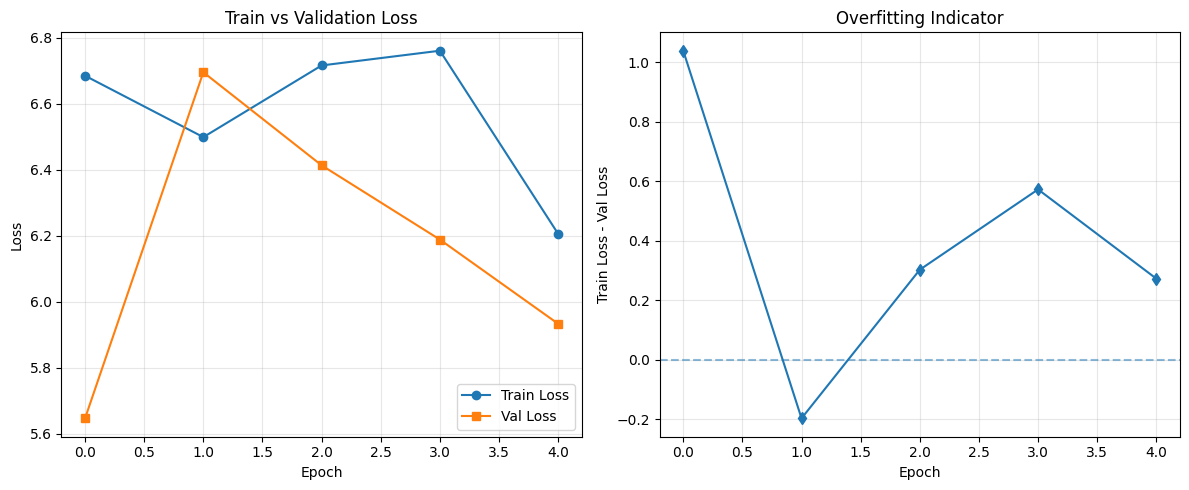

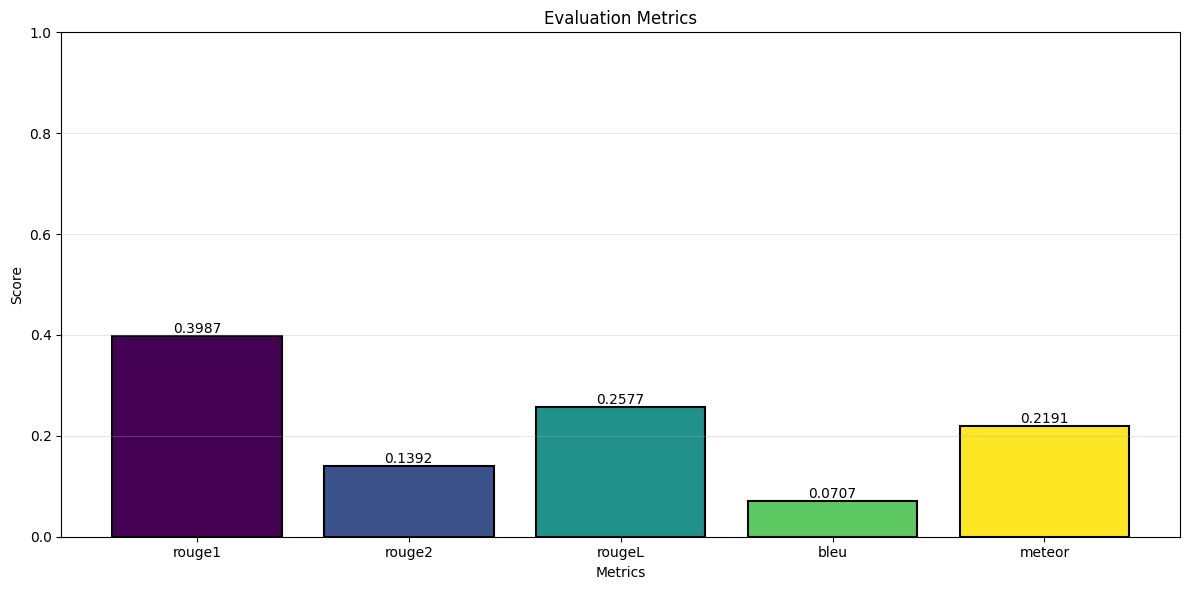

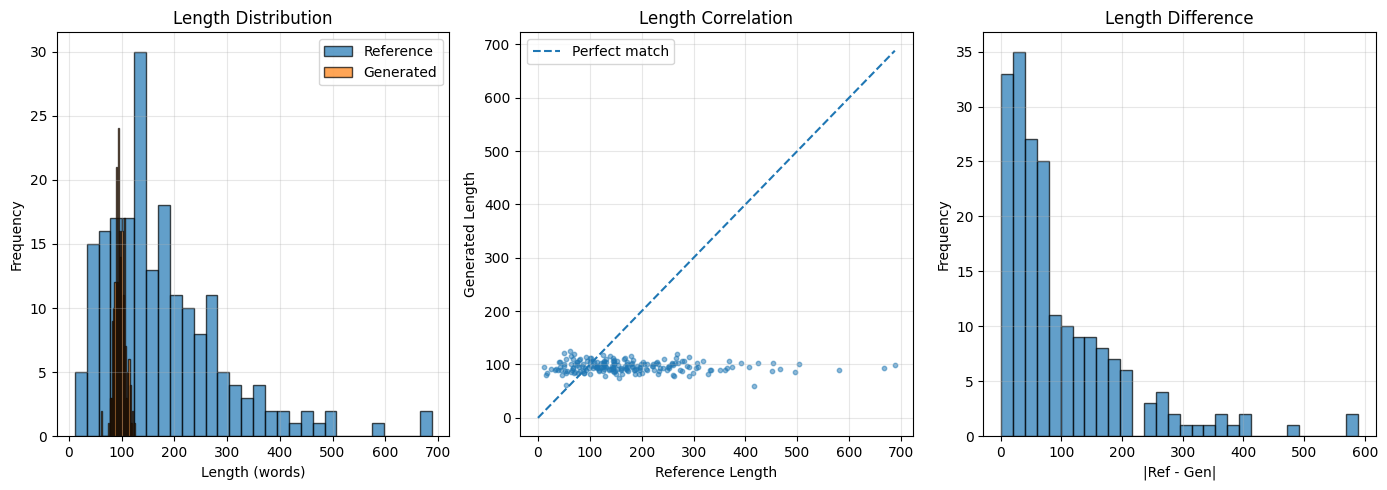


SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)

--- Example 1 ---
Reference: amends the water resources development act of 1999 to: (1) authorize appropriations for fy 1999 through 2009 for implementation of a long-term resource monitoring program with respect to the upper mississippi river environmental management program (currently, such funding is designated for a program for the planning, construction, and evaluation of measures for fish and wildlife habitat rehabilita...
Generated: amends the water resources development act of 1965 to direct the secretary of health and human services to make grants to the provision of the and environmental protection in the 3. <UNK> supply of the an resources development of the social security act to require the the <UNK> of a <UNK> or control of the sewer of the county, resources act of <UNK> to <UNK> the the water of the <UNK> and <UNK> of...

--- Example 2 ---
Reference: federal forage fee act of 1993 - subjects grazing operations on f

In [3]:
# ============================================================
# LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + ADVANCED BEAM
# (Enhanced Training & Decoding – No Transformers)
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from collections import Counter
import re
from tqdm import tqdm
import time
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk
import warnings
import math

warnings.filterwarnings('ignore')

# ----------------- NLTK SETUP -----------------
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except Exception:
    pass

# ----------------- DEVICE SETUP -----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

# ============================================================
#                  TEXT PREPROCESSOR
# ============================================================
class TextPreprocessor:
    def __init__(self, max_vocab_size=8000, min_freq=1):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': PAD_IDX, '<SOS>': SOS_IDX, '<EOS>': EOS_IDX, '<UNK>': UNK_IDX}
        self.idx2word = {PAD_IDX: '<PAD>', SOS_IDX: '<SOS>', EOS_IDX: '<EOS>', UNK_IDX: '<UNK>'}
        self.vocab_size = 4

    def normalize_text(self, text):
        text = re.sub(r'\s+', ' ', str(text))
        text = text.strip().lower()
        return text

    def tokenize(self, text):
        return text.split()

    def build_vocab(self, texts):
        word_freq = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            tokens = self.tokenize(self.normalize_text(text))
            word_freq.update(tokens)

        for word, freq in word_freq.most_common():
            if freq < self.min_freq:
                break
            if word not in self.word2idx and self.vocab_size < self.max_vocab_size:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1

        print(f"Vocabulary size: {self.vocab_size} (min_freq={self.min_freq})")
        return self.vocab_size

    def encode(self, text, max_len=None):
        tokens = self.tokenize(self.normalize_text(text))
        indices = [self.word2idx.get(tok, UNK_IDX) for tok in tokens]
        if max_len:
            indices = indices[:max_len]
        return indices

    def decode(self, indices):
        tokens = [
            self.idx2word.get(idx, '<UNK>')
            for idx in indices
            if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
        ]
        return ' '.join(tokens)

# ============================================================
#                  DATASET + COLLATE
# ============================================================
class BillSumDataset(Dataset):
    def __init__(self, texts, summaries, preprocessor,
                 max_text_len=250, max_summary_len=120):
        self.texts = texts
        self.summaries = summaries
        self.preprocessor = preprocessor
        self.max_text_len = max_text_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        src = self.preprocessor.encode(self.texts[idx], self.max_text_len)
        trg = self.preprocessor.encode(self.summaries[idx], self.max_summary_len)
        trg = [SOS_IDX] + trg + [EOS_IDX]
        return torch.LongTensor(src), torch.LongTensor(trg)

def collate_fn(batch):
    srcs, trgs = zip(*batch)
    srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    trgs_padded = pad_sequence(trgs, batch_first=True, padding_value=PAD_IDX)
    return srcs_padded, trgs_padded

# ============================================================
#                  ENCODER (BIDIR GRU)
# ============================================================
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=1, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        self.enc_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

    def forward(self, src):
        emb = self.dropout(self.embedding(src))       # [B, T, E]
        outputs, hidden = self.gru(emb)               # outputs: [B, T, enc_out_dim]

        if self.bidirectional:
            # hidden: [num_layers*2, B, H] -> [num_layers, 2, B, H] -> sum directions
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_dim)
            hidden = hidden.sum(dim=1)               # [num_layers, B, H]

        return outputs, hidden                        # outputs: [B,T,enc_out_dim]

# ============================================================
#           COVERAGE ATTENTION (LUONG-STYLE + COVERAGE)
# ============================================================
class CoverageAttention(nn.Module):
    """
    e_ti = v^T tanh(W_h h_i + W_s s_t + W_c c_ti)
    coverage c_ti = sum_{t'<t} a_{t'i}
    """
    def __init__(self, hidden_dim, enc_out_dim, attn_dim=256):
        super().__init__()
        self.W_h = nn.Linear(enc_out_dim, attn_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W_c = nn.Linear(1, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_outputs, coverage=None, compute_cov_loss=False):
        """
        dec_hidden: [B, H] (last decoder layer)
        enc_outputs: [B, T, enc_out_dim]
        coverage: [B, T] or None
        """
        B, T, _ = enc_outputs.size()

        if coverage is None:
            coverage_prev = enc_outputs.new_zeros(B, T)
        else:
            coverage_prev = coverage

        enc_feat = self.W_h(enc_outputs)                          # [B, T, A]
        dec_feat = self.W_s(dec_hidden).unsqueeze(1)              # [B, 1, A]
        cov_feat = self.W_c(coverage_prev.unsqueeze(2))           # [B, T, A]

        energy = torch.tanh(enc_feat + dec_feat + cov_feat)       # [B, T, A]
        scores = self.v(energy).squeeze(2)                        # [B, T]

        attn = torch.softmax(scores, dim=1)                       # [B, T]
        context = torch.bmm(attn.unsqueeze(1), enc_outputs)       # [B, 1, enc_out_dim]

        cov_loss = None
        if compute_cov_loss:
            cov_loss = torch.sum(torch.min(attn, coverage_prev), dim=1)  # [B]

        new_coverage = coverage_prev + attn

        return context, attn, new_coverage, cov_loss

# ============================================================
#            POINTER-GENERATOR DECODER (WITH COVERAGE)
# ============================================================
class PointerGeneratorDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 enc_out_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.enc_out_dim = enc_out_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = CoverageAttention(hidden_dim, enc_out_dim)
        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            embed_dim + enc_out_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc_vocab = nn.Linear(hidden_dim + enc_out_dim + embed_dim, vocab_size)
        self.p_gen_linear = nn.Linear(hidden_dim + enc_out_dim + embed_dim, 1)

    def forward(self, x, hidden, enc_outputs, src, coverage=None, compute_cov_loss=False):
        """
        x: [B, 1]
        hidden: [num_layers, B, H]
        enc_outputs: [B, T, enc_out_dim]
        src: [B, T]
        """
        emb = self.dropout(self.embedding(x))           # [B, 1, E]
        last_hidden = hidden[-1]                        # [B, H]

        context, attn, new_cov, cov_loss = self.attention(
            last_hidden, enc_outputs, coverage, compute_cov_loss=compute_cov_loss
        )                                               # context: [B, 1, enc_out_dim]

        gru_inp = torch.cat((emb, context), dim=2)      # [B, 1, E + enc_out_dim]
        out, hidden = self.gru(gru_inp, hidden)         # out: [B, 1, H]

        out = out.squeeze(1)                            # [B, H]
        ctx_vec = context.squeeze(1)                    # [B, enc_out_dim]
        emb_vec = emb.squeeze(1)                        # [B, E]

        vocab_input = torch.cat((out, ctx_vec, emb_vec), dim=1)  # [B, H+enc_out+E]
        vocab_logits = self.fc_vocab(vocab_input)                # [B, V]
        vocab_dist = torch.softmax(vocab_logits, dim=1)          # [B, V]

        # Copy distribution
        B, T = src.size()
        copy_dist = torch.zeros_like(vocab_dist)                 # [B, V]

        # Clamp indices to avoid out-of-range
        src_clamped = src.clone()
        src_clamped[src_clamped >= self.vocab_size] = UNK_IDX

        copy_dist.scatter_add_(1, src_clamped, attn)             # [B, V]

        # Generation probability
        p_gen = torch.sigmoid(self.p_gen_linear(vocab_input))    # [B, 1]

        final_dist = p_gen * vocab_dist + (1.0 - p_gen) * copy_dist
        final_dist = final_dist.clamp(min=1e-12)

        return final_dist, hidden, new_cov, cov_loss

# ============================================================
#                     SEQ2SEQ WRAPPER
# ============================================================
class Seq2SeqPGN(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def encode(self, src):
        return self.encoder(src)

    def decode_step(self, x, hidden, enc_outputs, src,
                    coverage=None, compute_cov_loss=False):
        return self.decoder(x, hidden, enc_outputs, src,
                            coverage, compute_cov_loss)

# ============================================================
#        TRAINING & EVALUATION (NLL + COVERAGE LOSS + LS)
# ============================================================
def compute_smoothed_nll(final_dist, target_t, label_smoothing):
    """
    final_dist: [B, V] probabilities
    target_t: [B] target indices
    label_smoothing: float in [0, 1)
    Returns: [B] per-sample loss
    """
    log_probs = torch.log(final_dist + 1e-12)  # [B, V]
    B, V = log_probs.size()
    rows = torch.arange(B, device=final_dist.device)

    log_p_y = log_probs[rows, target_t]        # [B]

    if label_smoothing <= 0.0:
        return -log_p_y

    # Uniform prior over vocab (approximate LS)
    mean_log_p = log_probs.mean(dim=1)         # [B]
    eps = label_smoothing
    return -((1.0 - eps) * log_p_y + eps * mean_log_p)

def train_epoch(
    model,
    dataloader,
    optimizer,
    epoch,
    base_teacher_forcing=0.7,
    decay=0.9,
    coverage_lambda=1.0,
    clip=2.0,
    label_smoothing=0.1
):
    model.train()
    epoch_loss = 0.0

    # Scheduled sampling (decaying teacher forcing)
    teacher_forcing_ratio = max(0.1, base_teacher_forcing * (decay ** epoch))

    for src, trg in tqdm(dataloader, desc=f"Training (epoch {epoch+1})"):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        enc_outputs, hidden = model.encode(src)
        B, src_len = src.size()
        trg_len = trg.size(1)

        coverage = src.new_zeros(B, src_len, dtype=torch.float32)

        total_nll = 0.0
        total_cov = 0.0
        step_count = 0

        inp = trg[:, 0].unsqueeze(1)   # start with <SOS>

        for t in range(1, trg_len):
            final_dist, hidden, coverage, cov_loss = model.decode_step(
                inp, hidden, enc_outputs, src,
                coverage=coverage,
                compute_cov_loss=True
            )                           # final_dist: [B, V]

            target_t = trg[:, t]        # [B]
            mask = (target_t != PAD_IDX)

            if mask.any():
                fd_mask = final_dist[mask]          # [B', V]
                tt_mask = target_t[mask]            # [B']

                nll_t = compute_smoothed_nll(fd_mask, tt_mask, label_smoothing)
                total_nll += nll_t.mean()

                if cov_loss is not None:
                    total_cov += cov_loss[mask].mean()

                step_count += 1

            # Teacher forcing / sampling
            teacher_force = np.random.random() < teacher_forcing_ratio
            top1 = final_dist.argmax(1)             # [B]
            next_inp = target_t if teacher_force else top1
            inp = next_inp.unsqueeze(1)

        if step_count == 0:
            continue

        avg_nll = total_nll / step_count
        avg_cov = total_cov / step_count

        loss = avg_nll + coverage_lambda * avg_cov
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def evaluate_epoch(
    model,
    dataloader,
    coverage_lambda=1.0,
    label_smoothing=0.1
):
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for src, trg in dataloader:
            src = src.to(device)
            trg = trg.to(device)

            enc_outputs, hidden = model.encode(src)
            B, src_len = src.size()
            trg_len = trg.size(1)

            coverage = src.new_zeros(B, src_len, dtype=torch.float32)

            total_nll = 0.0
            total_cov = 0.0
            step_count = 0

            inp = trg[:, 0].unsqueeze(1)

            for t in range(1, trg_len):
                final_dist, hidden, coverage, cov_loss = model.decode_step(
                    inp, hidden, enc_outputs, src,
                    coverage=coverage,
                    compute_cov_loss=True
                )

                target_t = trg[:, t]
                mask = (target_t != PAD_IDX)

                if mask.any():
                    fd_mask = final_dist[mask]
                    tt_mask = target_t[mask]

                    nll_t = compute_smoothed_nll(fd_mask, tt_mask, label_smoothing)
                    total_nll += nll_t.mean()

                    if cov_loss is not None:
                        total_cov += cov_loss[mask].mean()

                    step_count += 1

                # pure teacher forcing during eval
                inp = target_t.unsqueeze(1)

            if step_count == 0:
                continue

            avg_nll = total_nll / step_count
            avg_cov = total_cov / step_count
            loss = avg_nll + coverage_lambda * avg_cov
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# ============================================================
#         ADVANCED BEAM SEARCH (REPETITION CONTROL)
# ============================================================
def generate_summary_beam(
    model,
    src,
    preprocessor,
    max_len=120,
    beam_width=4,
    length_norm=True,
    length_alpha=0.7,
    min_len=30,
    repetition_penalty=1.2,
    block_trigram=True
):
    """
    Beam search decoding with:
    - pointer-generator + coverage
    - repetition penalty
    - optional trigram blocking
    - discourages early EOS, overuse of UNK
    """
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)          # [1, T]
        enc_outputs, hidden = model.encode(src)
        B, T = src.size()
        assert B == 1

        coverage = src.new_zeros(1, T, dtype=torch.float32)

        # Each beam: (tokens, hidden, coverage, log_prob, trigram_set)
        beams = [([SOS_IDX], hidden, coverage, 0.0, set())]

        for step in range(max_len):
            new_beams = []

            for tokens, h, cov, log_prob, tri_set in beams:
                # If finished and already long enough, just keep as-is
                if tokens[-1] == EOS_IDX and len(tokens) >= min_len:
                    new_beams.append((tokens, h, cov, log_prob, tri_set))
                    continue

                inp = torch.LongTensor([[tokens[-1]]]).to(device)  # [1,1]
                final_dist, new_hidden, new_cov, _ = model.decode_step(
                    inp, h, enc_outputs, src,
                    coverage=cov,
                    compute_cov_loss=False
                )  # [1, V]

                log_probs = torch.log(final_dist + 1e-12)          # [1, V]

                # repetition penalty: lower log-probs of tokens already used
                if repetition_penalty != 1.0:
                    used_tokens = set(tokens)
                    for tok in used_tokens:
                        if tok < log_probs.size(1):
                            log_probs[0, tok] -= math.log(repetition_penalty)

                # discourage UNK overuse
                if UNK_IDX < log_probs.size(1):
                    log_probs[0, UNK_IDX] -= math.log(1.5)

                # never generate PAD/SOS as normal tokens
                log_probs[0, PAD_IDX] = -1e9
                log_probs[0, SOS_IDX] = -1e9

                # discourage EOS too early
                if len(tokens) < min_len:
                    log_probs[0, EOS_IDX] -= 5.0

                topk_log_probs, topk_ids = torch.topk(log_probs, beam_width, dim=1)

                for i in range(beam_width):
                    next_id = topk_ids[0, i].item()
                    next_log_prob = log_prob + topk_log_probs[0, i].item()

                    new_tokens = tokens + [next_id]
                    new_tri_set = set(tri_set)

                    # trigram blocking
                    if block_trigram and len(new_tokens) >= 3:
                        trigram = tuple(new_tokens[-3:])
                        if trigram in tri_set:
                            # strongly penalize repeating trigram
                            next_log_prob -= 5.0
                        else:
                            new_tri_set.add(trigram)

                    new_beams.append(
                        (new_tokens, new_hidden, new_cov.clone(), next_log_prob, new_tri_set)
                    )

            # keep top beams
            if length_norm:
                beams = sorted(
                    new_beams,
                    key=lambda x: x[3] / (len(x[0]) ** length_alpha),
                    reverse=True
                )[:beam_width]
            else:
                beams = sorted(new_beams, key=lambda x: x[3], reverse=True)[:beam_width]

        # choose best finished beam
        if length_norm:
            best = max(
                beams,
                key=lambda x: x[3] / (len(x[0]) ** length_alpha)
            )
        else:
            best = max(beams, key=lambda x: x[3])

        best_tokens = best[0]

        # strip SOS/EOS
        if EOS_IDX in best_tokens:
            eos_pos = best_tokens.index(EOS_IDX)
            best_tokens = best_tokens[1:eos_pos]
        else:
            best_tokens = best_tokens[1:]

        return preprocessor.decode(best_tokens)

# ============================================================
#                  EVALUATION METRICS
# ============================================================
class EvaluationMetrics:
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'],
            use_stemmer=True
        )
        self.smooth = SmoothingFunction().method1

    def calculate_rouge(self, reference, hypothesis):
        scores = self.rouge_scorer.score(reference, hypothesis)
        return {
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_f': scores['rougeL'].fmeasure
        }

    def calculate_bleu(self, reference, hypothesis):
        ref_tokens = reference.split()
        hyp_tokens = hypothesis.split()
        if len(hyp_tokens) == 0:
            return 0.0
        return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=self.smooth)

    def calculate_meteor(self, reference, hypothesis):
        try:
            return meteor_score([reference.split()], hypothesis.split())
        except Exception:
            return 0.0

    def calculate_all_metrics(self, references, hypotheses):
        metrics = {
            'rouge1': [], 'rouge2': [], 'rougeL': [],
            'bleu': [], 'meteor': []
        }
        for ref, hyp in tqdm(zip(references, hypotheses),
                             total=len(references),
                             desc="Calculating metrics"):
            r = self.calculate_rouge(ref, hyp)
            metrics['rouge1'].append(r['rouge1_f'])
            metrics['rouge2'].append(r['rouge2_f'])
            metrics['rougeL'].append(r['rougeL_f'])
            metrics['bleu'].append(self.calculate_bleu(ref, hyp))
            metrics['meteor'].append(self.calculate_meteor(ref, hyp))

        return {k: float(np.mean(v)) for k, v in metrics.items()}

# ============================================================
#                       VISUALIZATION
# ============================================================
def plot_training_history(train_losses, val_losses):
    if len(train_losses) == 0:
        return

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    improvement = [train_losses[i] - val_losses[i]
                   for i in range(len(train_losses))]
    plt.plot(improvement, marker='d')
    plt.xlabel('Epoch')
    plt.ylabel('Train Loss - Val Loss')
    plt.title('Overfitting Indicator')
    plt.axhline(y=0, linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics(metrics_dict):
    plt.figure(figsize=(12, 6))
    names = list(metrics_dict.keys())
    vals = list(metrics_dict.values())

    colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
    bars = plt.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)

    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Evaluation Metrics')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)

    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2., h,
                 f'{h:.4f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def plot_summary_length_comparison(references, hypotheses):
    ref_lengths = [len(ref.split()) for ref in references]
    hyp_lengths = [len(hyp.split()) for hyp in hypotheses]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.hist(ref_lengths, bins=30, alpha=0.7, label='Reference', edgecolor='black')
    plt.hist(hyp_lengths, bins=30, alpha=0.7, label='Generated', edgecolor='black')
    plt.xlabel('Length (words)')
    plt.ylabel('Frequency')
    plt.title('Length Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.scatter(ref_lengths, hyp_lengths, alpha=0.5, s=10)
    max_len = max(max(ref_lengths), max(hyp_lengths)) if ref_lengths and hyp_lengths else 1
    plt.plot([0, max_len], [0, max_len], '--', label='Perfect match')
    plt.xlabel('Reference Length')
    plt.ylabel('Generated Length')
    plt.title('Length Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    length_diff = [abs(r - h) for r, h in zip(ref_lengths, hyp_lengths)]
    plt.hist(length_diff, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('|Ref - Gen|')
    plt.ylabel('Frequency')
    plt.title('Length Difference')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
#                  LR SCHEDULER (WARMUP + COSINE)
# ============================================================
def build_warmup_cosine_scheduler(optimizer, num_epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            # Linear warmup
            return float(epoch + 1) / float(max(1, warmup_epochs))
        # Cosine decay
        progress = float(epoch - warmup_epochs) / float(max(1, num_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

# ============================================================
#                           MAIN
# ============================================================
def main():
    config = {
        'train_csv': "billsum_train.csv",
        'test_csv': "billsum_test.csv",
        'embed_dim': 300,
        'hidden_dim': 384,
        'num_layers': 2,
        'dropout': 0.3,
        'batch_size': 8,
        'num_epochs': 15,
        'learning_rate': 5e-4,
        'max_vocab_size': 8000,
        'min_freq': 1,
        'max_text_len': 512,
        'max_summary_len': 130,
        'sample_size': 8000,
        'coverage_lambda': 1.5,
        'coverage_decay': 0.9,
        'min_coverage_lambda': 0.4,
        'beam_width': 6,
        'max_gen_len': 140,
        'min_gen_len': 50,
        'repetition_penalty': 1.35,
        'length_alpha': 0.7,
        'base_teacher_forcing': 0.8,
        'teacher_forcing_decay': 0.9,
        'label_smoothing': 0.1,
        'max_grad_norm': 2.0,
        'warmup_epochs': 2,
        'early_stopping_patience': 4
    }

    print("=" * 60)
    print("LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH")
    print("=" * 60)

    # 1) Load data
    print("\n[1/7] Loading datasets...")
    train_df = pd.read_csv(config['train_csv']).head(config['sample_size'])
    test_df = pd.read_csv(config['test_csv']).head(500)
    print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

    # 2) Build vocab
    print("\n[2/7] Building vocabulary and preprocessing...")
    preprocessor = TextPreprocessor(
        max_vocab_size=config['max_vocab_size'],
        min_freq=config['min_freq']
    )
    preprocessor.build_vocab(
        train_df['text'].tolist() + train_df['summary'].tolist()
    )

    # 3) Create datasets + loaders
    train_dataset = BillSumDataset(
        train_df['text'].tolist(),
        train_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )
    test_dataset = BillSumDataset(
        test_df['text'].tolist(),
        test_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        collate_fn=collate_fn
    )

    # 4) Build model
    print("\n[3/7] Building Pointer-Generator Seq2Seq model...")
    torch.cuda.empty_cache()

    encoder = Encoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        config['num_layers'],
        config['dropout'],
        bidirectional=True
    )
    decoder = PointerGeneratorDecoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        enc_out_dim=encoder.enc_out_dim,
        num_layers=config['num_layers'],
        dropout=config['dropout']
    )
    model = Seq2SeqPGN(encoder, decoder).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = build_warmup_cosine_scheduler(
        optimizer,
        num_epochs=config['num_epochs'],
        warmup_epochs=config['warmup_epochs']
    )

    # 5) Train
    print("\n[4/7] Training model (pointer-generator + coverage)...")
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    start = time.time()

    patience_counter = 0
    actual_epochs = 0

    for epoch in range(config['num_epochs']):
        # Dynamic coverage lambda decay
        cov_lambda = max(
            config['min_coverage_lambda'],
            config['coverage_lambda'] * (config['coverage_decay'] ** epoch)
        )

        current_lr = scheduler.get_last_lr()[0]
        print(f"\nEpoch {epoch+1}/{config['num_epochs']} | LR: {current_lr:.6f} | coverage_lambda: {cov_lambda:.4f}")

        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            epoch,
            base_teacher_forcing=config['base_teacher_forcing'],
            decay=config['teacher_forcing_decay'],
            coverage_lambda=cov_lambda,
            clip=config['max_grad_norm'],
            label_smoothing=config['label_smoothing']
        )
        val_loss = evaluate_epoch(
            model,
            test_loader,
            coverage_lambda=cov_lambda,
            label_smoothing=config['label_smoothing']
        )
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        actual_epochs = epoch + 1

        print(f"Epoch {epoch+1}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model_pgn_coverage_advanced.pt')
            print("  → New best model saved!")
            patience_counter = 0
        else:
            patience_counter += 1
            print(f"  → No improvement. Patience: {patience_counter}/{config['early_stopping_patience']}")
            if patience_counter >= config['early_stopping_patience']:
                print("\nEarly stopping triggered.")
                break

    total_time = (time.time() - start) / 60.0
    print(f"\nTraining completed in {total_time:.2f} minutes (for {actual_epochs} epochs)")

    # 6) Evaluate with best model
    model.load_state_dict(torch.load('best_model_pgn_coverage_advanced.pt', map_location=device))

    print("\n[5/7] Generating summaries on test set (beam search + pointer)...")
    references, hypotheses = [], []

    for i in tqdm(range(min(200, len(test_df))), desc="Generating"):
        text = test_df.iloc[i]['text']
        ref_sum = test_df.iloc[i]['summary']
        src_encoded = torch.LongTensor(preprocessor.encode(text, config['max_text_len']))

        hyp = generate_summary_beam(
            model,
            src_encoded,
            preprocessor,
            max_len=config['max_gen_len'],
            beam_width=config['beam_width'],
            min_len=config['min_gen_len'],
            repetition_penalty=config['repetition_penalty'],
            block_trigram=True,
            length_alpha=config['length_alpha']
        )

        references.append(preprocessor.normalize_text(ref_sum))
        hypotheses.append(hyp)

    print("\n[6/7] Calculating evaluation metrics...")
    evaluator = EvaluationMetrics()
    metrics = evaluator.calculate_all_metrics(references, hypotheses)

    print("\n" + "="*60)
    print("EVALUATION RESULTS")
    print("="*60)
    for m, v in metrics.items():
        print(f"{m.upper()}: {v:.4f}")
    print("="*60)

    # 7) Visualizations
    print("\n[7/7] Generating visualizations...")
    plot_training_history(train_losses, val_losses)
    plot_metrics(metrics)
    plot_summary_length_comparison(references, hypotheses)

    # Sample outputs
    print("\n" + "="*60)
    print("SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)")
    print("="*60)
    for i in range(min(3, len(references))):
        print(f"\n--- Example {i+1} ---")
        print(f"Reference: {references[i][:400]}...")
        print(f"Generated: {hypotheses[i][:400]}...")

    print("\n✓ Training and evaluation completed successfully!")
    print(f"✓ Total execution time (training only): {total_time:.2f} minutes")

    return model, preprocessor, metrics

if __name__ == "__main__":
    model, preprocessor, metrics = main()


Using device: cuda
LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH

[1/7] Loading datasets...
Train samples: 8000, Test samples: 500

[2/7] Building vocabulary and preprocessing...


Building vocabulary: 100%|██████████████████████████████████████████████████████| 16000/16000 [00:02<00:00, 6177.96it/s]


Vocabulary size: 30000 (min_freq=1)

[3/7] Building Pointer-Generator Seq2Seq model...
Total trainable parameters: 68,688,285

[4/7] Training model (pointer-generator + coverage)...

Epoch 1/15 | LR: 0.000250 | coverage_lambda: 1.5000


Training (epoch 1): 100%|███████████████████████████████████████████████████████████| 1000/1000 [07:33<00:00,  2.21it/s]


Epoch 1/15 | Train Loss: 7.0858 | Val Loss: 6.0859
  → New best model saved!

Epoch 2/15 | LR: 0.000500 | coverage_lambda: 1.3500


...

Epoch 15/15 | Train Loss: 5.1616 | Val Loss: 4.7421

Training completed in 115.30 minutes (for 15 epochs)

[5/7] Generating summaries on test set (beam search + pointer)...


Generating: 100%|█████████████████████████████████████████████████████████████████████| 200/200 [04:53<00:00,  1.47s/it]



[6/7] Calculating evaluation metrics...


Calculating metrics: 100%|████████████████████████████████████████████████████████████| 200/200 [00:02<00:00, 72.70it/s]



EVALUATION RESULTS
ROUGE1: 0.5040
ROUGE2: 0.2851
ROUGEL: 0.3630
BLEU: 0.1756
METEOR: 0.3274

[7/7] Generating visualizations...


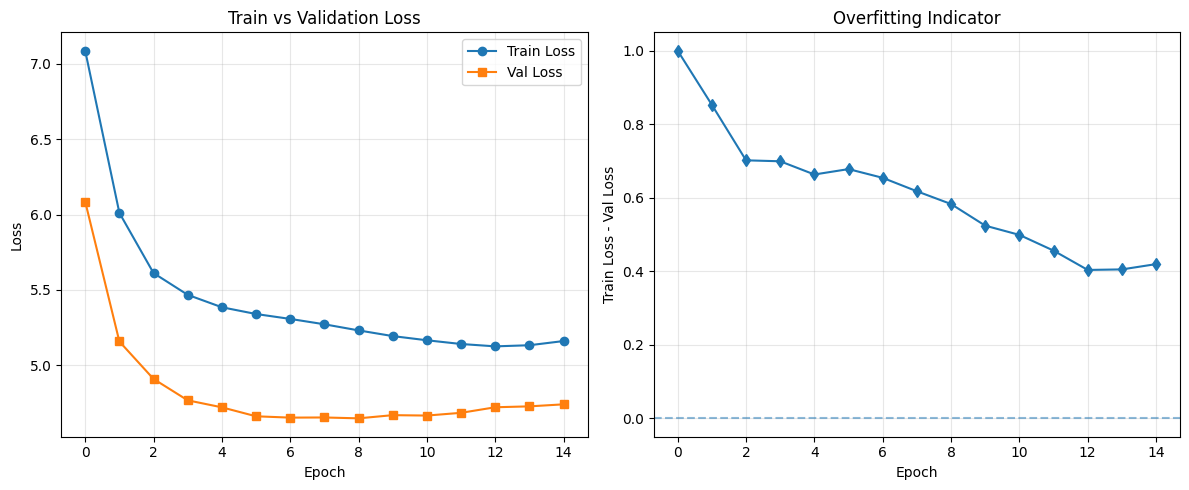

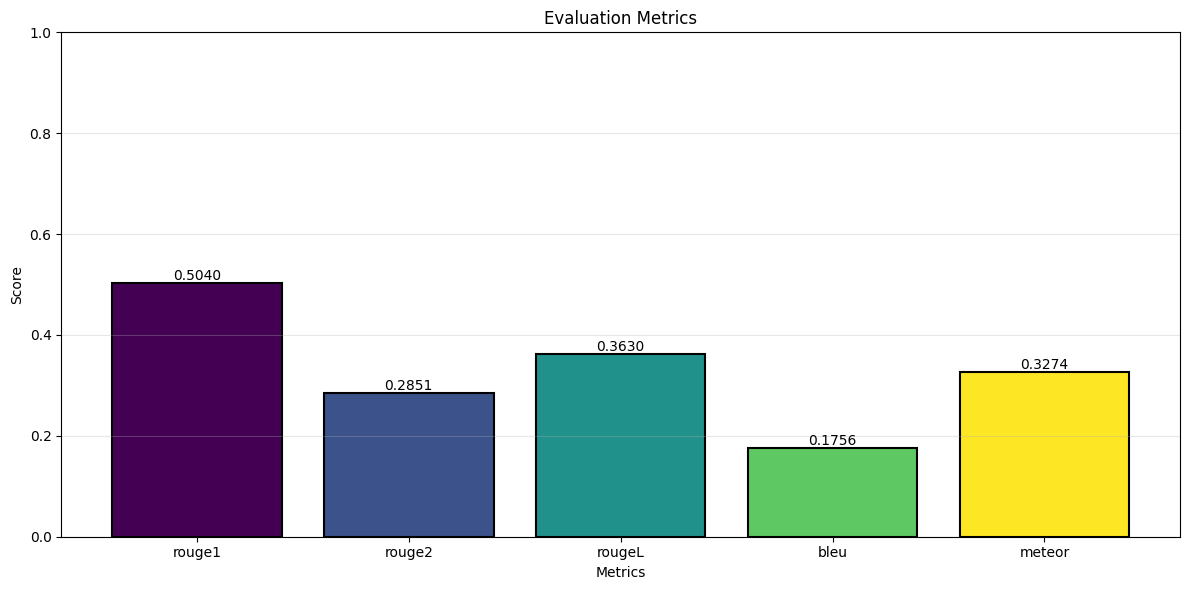

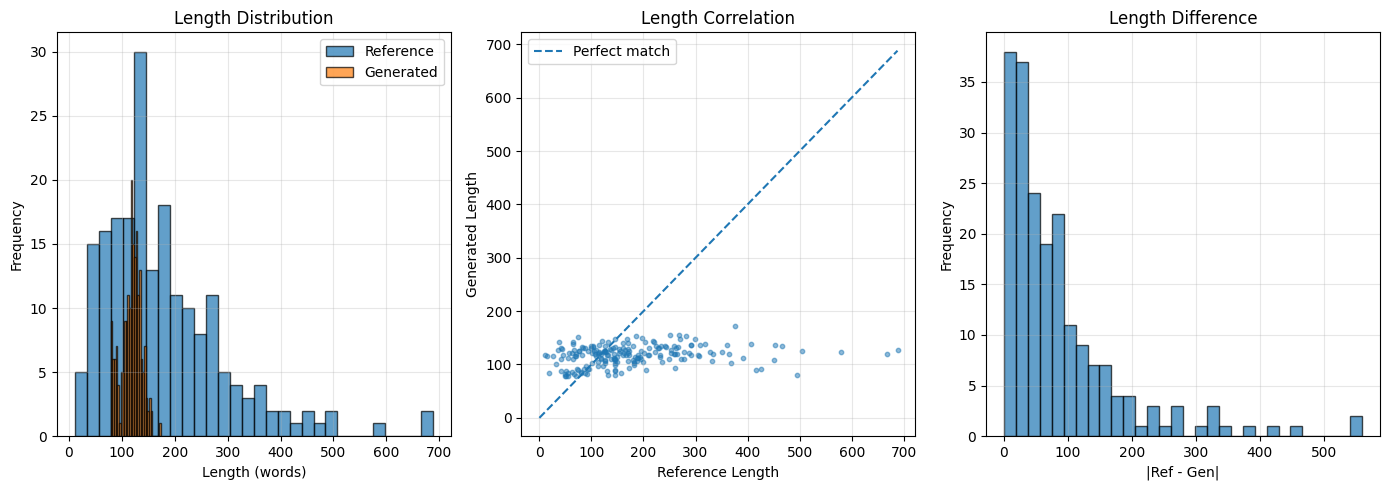


SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)

--- Example 1 ---
Reference: amends the water resources development act of 1999 to: (1) authorize appropriations for fy 1999 through 2009 for implementation of a long-term resource monitoring program with respect to the upper mississippi river environmental management program (currently, such funding is designated for a program for the planning, construction, and evaluation of measures for fish and wildlife habitat rehabilita...
Generated: amends the water resources development act of 1992 to extend through the administrator of the environmental protection agency (epa) through december 31, 2005. of projects for the elimination or control of combined sewer overflows for jackson county, the secretary of the interior to be carried out the the determines that the project is technically sound, environmentally <UNK> and economically disad...

--- Example 2 ---
Reference: federal forage fee act of 1993 - subjects grazing operations on f

In [1]:
# ============================================================
# LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + ADVANCED BEAM
# (Enhanced Training & Decoding – No Transformers)
# ============================================================

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import matplotlib.pyplot as plt
from collections import Counter
import re
from tqdm import tqdm
import time
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
import nltk
import warnings
import math

warnings.filterwarnings('ignore')

# ----------------- NLTK SETUP -----------------
try:
    nltk.download('punkt', quiet=True)
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
except Exception:
    pass

# ----------------- DEVICE SETUP -----------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

torch.backends.cudnn.benchmark = True

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

# ============================================================
#                  TEXT PREPROCESSOR
# ============================================================
class TextPreprocessor:
    def __init__(self, max_vocab_size=30000, min_freq=1):
        self.max_vocab_size = max_vocab_size
        self.min_freq = min_freq
        self.word2idx = {'<PAD>': PAD_IDX, '<SOS>': SOS_IDX, '<EOS>': EOS_IDX, '<UNK>': UNK_IDX}
        self.idx2word = {PAD_IDX: '<PAD>', SOS_IDX: '<SOS>', EOS_IDX: '<EOS>', UNK_IDX: '<UNK>'}
        self.vocab_size = 4

    def normalize_text(self, text):
        text = re.sub(r'\s+', ' ', str(text))
        text = text.strip().lower()
        return text

    def tokenize(self, text):
        return text.split()

    def build_vocab(self, texts):
        word_freq = Counter()
        for text in tqdm(texts, desc="Building vocabulary"):
            tokens = self.tokenize(self.normalize_text(text))
            word_freq.update(tokens)

        for word, freq in word_freq.most_common():
            if freq < self.min_freq:
                break
            if word not in self.word2idx and self.vocab_size < self.max_vocab_size:
                self.word2idx[word] = self.vocab_size
                self.idx2word[self.vocab_size] = word
                self.vocab_size += 1

        print(f"Vocabulary size: {self.vocab_size} (min_freq={self.min_freq})")
        return self.vocab_size

    def encode(self, text, max_len=None):
        tokens = self.tokenize(self.normalize_text(text))
        indices = [self.word2idx.get(tok, UNK_IDX) for tok in tokens]
        if max_len:
            indices = indices[:max_len]
        return indices

    def decode(self, indices):
        tokens = [
            self.idx2word.get(idx, '<UNK>')
            for idx in indices
            if idx not in (PAD_IDX, SOS_IDX, EOS_IDX)
        ]
        return ' '.join(tokens)

# ============================================================
#                  DATASET + COLLATE
# ============================================================
class BillSumDataset(Dataset):
    def __init__(self, texts, summaries, preprocessor,
                 max_text_len=250, max_summary_len=120):
        self.texts = texts
        self.summaries = summaries
        self.preprocessor = preprocessor
        self.max_text_len = max_text_len
        self.max_summary_len = max_summary_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        src = self.preprocessor.encode(self.texts[idx], self.max_text_len)
        trg = self.preprocessor.encode(self.summaries[idx], self.max_summary_len)
        trg = [SOS_IDX] + trg + [EOS_IDX]
        return torch.LongTensor(src), torch.LongTensor(trg)

def collate_fn(batch):
    srcs, trgs = zip(*batch)
    srcs_padded = pad_sequence(srcs, batch_first=True, padding_value=PAD_IDX)
    trgs_padded = pad_sequence(trgs, batch_first=True, padding_value=PAD_IDX)
    return srcs_padded, trgs_padded

# ============================================================
#                  ENCODER (BIDIR GRU)
# ============================================================
class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 num_layers=1, dropout=0.3, bidirectional=True):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.gru = nn.GRU(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
            bidirectional=bidirectional
        )
        self.dropout = nn.Dropout(dropout)
        self.enc_out_dim = hidden_dim * 2 if bidirectional else hidden_dim

    def forward(self, src):
        emb = self.dropout(self.embedding(src))       # [B, T, E]
        outputs, hidden = self.gru(emb)               # outputs: [B, T, enc_out_dim]

        if self.bidirectional:
            # hidden: [num_layers*2, B, H] -> [num_layers, 2, B, H] -> sum directions
            hidden = hidden.view(self.num_layers, 2, -1, self.hidden_dim)
            hidden = hidden.sum(dim=1)               # [num_layers, B, H]

        return outputs, hidden                        # outputs: [B,T,enc_out_dim]

# ============================================================
#           COVERAGE ATTENTION (LUONG-STYLE + COVERAGE)
# ============================================================
class CoverageAttention(nn.Module):
    """
    e_ti = v^T tanh(W_h h_i + W_s s_t + W_c c_ti)
    coverage c_ti = sum_{t'<t} a_{t'i}
    """
    def __init__(self, hidden_dim, enc_out_dim, attn_dim=256):
        super().__init__()
        self.W_h = nn.Linear(enc_out_dim, attn_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, attn_dim, bias=False)
        self.W_c = nn.Linear(1, attn_dim, bias=False)
        self.v = nn.Linear(attn_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_outputs, coverage=None, compute_cov_loss=False):
        """
        dec_hidden: [B, H] (last decoder layer)
        enc_outputs: [B, T, enc_out_dim]
        coverage: [B, T] or None
        """
        B, T, _ = enc_outputs.size()

        if coverage is None:
            coverage_prev = enc_outputs.new_zeros(B, T)
        else:
            coverage_prev = coverage

        enc_feat = self.W_h(enc_outputs)                          # [B, T, A]
        dec_feat = self.W_s(dec_hidden).unsqueeze(1)              # [B, 1, A]
        cov_feat = self.W_c(coverage_prev.unsqueeze(2))           # [B, T, A]

        energy = torch.tanh(enc_feat + dec_feat + cov_feat)       # [B, T, A]
        scores = self.v(energy).squeeze(2)                        # [B, T]

        attn = torch.softmax(scores, dim=1)                       # [B, T]
        context = torch.bmm(attn.unsqueeze(1), enc_outputs)       # [B, 1, enc_out_dim]

        cov_loss = None
        if compute_cov_loss:
            cov_loss = torch.sum(torch.min(attn, coverage_prev), dim=1)  # [B]

        new_coverage = coverage_prev + attn

        return context, attn, new_coverage, cov_loss

# ============================================================
#            POINTER-GENERATOR DECODER (WITH COVERAGE)
# ============================================================
class PointerGeneratorDecoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim,
                 enc_out_dim, num_layers=1, dropout=0.3):
        super().__init__()
        self.vocab_size = vocab_size
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.enc_out_dim = enc_out_dim

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)
        self.attention = CoverageAttention(hidden_dim, enc_out_dim)
        self.dropout = nn.Dropout(dropout)

        self.gru = nn.GRU(
            embed_dim + enc_out_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc_vocab = nn.Linear(hidden_dim + enc_out_dim + embed_dim, vocab_size)
        self.p_gen_linear = nn.Linear(hidden_dim + enc_out_dim + embed_dim, 1)

    def forward(self, x, hidden, enc_outputs, src, coverage=None, compute_cov_loss=False):
        """
        x: [B, 1]
        hidden: [num_layers, B, H]
        enc_outputs: [B, T, enc_out_dim]
        src: [B, T]
        """
        emb = self.dropout(self.embedding(x))           # [B, 1, E]
        last_hidden = hidden[-1]                        # [B, H]

        context, attn, new_cov, cov_loss = self.attention(
            last_hidden, enc_outputs, coverage, compute_cov_loss=compute_cov_loss
        )                                               # context: [B, 1, enc_out_dim]

        gru_inp = torch.cat((emb, context), dim=2)      # [B, 1, E + enc_out_dim]
        out, hidden = self.gru(gru_inp, hidden)         # out: [B, 1, H]

        out = out.squeeze(1)                            # [B, H]
        ctx_vec = context.squeeze(1)                    # [B, enc_out_dim]
        emb_vec = emb.squeeze(1)                        # [B, E]

        vocab_input = torch.cat((out, ctx_vec, emb_vec), dim=1)  # [B, H+enc_out+E]
        vocab_logits = self.fc_vocab(vocab_input)                # [B, V]
        vocab_dist = torch.softmax(vocab_logits, dim=1)          # [B, V]

        # Copy distribution
        B, T = src.size()
        copy_dist = torch.zeros_like(vocab_dist)                 # [B, V]

        # Clamp indices to avoid out-of-range
        src_clamped = src.clone()
        src_clamped[src_clamped >= self.vocab_size] = UNK_IDX

        copy_dist.scatter_add_(1, src_clamped, attn)             # [B, V]

        # Generation probability (biased slightly towards copying)
        raw_p_gen = self.p_gen_linear(vocab_input)               # [B, 1]
        p_gen = torch.sigmoid(raw_p_gen - 0.2)                   # bias towards copy

        final_dist = p_gen * vocab_dist + (1.0 - p_gen) * copy_dist
        final_dist = final_dist.clamp(min=1e-12)

        return final_dist, hidden, new_cov, cov_loss

# ============================================================
#                     SEQ2SEQ WRAPPER
# ============================================================
class Seq2SeqPGN(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def encode(self, src):
        return self.encoder(src)

    def decode_step(self, x, hidden, enc_outputs, src,
                    coverage=None, compute_cov_loss=False):
        return self.decoder(x, hidden, enc_outputs, src,
                            coverage, compute_cov_loss)

# ============================================================
#        TRAINING & EVALUATION (NLL + COVERAGE LOSS + LS)
# ============================================================
def compute_smoothed_nll(final_dist, target_t, label_smoothing):
    """
    final_dist: [B, V] probabilities
    target_t: [B] target indices
    label_smoothing: float in [0, 1)
    Returns: [B] per-sample loss
    """
    log_probs = torch.log(final_dist + 1e-12)  # [B, V]
    B, V = log_probs.size()
    rows = torch.arange(B, device=final_dist.device)

    log_p_y = log_probs[rows, target_t]        # [B]

    if label_smoothing <= 0.0:
        return -log_p_y

    # Uniform prior over vocab (approximate LS)
    mean_log_p = log_probs.mean(dim=1)         # [B]
    eps = label_smoothing
    return -((1.0 - eps) * log_p_y + eps * mean_log_p)

def train_epoch(
    model,
    dataloader,
    optimizer,
    epoch,
    base_teacher_forcing=0.7,
    decay=0.9,
    coverage_lambda=1.0,
    clip=2.0,
    label_smoothing=0.1
):
    model.train()
    epoch_loss = 0.0

    # Scheduled sampling (decaying teacher forcing)
    teacher_forcing_ratio = max(0.1, base_teacher_forcing * (decay ** epoch))

    for src, trg in tqdm(dataloader, desc=f"Training (epoch {epoch+1})"):
        src = src.to(device)
        trg = trg.to(device)

        optimizer.zero_grad()

        enc_outputs, hidden = model.encode(src)
        B, src_len = src.size()
        trg_len = trg.size(1)

        coverage = src.new_zeros(B, src_len, dtype=torch.float32)

        total_nll = 0.0
        total_cov = 0.0
        step_count = 0

        inp = trg[:, 0].unsqueeze(1)   # start with <SOS>

        for t in range(1, trg_len):
            final_dist, hidden, coverage, cov_loss = model.decode_step(
                inp, hidden, enc_outputs, src,
                coverage=coverage,
                compute_cov_loss=True
            )                           # final_dist: [B, V]

            target_t = trg[:, t]        # [B]
            mask = (target_t != PAD_IDX)

            if mask.any():
                fd_mask = final_dist[mask]          # [B', V]
                tt_mask = target_t[mask]            # [B']

                nll_t = compute_smoothed_nll(fd_mask, tt_mask, label_smoothing)
                total_nll += nll_t.mean()

                if cov_loss is not None:
                    total_cov += cov_loss[mask].mean()

                step_count += 1

            # Teacher forcing / sampling
            teacher_force = np.random.random() < teacher_forcing_ratio
            top1 = final_dist.argmax(1)             # [B]
            next_inp = target_t if teacher_force else top1
            inp = next_inp.unsqueeze(1)

        if step_count == 0:
            continue

        avg_nll = total_nll / step_count
        avg_cov = total_cov / step_count

        loss = avg_nll + coverage_lambda * avg_cov
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)
        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

def evaluate_epoch(
    model,
    dataloader,
    coverage_lambda=1.0,
    label_smoothing=0.1
):
    model.eval()
    epoch_loss = 0.0

    with torch.no_grad():
        for src, trg in dataloader:
            src = src.to(device)
            trg = trg.to(device)

            enc_outputs, hidden = model.encode(src)
            B, src_len = src.size()
            trg_len = trg.size(1)

            coverage = src.new_zeros(B, src_len, dtype=torch.float32)

            total_nll = 0.0
            total_cov = 0.0
            step_count = 0

            inp = trg[:, 0].unsqueeze(1)

            for t in range(1, trg_len):
                final_dist, hidden, coverage, cov_loss = model.decode_step(
                    inp, hidden, enc_outputs, src,
                    coverage=coverage,
                    compute_cov_loss=True
                )

                target_t = trg[:, t]
                mask = (target_t != PAD_IDX)

                if mask.any():
                    fd_mask = final_dist[mask]
                    tt_mask = target_t[mask]

                    nll_t = compute_smoothed_nll(fd_mask, tt_mask, label_smoothing)
                    total_nll += nll_t.mean()

                    if cov_loss is not None:
                        total_cov += cov_loss[mask].mean()

                    step_count += 1

                # pure teacher forcing during eval
                inp = target_t.unsqueeze(1)

            if step_count == 0:
                continue

            avg_nll = total_nll / step_count
            avg_cov = total_cov / step_count
            loss = avg_nll + coverage_lambda * avg_cov
            epoch_loss += loss.item()

    return epoch_loss / len(dataloader)

# ============================================================
#         ADVANCED BEAM SEARCH (REPETITION CONTROL)
# ============================================================
def generate_summary_beam(
    model,
    src,
    preprocessor,
    max_len=120,
    beam_width=4,
    length_norm=True,
    length_alpha=0.7,
    min_len=30,
    repetition_penalty=1.2,
    block_trigram=True
):
    """
    Beam search decoding with:
    - pointer-generator + coverage
    - repetition penalty
    - optional trigram blocking
    - discourages early EOS, overuse of UNK
    """
    model.eval()
    with torch.no_grad():
        src = src.unsqueeze(0).to(device)          # [1, T]
        enc_outputs, hidden = model.encode(src)
        B, T = src.size()
        assert B == 1

        coverage = src.new_zeros(1, T, dtype=torch.float32)

        # Each beam: (tokens, hidden, coverage, log_prob, trigram_set)
        beams = [([SOS_IDX], hidden, coverage, 0.0, set())]

        for step in range(max_len):
            new_beams = []

            for tokens, h, cov, log_prob, tri_set in beams:
                # If finished and already long enough, just keep as-is
                if tokens[-1] == EOS_IDX and len(tokens) >= min_len:
                    new_beams.append((tokens, h, cov, log_prob, tri_set))
                    continue

                inp = torch.LongTensor([[tokens[-1]]]).to(device)  # [1,1]
                final_dist, new_hidden, new_cov, _ = model.decode_step(
                    inp, h, enc_outputs, src,
                    coverage=cov,
                    compute_cov_loss=False
                )  # [1, V]

                log_probs = torch.log(final_dist + 1e-12)          # [1, V]

                # repetition penalty: lower log-probs of tokens already used
                if repetition_penalty != 1.0:
                    used_tokens = set(tokens)
                    for tok in used_tokens:
                        if tok < log_probs.size(1):
                            log_probs[0, tok] -= math.log(repetition_penalty)

                # discourage UNK overuse
                if UNK_IDX < log_probs.size(1):
                    log_probs[0, UNK_IDX] -= math.log(1.5)

                # never generate PAD/SOS as normal tokens
                log_probs[0, PAD_IDX] = -1e9
                log_probs[0, SOS_IDX] = -1e9

                # discourage EOS too early
                if len(tokens) < min_len:
                    log_probs[0, EOS_IDX] -= 5.0

                topk_log_probs, topk_ids = torch.topk(log_probs, beam_width, dim=1)

                for i in range(beam_width):
                    next_id = topk_ids[0, i].item()
                    next_log_prob = log_prob + topk_log_probs[0, i].item()

                    new_tokens = tokens + [next_id]
                    new_tri_set = set(tri_set)

                    # trigram blocking
                    if block_trigram and len(new_tokens) >= 3:
                        trigram = tuple(new_tokens[-3:])
                        if trigram in tri_set:
                            # strongly penalize repeating trigram
                            next_log_prob -= 5.0
                        else:
                            new_tri_set.add(trigram)

                    new_beams.append(
                        (new_tokens, new_hidden, new_cov.clone(), next_log_prob, new_tri_set)
                    )

            # keep top beams
            if length_norm:
                beams = sorted(
                    new_beams,
                    key=lambda x: x[3] / (len(x[0]) ** length_alpha),
                    reverse=True
                )[:beam_width]
            else:
                beams = sorted(new_beams, key=lambda x: x[3], reverse=True)[:beam_width]

        # choose best finished beam
        if length_norm:
            best = max(
                beams,
                key=lambda x: x[3] / (len(x[0]) ** length_alpha)
            )
        else:
            best = max(beams, key=lambda x: x[3])

        best_tokens = best[0]

        # strip SOS/EOS
        if EOS_IDX in best_tokens:
            eos_pos = best_tokens.index(EOS_IDX)
            best_tokens = best_tokens[1:eos_pos]
        else:
            best_tokens = best_tokens[1:]

        return preprocessor.decode(best_tokens)

# ============================================================
#                  EVALUATION METRICS
# ============================================================
class EvaluationMetrics:
    def __init__(self):
        self.rouge_scorer = rouge_scorer.RougeScorer(
            ['rouge1', 'rouge2', 'rougeL'],
            use_stemmer=True
        )
        self.smooth = SmoothingFunction().method1

    def calculate_rouge(self, reference, hypothesis):
        scores = self.rouge_scorer.score(reference, hypothesis)
        return {
            'rouge1_f': scores['rouge1'].fmeasure,
            'rouge2_f': scores['rouge2'].fmeasure,
            'rougeL_f': scores['rougeL'].fmeasure
        }

    def calculate_bleu(self, reference, hypothesis):
        ref_tokens = reference.split()
        hyp_tokens = hypothesis.split()
        if len(hyp_tokens) == 0:
            return 0.0
        return sentence_bleu([ref_tokens], hyp_tokens, smoothing_function=self.smooth)

    def calculate_meteor(self, reference, hypothesis):
        try:
            return meteor_score([reference.split()], hypothesis.split())
        except Exception:
            return 0.0

    def calculate_all_metrics(self, references, hypotheses):
        metrics = {
            'rouge1': [], 'rouge2': [], 'rougeL': [],
            'bleu': [], 'meteor': []
        }
        for ref, hyp in tqdm(zip(references, hypotheses),
                             total=len(references),
                             desc="Calculating metrics"):
            r = self.calculate_rouge(ref, hyp)
            metrics['rouge1'].append(r['rouge1_f'])
            metrics['rouge2'].append(r['rouge2_f'])
            metrics['rougeL'].append(r['rougeL_f'])
            metrics['bleu'].append(self.calculate_bleu(ref, hyp))
            metrics['meteor'].append(self.calculate_meteor(ref, hyp))

        return {k: float(np.mean(v)) for k, v in metrics.items()}

# ============================================================
#                       VISUALIZATION
# ============================================================
def plot_training_history(train_losses, val_losses):
    if len(train_losses) == 0:
        return

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses, label='Val Loss', marker='s')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Train vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    improvement = [train_losses[i] - val_losses[i]
                   for i in range(len(train_losses))]
    plt.plot(improvement, marker='d')
    plt.xlabel('Epoch')
    plt.ylabel('Train Loss - Val Loss')
    plt.title('Overfitting Indicator')
    plt.axhline(y=0, linestyle='--', alpha=0.5)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def plot_metrics(metrics_dict):
    plt.figure(figsize=(12, 6))
    names = list(metrics_dict.keys())
    vals = list(metrics_dict.values())

    colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
    bars = plt.bar(names, vals, color=colors, edgecolor='black', linewidth=1.5)

    plt.xlabel('Metrics')
    plt.ylabel('Score')
    plt.title('Evaluation Metrics')
    plt.ylim(0, 1.0)
    plt.grid(axis='y', alpha=0.3)

    for b in bars:
        h = b.get_height()
        plt.text(b.get_x() + b.get_width()/2., h,
                 f'{h:.4f}', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

def plot_summary_length_comparison(references, hypotheses):
    ref_lengths = [len(ref.split()) for ref in references]
    hyp_lengths = [len(hyp.split()) for hyp in hypotheses]

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.hist(ref_lengths, bins=30, alpha=0.7, label='Reference', edgecolor='black')
    plt.hist(hyp_lengths, bins=30, alpha=0.7, label='Generated', edgecolor='black')
    plt.xlabel('Length (words)')
    plt.ylabel('Frequency')
    plt.title('Length Distribution')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.scatter(ref_lengths, hyp_lengths, alpha=0.5, s=10)
    max_len = max(max(ref_lengths), max(hyp_lengths)) if ref_lengths and hyp_lengths else 1
    plt.plot([0, max_len], [0, max_len], '--', label='Perfect match')
    plt.xlabel('Reference Length')
    plt.ylabel('Generated Length')
    plt.title('Length Correlation')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 3, 3)
    length_diff = [abs(r - h) for r, h in zip(ref_lengths, hyp_lengths)]
    plt.hist(length_diff, bins=30, edgecolor='black', alpha=0.7)
    plt.xlabel('|Ref - Gen|')
    plt.ylabel('Frequency')
    plt.title('Length Difference')
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ============================================================
#                  LR SCHEDULER (WARMUP + COSINE)
# ============================================================
def build_warmup_cosine_scheduler(optimizer, num_epochs, warmup_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            # Linear warmup
            return float(epoch + 1) / float(max(1, warmup_epochs))
        # Cosine decay
        progress = float(epoch - warmup_epochs) / float(max(1, num_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

# ============================================================
#                           MAIN
# ============================================================
def main():
    config = {
        'train_csv': "billsum_train.csv",
        'test_csv': "billsum_test.csv",
        'embed_dim': 300,
        'hidden_dim': 384,
        'num_layers': 2,
        'dropout': 0.3,
        'batch_size': 8,
        'num_epochs': 15,
        'learning_rate': 5e-4,
        'max_vocab_size': 30000,
        'min_freq': 1,
        'max_text_len': 1024,
        'max_summary_len': 130,
        'sample_size': 8000,
        'coverage_lambda': 1.5,
        'coverage_decay': 0.9,
        'min_coverage_lambda': 0.4,
        'beam_width': 10,
        'max_gen_len': 200,
        'min_gen_len': 80,
        'repetition_penalty': 1.35,
        'length_alpha': 0.7,
        'base_teacher_forcing': 0.8,
        'teacher_forcing_decay': 0.9,
        'label_smoothing': 0.1,
        'max_grad_norm': 2.0,
        'warmup_epochs': 2,
    }

    print("=" * 60)
    print("LEGAL TEXT POINTER-GENERATOR GRU + COVERAGE + BEAM SEARCH")
    print("=" * 60)

    # 1) Load data
    print("\n[1/7] Loading datasets...")
    train_df = pd.read_csv(config['train_csv']).head(config['sample_size'])
    test_df = pd.read_csv(config['test_csv']).head(500)
    print(f"Train samples: {len(train_df)}, Test samples: {len(test_df)}")

    # 2) Build vocab
    print("\n[2/7] Building vocabulary and preprocessing...")
    preprocessor = TextPreprocessor(
        max_vocab_size=config['max_vocab_size'],
        min_freq=config['min_freq']
    )
    preprocessor.build_vocab(
        train_df['text'].tolist() + train_df['summary'].tolist()
    )

    # 3) Create datasets + loaders
    train_dataset = BillSumDataset(
        train_df['text'].tolist(),
        train_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )
    test_dataset = BillSumDataset(
        test_df['text'].tolist(),
        test_df['summary'].tolist(),
        preprocessor,
        config['max_text_len'],
        config['max_summary_len']
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=config['batch_size'],
        shuffle=True,
        collate_fn=collate_fn
    )
    test_loader = DataLoader(
        test_dataset,
        batch_size=config['batch_size'],
        shuffle=False,
        collate_fn=collate_fn
    )

    # 4) Build model
    print("\n[3/7] Building Pointer-Generator Seq2Seq model...")
    torch.cuda.empty_cache()

    encoder = Encoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        config['num_layers'],
        config['dropout'],
        bidirectional=True
    )
    decoder = PointerGeneratorDecoder(
        preprocessor.vocab_size,
        config['embed_dim'],
        config['hidden_dim'],
        enc_out_dim=encoder.enc_out_dim,
        num_layers=config['num_layers'],
        dropout=config['dropout']
    )
    model = Seq2SeqPGN(encoder, decoder).to(device)

    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total trainable parameters: {total_params:,}")

    optimizer = torch.optim.AdamW(model.parameters(), lr=config['learning_rate'])
    scheduler = build_warmup_cosine_scheduler(
        optimizer,
        num_epochs=config['num_epochs'],
        warmup_epochs=config['warmup_epochs']
    )

    # 5) Train (FULL num_epochs, no early stopping)
    print("\n[4/7] Training model (pointer-generator + coverage)...")
    train_losses, val_losses = [], []
    start = time.time()

    for epoch in range(config['num_epochs']):
        # Dynamic coverage lambda decay
        cov_lambda = max(
            config['min_coverage_lambda'],
            config['coverage_lambda'] * (config['coverage_decay'] ** epoch)
        )

        current_lr = scheduler.get_last_lr()[0]
        print(f"\nEpoch {epoch+1}/{config['num_epochs']} | LR: {current_lr:.6f} | coverage_lambda: {cov_lambda:.4f}")

        train_loss = train_epoch(
            model,
            train_loader,
            optimizer,
            epoch,
            base_teacher_forcing=config['base_teacher_forcing'],
            decay=config['teacher_forcing_decay'],
            coverage_lambda=cov_lambda,
            clip=config['max_grad_norm'],
            label_smoothing=config['label_smoothing']
        )
        val_loss = evaluate_epoch(
            model,
            test_loader,
            coverage_lambda=cov_lambda,
            label_smoothing=config['label_smoothing']
        )
        scheduler.step()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"Epoch {epoch+1}/{config['num_epochs']} | "
              f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Always save best model so far
        if val_loss <= min(val_losses):
            torch.save(model.state_dict(), 'best_model_pgn_coverage_advanced.pt')
            print("  → New best model saved!")

    total_time = (time.time() - start) / 60.0
    print(f"\nTraining completed in {total_time:.2f} minutes (for {config['num_epochs']} epochs)")

    # 6) Evaluate with best model
    model.load_state_dict(torch.load('best_model_pgn_coverage_advanced.pt', map_location=device))

    print("\n[5/7] Generating summaries on test set (beam search + pointer)...")
    references, hypotheses = [], []

    for i in tqdm(range(min(200, len(test_df))), desc="Generating"):
        text = test_df.iloc[i]['text']
        ref_sum = test_df.iloc[i]['summary']
        src_encoded = torch.LongTensor(preprocessor.encode(text, config['max_text_len']))

        hyp = generate_summary_beam(
            model,
            src_encoded,
            preprocessor,
            max_len=config['max_gen_len'],
            beam_width=config['beam_width'],
            min_len=config['min_gen_len'],
            repetition_penalty=config['repetition_penalty'],
            block_trigram=True,
            length_alpha=config['length_alpha']
        )

        references.append(preprocessor.normalize_text(ref_sum))
        hypotheses.append(hyp)

    print("\n[6/7] Calculating evaluation metrics...")
    evaluator = EvaluationMetrics()
    metrics = evaluator.calculate_all_metrics(references, hypotheses)

    print("\n" + "="*60)
    print("EVALUATION RESULTS")
    print("="*60)
    for m, v in metrics.items():
        print(f"{m.upper()}: {v:.4f}")
    print("="*60)

    # 7) Visualizations
    print("\n[7/7] Generating visualizations...")
    plot_training_history(train_losses, val_losses)
    plot_metrics(metrics)
    plot_summary_length_comparison(references, hypotheses)

    # Sample outputs
    print("\n" + "="*60)
    print("SAMPLE SUMMARIES (POINTER-GENERATOR + COVERAGE + BEAM)")
    print("="*60)
    for i in range(min(3, len(references))):
        print(f"\n--- Example {i+1} ---")
        print(f"Reference: {references[i][:400]}...")
        print(f"Generated: {hypotheses[i][:400]}...")

    print("\n✓ Training and evaluation completed successfully!")
    print(f"✓ Total execution time (training only): {total_time:.2f} minutes")

    return model, preprocessor, metrics

if __name__ == "__main__":
    model, preprocessor, metrics = main()
